In [ ]:
# @title
from IPython.core.display import display, HTML
import time
start_time = time.time()

display(HTML('''
<div style="display: flex; justify-content: space-between; align-items: center; padding: 10px;">
  <div style="flex: 1;">
    <h1 style="margin: 0;">Data Mining Project - Wonderful Wines of the World</h1>
    <h2 style="margin: 0;">Data Mining 1</h2>
    <p style="margin: 5px 0;">Fall Semester 2024-2025</p>
    <p style="margin: 5px 0;">Group 66</p>
    <p style="margin: 5px 0;">Created by:</p>
    <ul style="margin: 5px 0; padding-left: 20px;">
      <li>Bruno Chaves - 20240370</li>
      <li>Patrick Perlinger - 20240378</li>
      <li>Rodrigo Santos - 20240389</li>
      <li>Emmanuel Tronche-Macaire - 20240385</li>
    </ul>
  </div>
  <div style="flex: 0 0 auto; text-align: right;">
    <img src="https://urbandatalab.pt/images/partners/nova_ims.png" alt="Art Image" width="200" style="border-radius: 5px;" />
  </div>
</div>
'''))


# Data Exploration
  

##Preliminary settings and imports

In [ ]:
# Required Libraries for analysis and plotting of the results

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr, f_oneway
import warnings
from google.colab import drive
import graphviz
import sqlite3
import os
import pydotplus
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from math import ceil
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set()

In [ ]:
data_path = "https://raw.githubusercontent.com/emmacaire/Clustering-academic-python/main/source/WWW.csv"
df = pd.read_csv(data_path)
df_original = df.copy()
df_copy = df.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Preliminary data exploration

### Dataset structure

In [ ]:
# Header analysis
df.head()

,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
0,1001,789,68,16,90782,0,0,29,66,1402,699,3,37,5,44,10,3,2,19,4,1
1,1002,623,78,20,113023,0,0,31,6,1537,565,1,55,1,38,4,2,2,9,1,0
2,1003,583,24,18,28344,1,0,4,69,44,-3,66,32,19,24,1,24,63,59,7,1
3,1004,893,59,19,93571,0,1,21,10,888,207,12,60,10,19,6,5,15,35,5,0
4,1005,1062,59,18,91852,0,1,25,26,1138,355,5,59,5,28,4,4,19,34,6,0


Basic exploratory data analysis
The dataframe consists of quantitative variables:

*   Discrete (Kidhome, Teenhome, Custid, ...)
*   Others can be considered as continuous (Income, Monetary, Dayswus, ...)

Although the results are shown as integer, the values have very different scales, which would suggest the need for normalization

In [ ]:
# Dataframe shape

print("Number of rows and columns:", df.shape)

Number of rows and columns: (10000, 21)


Our dataset consists of 10.000 rows of data and 21 different columns

In [ ]:
# Data types

df.dtypes.to_frame(name='Data types')

,Data types
Custid,int64
Dayswus,int64
Age,int64
Educ,int64
Income,int64
Kidhome,int64
Teenhome,int64
Freq,int64
Recency,int64
Monetary,int64


All columns are of integer data type

###Checking potentially wrong data types

Variables "Kidhome" and "Teenhome" are reported as being True/False statements, not quantities.

A quick check on the maximum value also suggests that no values over 1 are in the dataset

In [ ]:
print(df[['Kidhome']].value_counts())
print(df[['Teenhome']].value_counts())

Kidhome
0          5812
1          4188
Name: count, dtype: int64
Teenhome
0           5302
1           4698
Name: count, dtype: int64


This would suggest that we should consider these measures as Boolean

###Missing values and duplicates

In [ ]:
# Check for missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Custid       10000 non-null  int64
 1   Dayswus      10000 non-null  int64
 2   Age          10000 non-null  int64
 3   Educ         10000 non-null  int64
 4   Income       10000 non-null  int64
 5   Kidhome      10000 non-null  int64
 6   Teenhome     10000 non-null  int64
 7   Freq         10000 non-null  int64
 8   Recency      10000 non-null  int64
 9   Monetary     10000 non-null  int64
 10  LTV          10000 non-null  int64
 11  Perdeal      10000 non-null  int64
 12  Dryred       10000 non-null  int64
 13  Sweetred     10000 non-null  int64
 14  Drywh        10000 non-null  int64
 15  Sweetwh      10000 non-null  int64
 16  Dessert      10000 non-null  int64
 17  Exotic       10000 non-null  int64
 18  WebPurchase  10000 non-null  int64
 19  WebVisit     10000 non-null  int64
 20  Access 

In [ ]:
# Check for duplicate values

print ("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


There are no missing values in the dataframe and no duplicates

##Descriptive statistics

In [ ]:
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Custid,10000.0,6000.5,2886.9,1001.0,3500.8,6000.5,8500.2,11000.0
Dayswus,10000.0,898.1,202.5,550.0,723.8,894.0,1074.0,1250.0
Age,10000.0,47.9,17.3,18.0,33.0,48.0,63.0,78.0
Educ,10000.0,16.7,1.9,12.0,15.0,17.0,18.0,20.0
Income,10000.0,69904.4,27612.2,10000.0,47642.0,70012.0,92147.0,140628.0
Kidhome,10000.0,0.4,0.5,0.0,0.0,0.0,1.0,1.0
Teenhome,10000.0,0.5,0.5,0.0,0.0,0.0,1.0,1.0
Freq,10000.0,14.6,12.0,1.0,4.0,12.0,24.0,56.0
Recency,10000.0,62.4,69.9,0.0,26.0,52.0,78.2,549.0
Monetary,10000.0,622.6,647.1,6.0,63.0,383.0,1077.0,3052.0


At first glance, the outputs look appropriate, without extreme values or completely wrong entries.

Only one variable shows negative numbers.

In [ ]:
# Additional check: Displaying the lowest values of the Income variable

print(df['Income'].sort_values(ascending=True).head(45))

6142    10000
4373    10000
678     10000
1326    10000
1771    10000
932     10000
5760    10000
8498    10000
9605    10000
503     10000
755     10000
8629    10000
5564    10000
815     10000
611     10000
890     10000
107     10000
3086    10000
2743    10000
1205    10000
9012    10000
1083    10000
6427    10000
6494    10000
8420    10000
5277    10000
9932    10000
6828    10000
3742    10000
7351    10000
7407    10000
581     10000
7270    10000
7473    10000
2915    10000
2911    10000
6553    10000
5509    10000
908     10000
6497    10000
641     10182
2452    10186
3336    10608
1520    10886
5375    11347
Name: Income, dtype: int64


###Histogram overview

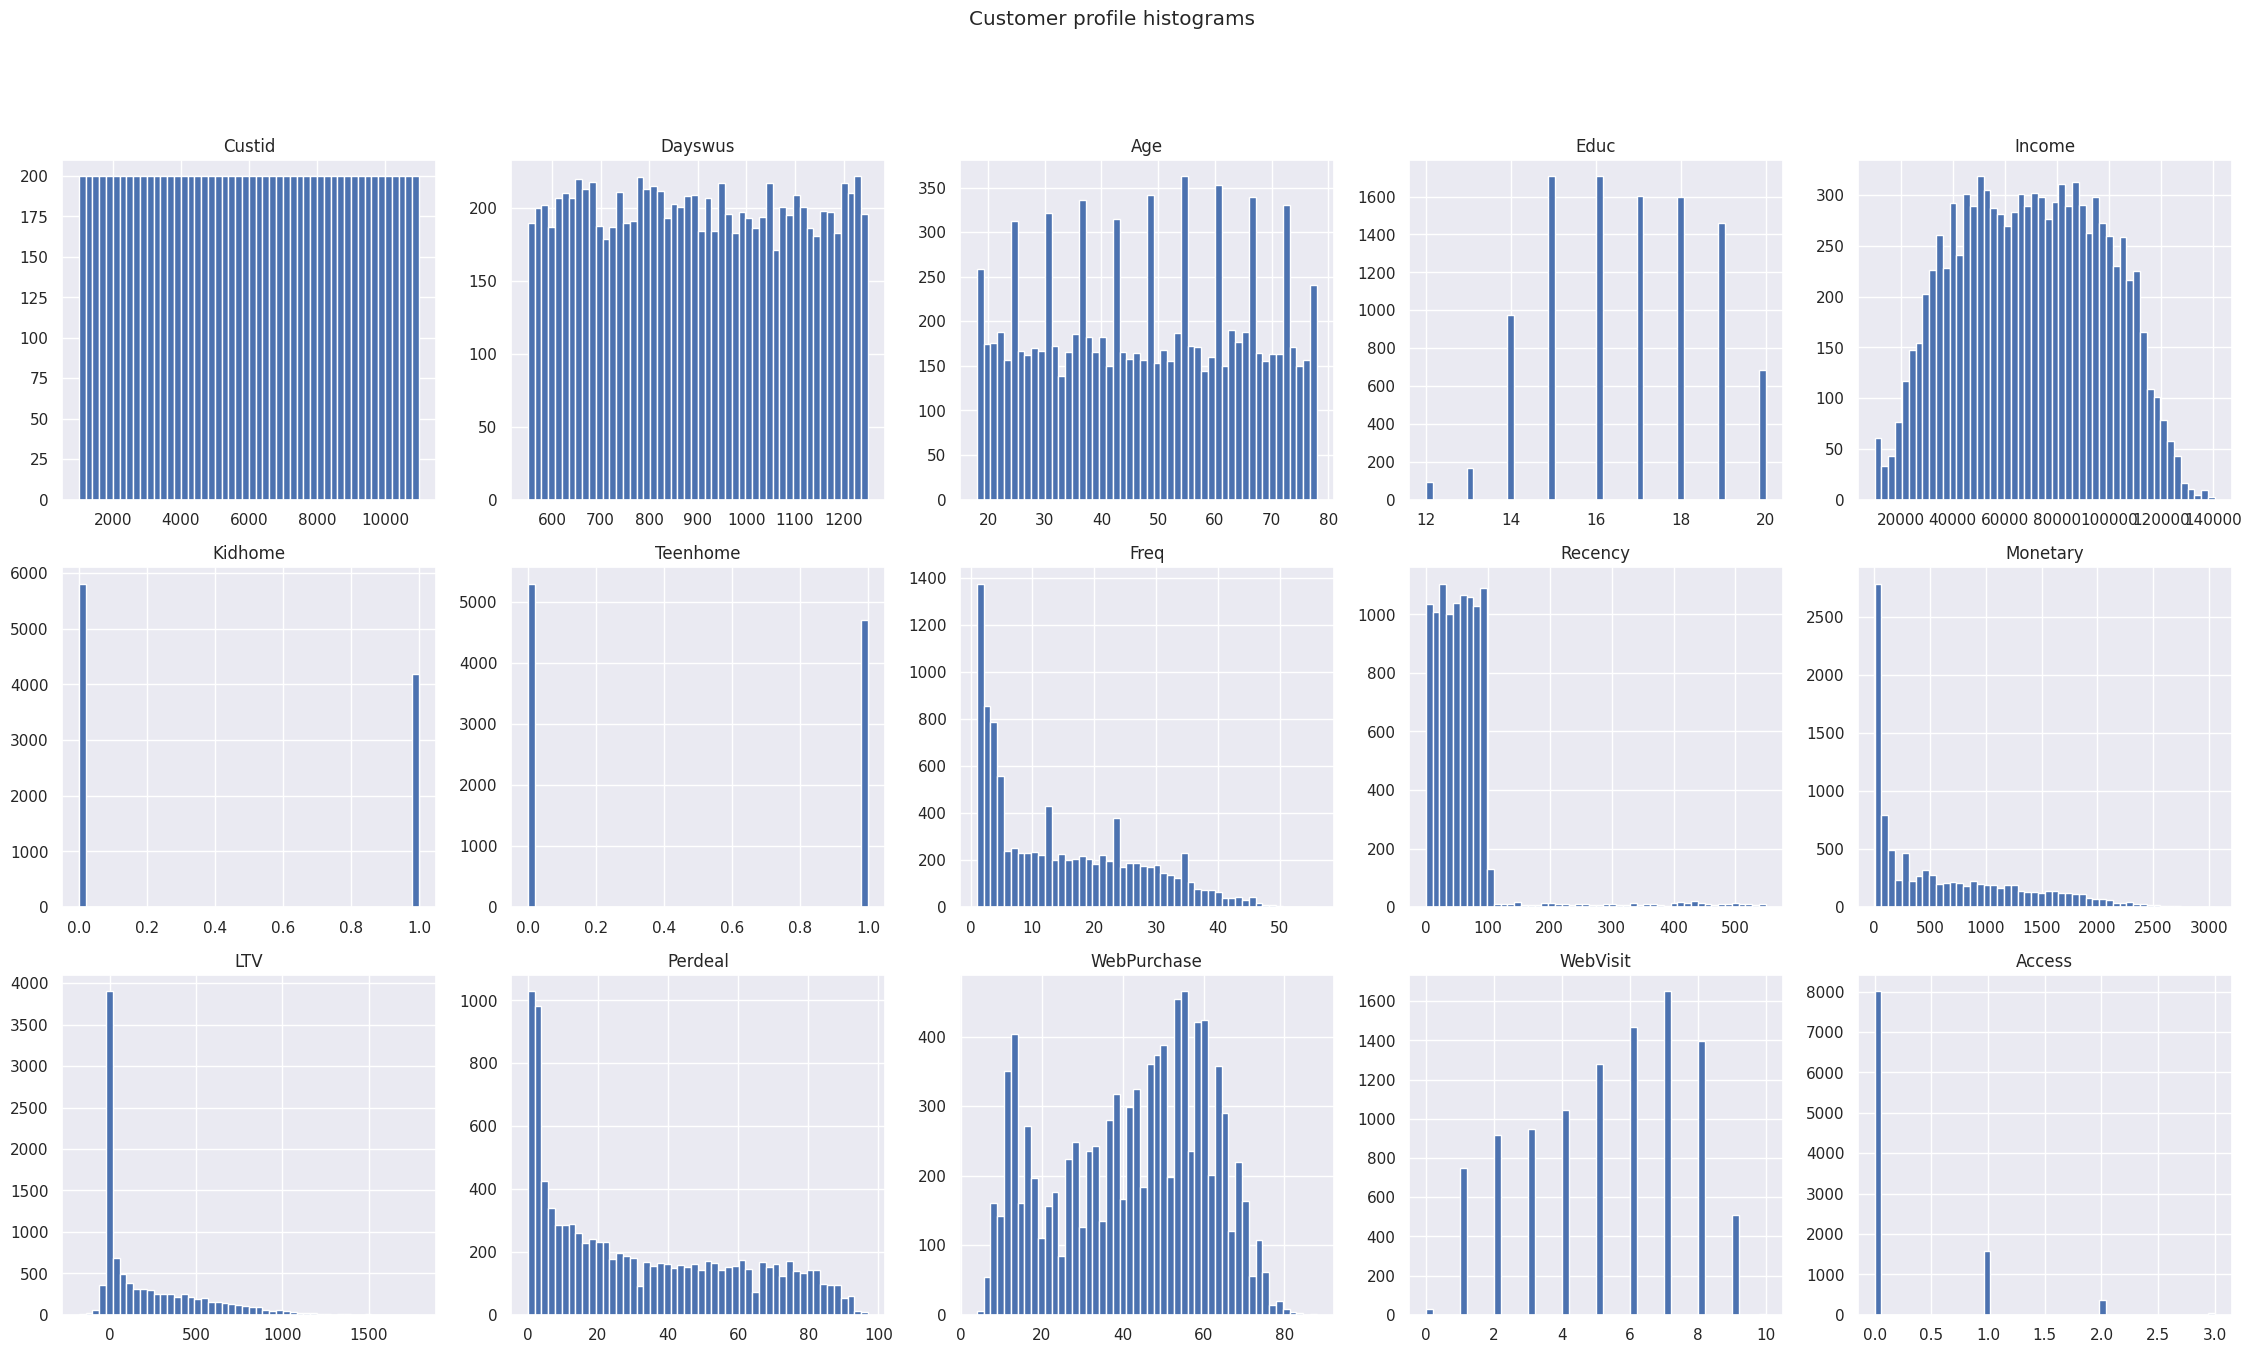

In [ ]:
# Histogram analysis - customer profile

def plot_multiple_histograms(data, feats, title="Customer profile histograms", figsize=(28, 15)):
    fig, axes = plt.subplots(3, ceil(len(feats) / 3), figsize=figsize)
    for ax, feat in zip(axes.flatten(), feats):
      ax.hist(data[feat],bins=50)
      ax.set_title(feat)
    plt.suptitle(title)
    plt.show()
    return
sns.set()
var_customer_profile = ['Custid', 'Dayswus', 'Age', 'Educ', 'Income',
 'Kidhome', 'Teenhome', 'Freq', 'Recency', 'Monetary', 'LTV', 'Perdeal','WebPurchase', 'WebVisit', 'Access']
plot_multiple_histograms(df, var_customer_profile)

We can classify the variables under the following categories:

1.   Custid, Dayswus, Age : even distribution among the range.
2.   Educ, Income, WebPurchase, WebVisit: normal/Gaussian distribution, with Educ and WebVisit being discrete, the others are continuous by approximation.
3.   Kidhome, Teenhome : binary variables, the histogram is not a good graphic representation.
4.   Frequency, Monetary, LTV, Perdeal: half normal distributions with a tendency for the data to stay around 0.
5.   Recency: similar to 4) but with a significant drop beyond x=100. Mandatory evaluation of outliers.
6.   Access: The variable is distributed across values 0, 1 and 2. The histogram is not a good graphic representation, similarly to 3).

Potential columns with outliers to be evaluated: all variables with a strong right tail (Freq, Recency, Monetary, LTV).

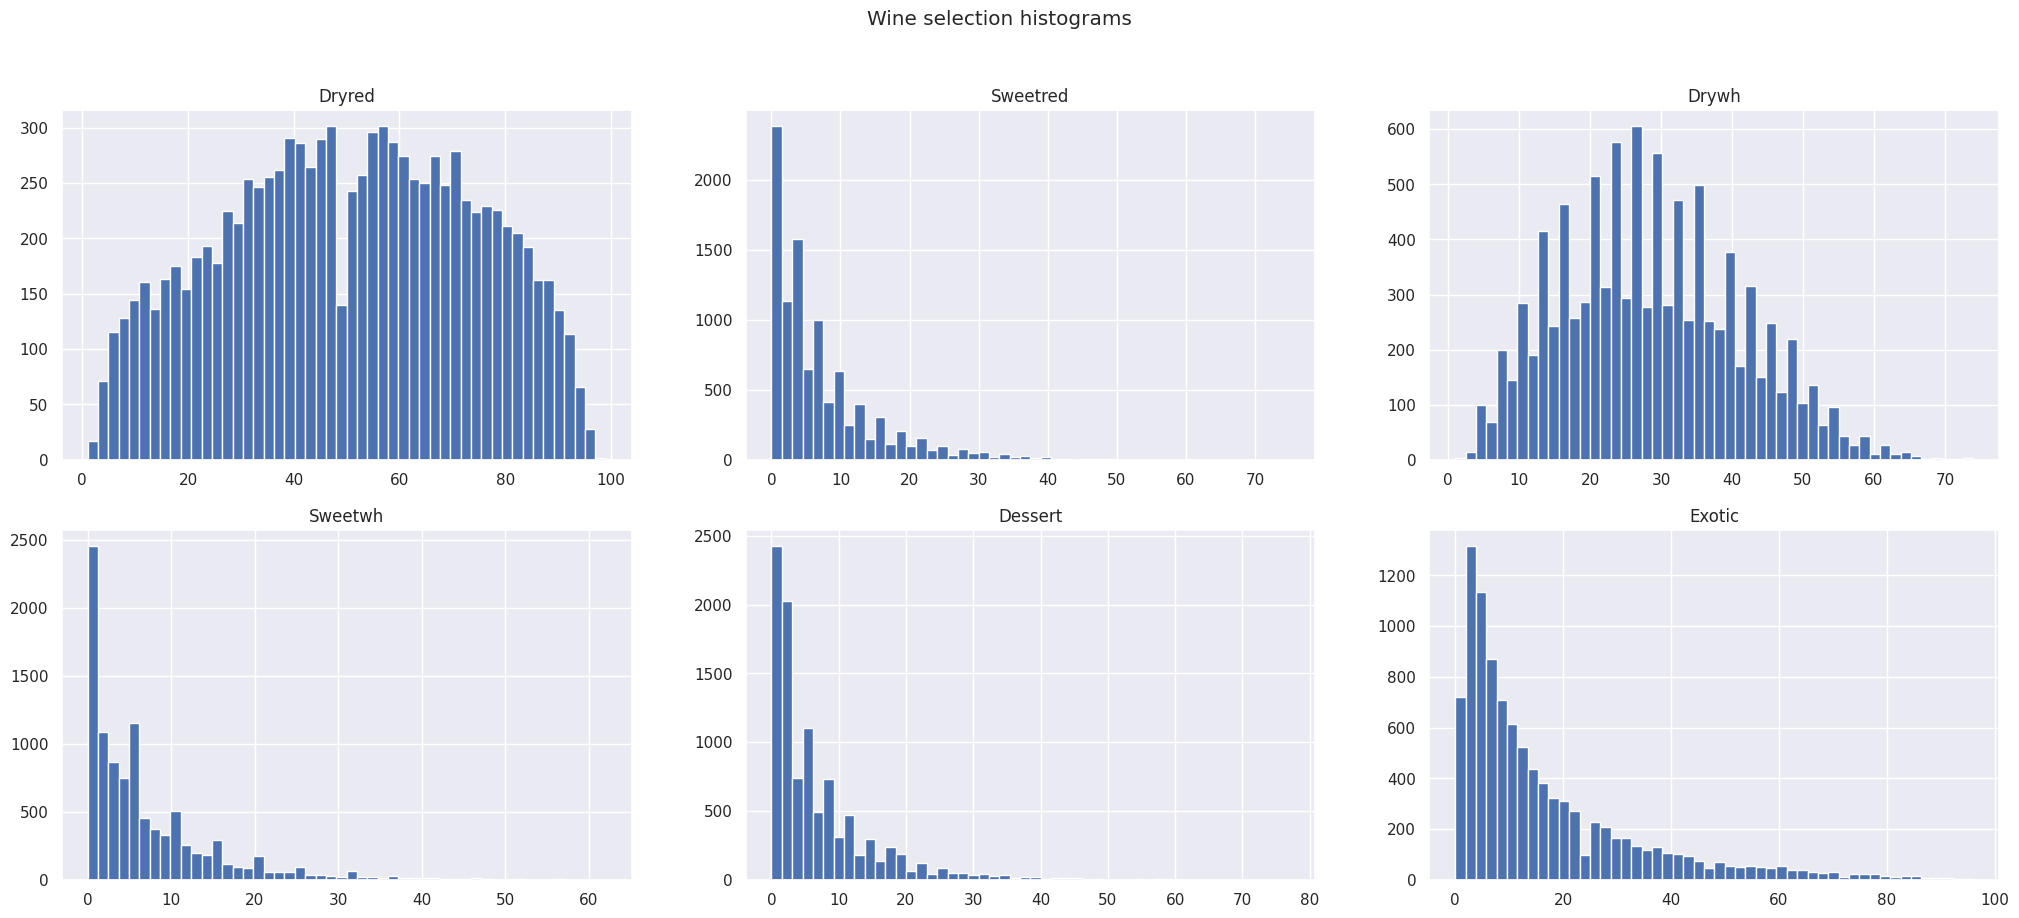

In [ ]:
# Histogram analysis - wine selection

def plot_multiple_histograms(data, feats, title="Wine selection histograms", figsize=(25, 10)):
    fig, axes = plt.subplots(2, ceil(len(feats) / 2), figsize=figsize)
    for ax, feat in zip(axes.flatten(), feats):
      ax.hist(data[feat],bins=50)
      ax.set_title(feat)
    plt.suptitle(title)
    plt.show()
    return
sns.set()
var_wine_type = ['Dryred', 'Sweetred', 'Drywh', 'Sweetwh', 'Dessert', 'Exotic']
plot_multiple_histograms(df, var_wine_type)

Two types in this case:
**Dryred** and **Drywh** are normal distributions, whereas the others are half-normal distributions with mostly low values. To be mentioned that all variables (excluding "**Exotic**") must total 100. We can already notice that most of the sales are limited to  **dry red** and **dry white** wines.

###Boxplot overview

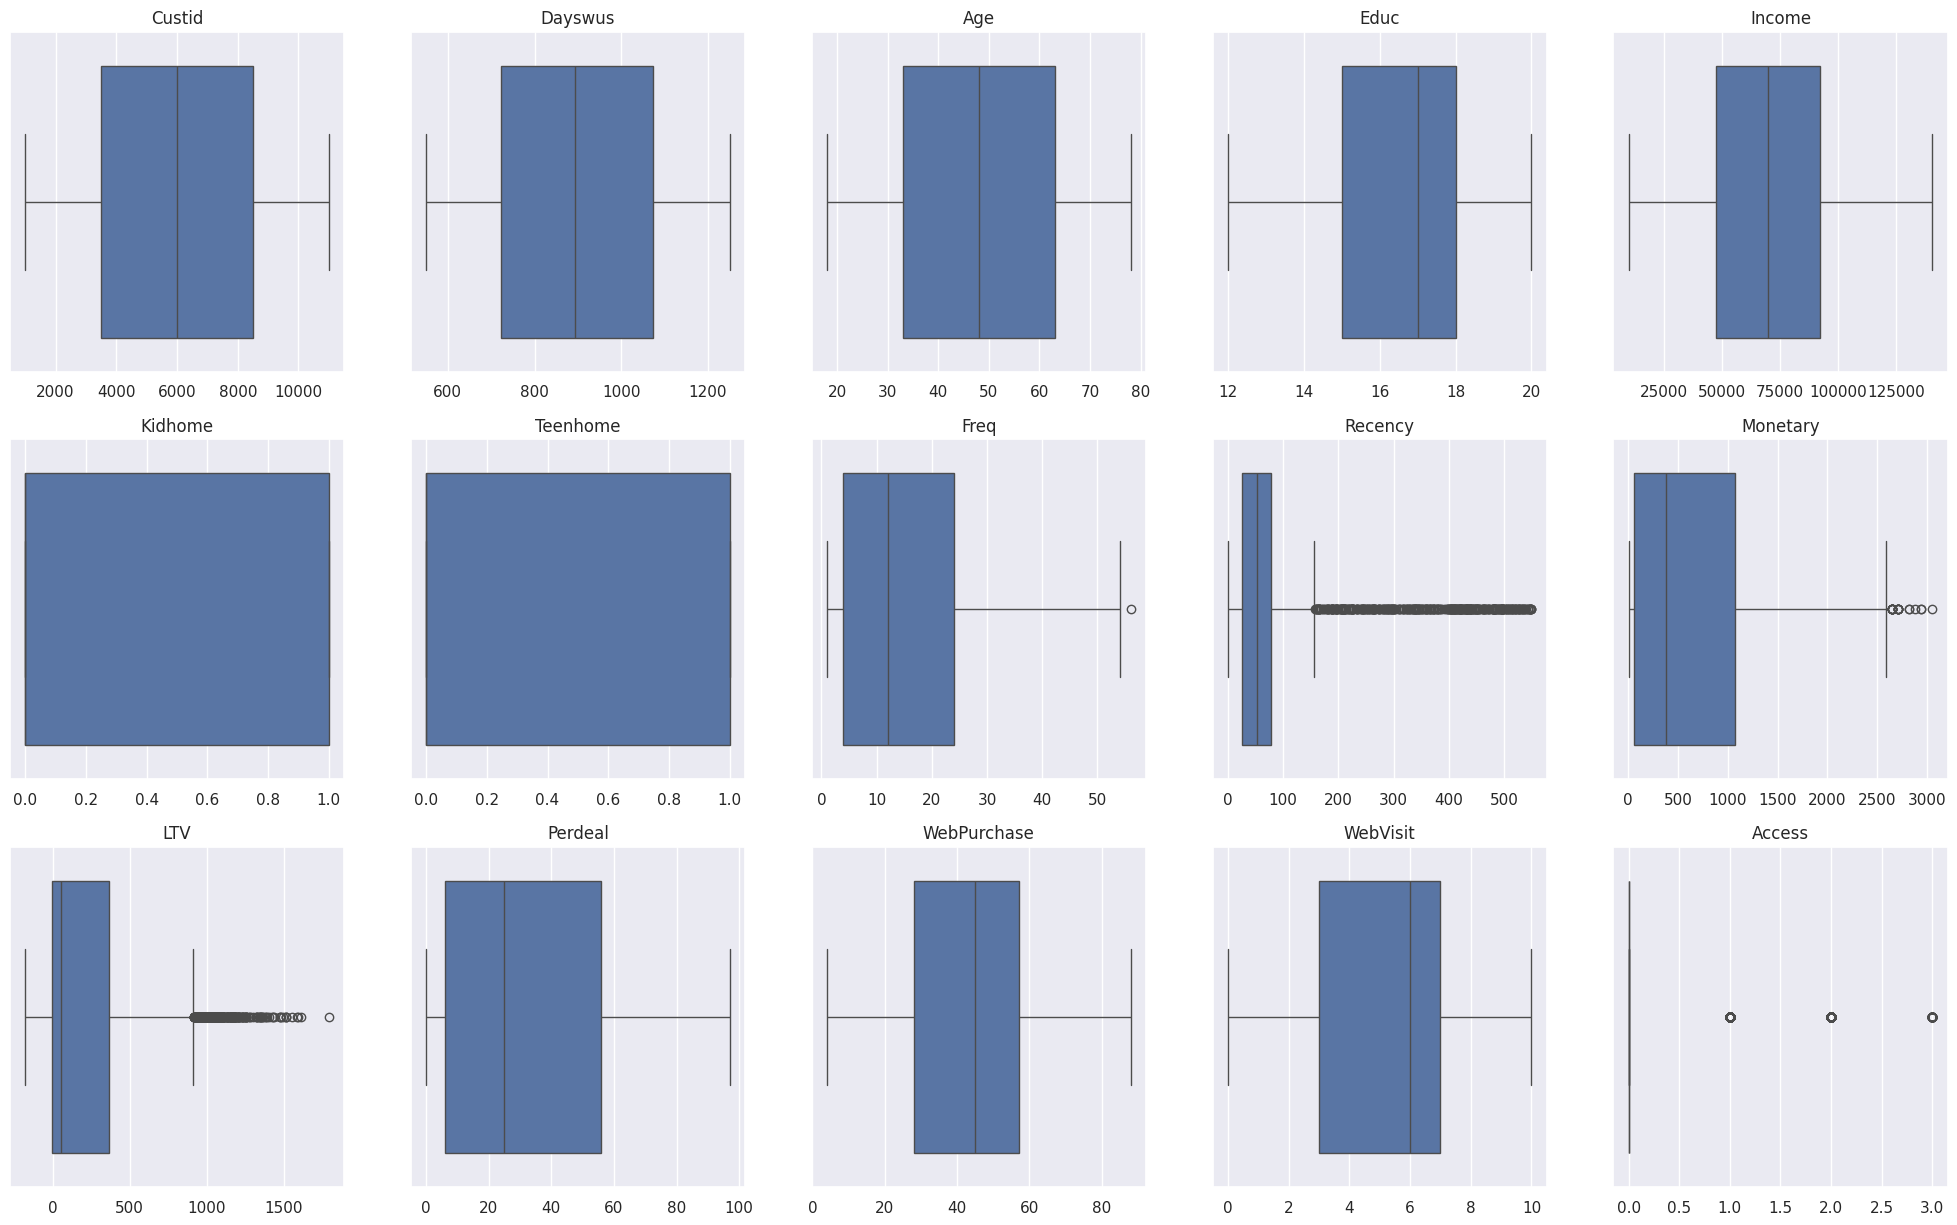

In [ ]:
# Boxplot analysis - customer profile

def plot_multiple_boxplots(data, feats, title="Numeric Variables' Box Plots", figsize=(25, 15)):
    fig, axes = plt.subplots(3, ceil(len(feats) / 3), figsize=figsize)
    for ax, feat in zip(axes.flatten(), feats):
      sns.boxplot(x=data[feat], ax=ax)
      ax.set_title(feat)
      ax.set_xlabel("")
plot_multiple_boxplots(df, var_customer_profile)

The boxplot analysis confirmed what mentioned with the histogram analysis.

There are some distribution with a very long right tail where potential outliers need to be assessed.
These are Freq, Recency, Monetary, LTV.

Access, as mentioned before, not well represented with histograms and boxplots.

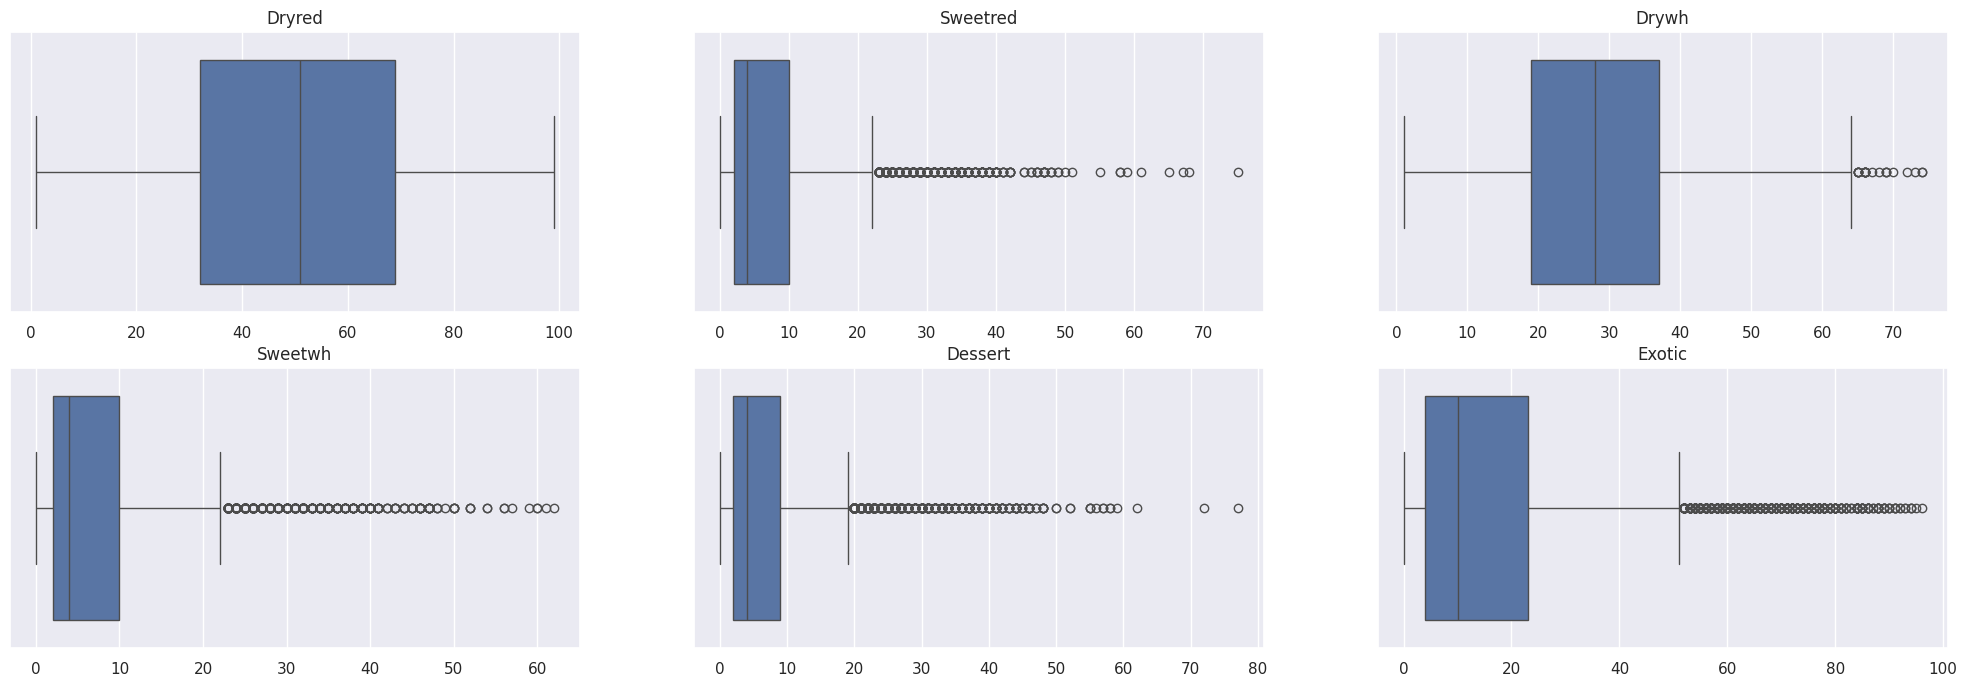

In [ ]:
# Boxplot analysis - wine selection

def plot_multiple_boxplots(data, feats, title="Numeric Variables' Box Plots", figsize=(25, 8)):
    fig, axes = plt.subplots(2, ceil(len(feats) / 2), figsize=figsize)
    for ax, feat in zip(axes.flatten(), feats):
      sns.boxplot(x=data[feat], ax=ax)
      ax.set_title(feat)
      ax.set_xlabel("")
plot_multiple_boxplots(df, var_wine_type)

Two normal and symmetric distributions, the other four are half-normal with values exceeding the right whisker, but they are not isolated. The strongest candidates for outliers are two values in Desserts and one in Sweetred.

###Correlation analysis (Pearson correlation coefficient and scatter plot)

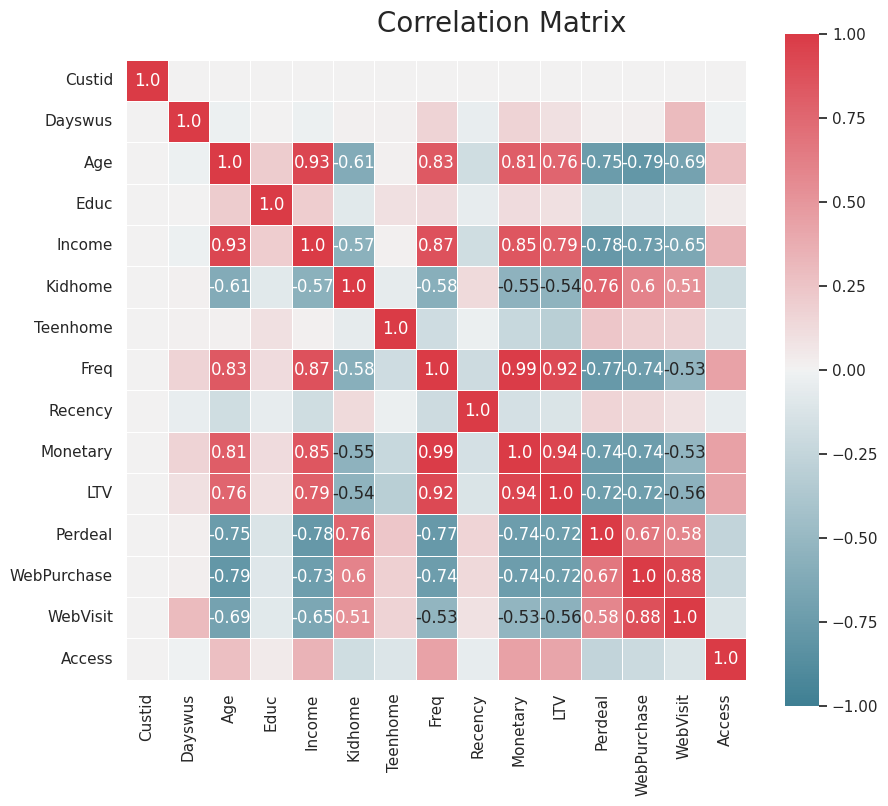

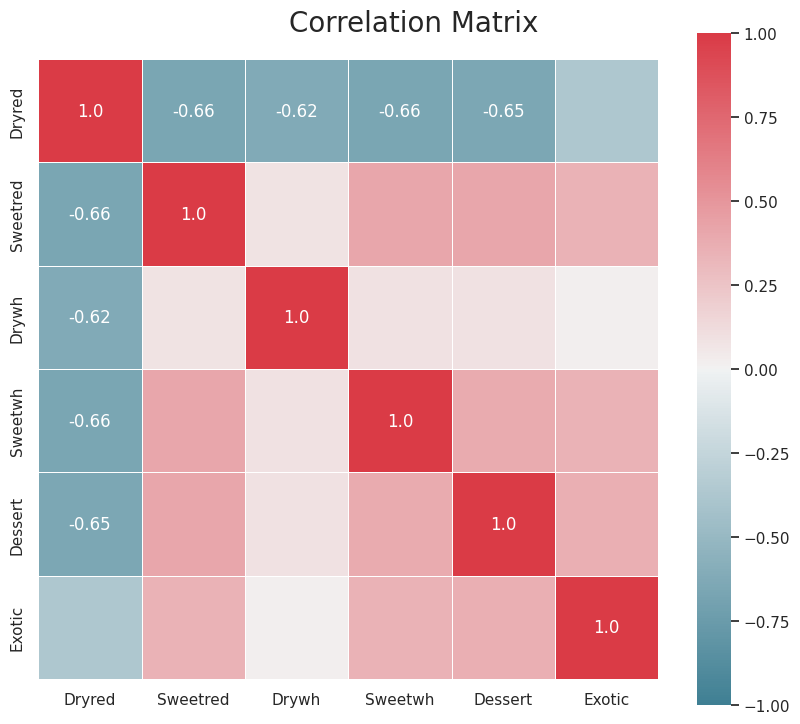

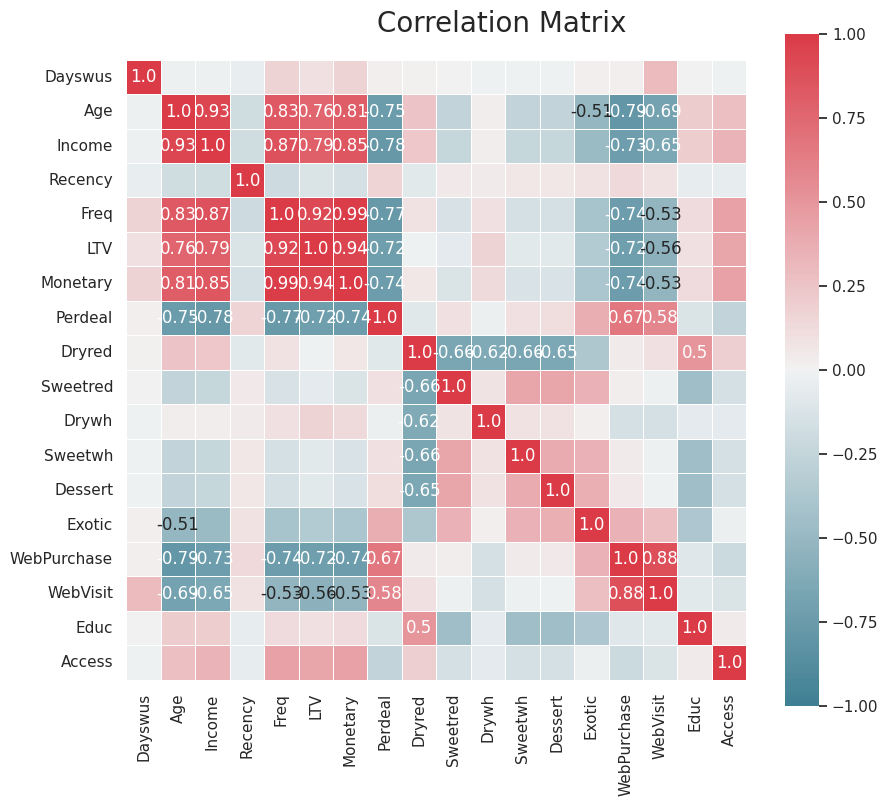

In [ ]:
# Correlation
num_var = ['Dayswus', 'Age','Income', 'Recency', 'Freq', 'LTV', 'Monetary', 'Perdeal', 'Dryred', 'Sweetred', 'Drywh', 'Sweetwh', 'Dessert', 'Exotic', 'WebPurchase','WebVisit','Educ','Access']

# Correlation Matrix
def plot_corr_matrix(df, feats, title="Correlation Matrix", method="pearson", figsize=(10,8)):
  fig = plt.figure(figsize=figsize)
  corr = np.round(df[feats].corr(method=method), decimals=2)
  mask_annot = np.absolute(corr.values) >= 0.5
  annot = np.where(mask_annot, corr.values, np.full(corr.shape,""))
  sns.heatmap(data=corr, annot=annot, cmap=sns.diverging_palette(220, 10, as_cmap=True),
              fmt='s', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
  fig.subplots_adjust(top=0.95)
  fig.suptitle(title, fontsize=20)
  plt.show()
  return

plot_corr_matrix(df, var_customer_profile)
plot_corr_matrix(df, var_wine_type)
plot_corr_matrix(df, num_var)


The analysis by wine type does not show any surprise. Only strong correlation is the negative one between dry red wines and all the other types. In this case the options for analysis are limited, since data is in percentage and by definition a higher percentage in one column leaves lower percentages available in the other ones.

The analysis by customer profile is more interesting. In particular, there is a very high correlation
between three variables, which suggests some of them might be redundant. These are: Freq, Monetary and LTV.
In addition, as we could have expected, strong correlation between Age and Income,
and strong correlation between WebPurchase and WebVisit.

In [ ]:
# Pairwise Relationship of Numerical Variables concerning customer value

var_correlation_relevant = ['Dayswus', 'Age', 'Income', 'Freq', 'Recency', 'Monetary', 'LTV', 'Perdeal']

sns.set()
sns.pairplot(df[var_correlation_relevant], diag_kind="hist")
plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)
plt.show()

Following the previous analysis, it makes sense to exclude from the plot all binary variables, all discrete variables, and Custid which is irrelevant from our customer profile linked variables.

We notice several strong positive correlations and some strong negative ones.
The most important finding is that Freq and Monetary seem too similar to be considered as separate variables.
Freq and Monetary seem to be redundant. They are also very strongly correlated with LTV.

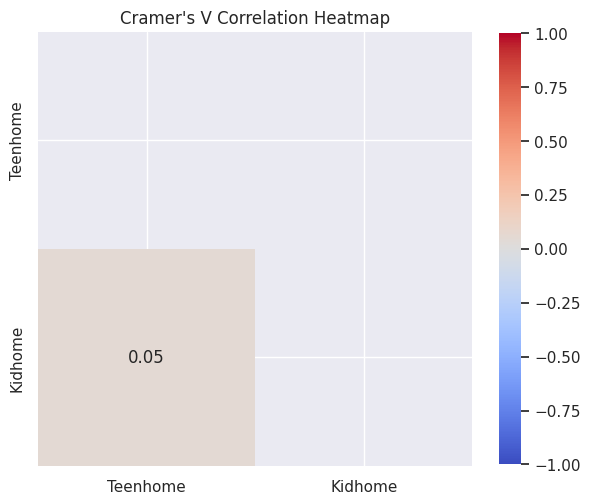

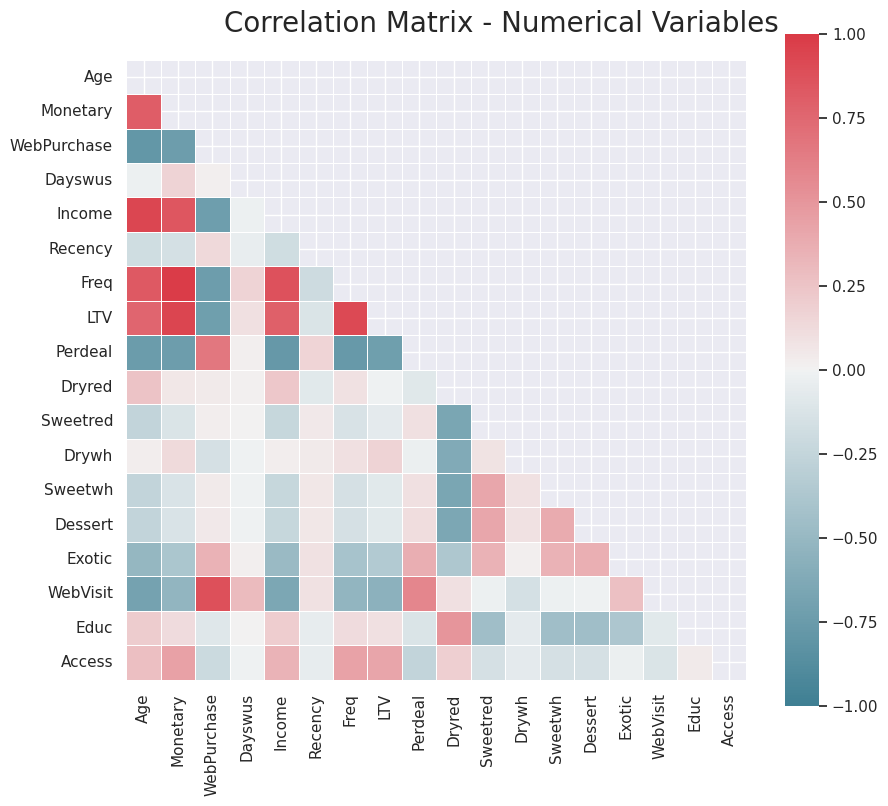

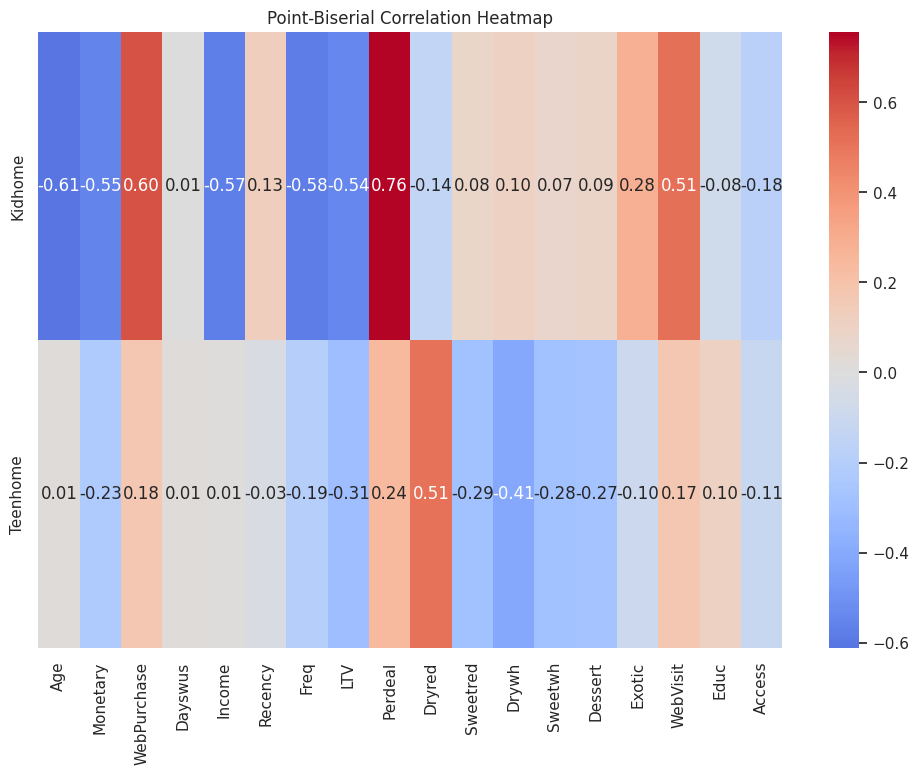

In [ ]:
# Variable Definitions
numerical_variables = ['Age', 'Monetary', 'WebPurchase', 'Dayswus', 'Income', 'Recency', 'Freq', 'LTV', 'Perdeal', 'Dryred', 'Sweetred', 'Drywh', 'Sweetwh', 'Dessert', 'Exotic', 'WebVisit','Educ', 'Access']
numerical_variables_no_wine = ["Age", "Income", "WebVisit", "Freq", "Perdeal", "Monetary", "WebPurchase", "LTV"]
categorical_variables = ['Teenhome', 'Kidhome']

# Subsetting the DataFrame
numerical_data = df[numerical_variables]
categorical_data = df[categorical_variables]


### CATEGORICAL DATA
# Cramer's V script for categorical correlation

def cramerV(label, x):
  confusion_matrix = pd.crosstab(label, x)
  chi2 = chi2_contingency(confusion_matrix)[0]
  n = confusion_matrix.sum().sum()
  r, k = confusion_matrix.shape
  phi2 = chi2 / n
  phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
  rcorr = r - ((r - 1) ** 2) / (n - 1)
  kcorr = k - ((k - 1) ** 2) / (n - 1)

  try:
      if min((kcorr - 1), (rcorr - 1)) == 0:
          warnings.warn("Unable to calculate Cramer's V using bias correction. Consider not using bias correction", RuntimeWarning)
          v = 0
      else:
          v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
  except:
      print("Error in Cramer's V calculation")
      v = 0
  return v

def plot_cramer(df):
  cramer = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
  for column_of_interest in df.columns:
      for column in df.columns:
          if column_of_interest != column:
              v = cramerV(df[column_of_interest], df[column])
              cramer.loc[column_of_interest, column] = v

  cramer.fillna(value=0, inplace=True)

  # Mask the upper triangle
  mask = np.triu(np.ones_like(cramer, dtype=bool))

  plt.figure(figsize=(7, 7))
  sns.heatmap(
      cramer,
      mask=mask,
      annot=True,
      fmt=".2f",
      cmap="coolwarm",
      square=True,
      cbar_kws={"shrink": .8},
      vmin=-1,  # Minimum value for the color scale
      vmax=1,    # Maximum value for the color scale
      linewidths=0,  # Remove gridlines between cells
      linecolor='none'  # Removes lines around cells
  )
  plt.title("Cramer's V Correlation Heatmap")
  plt.show()

plot_cramer(categorical_data)


### NUMERICAL DATA - Correlation Matrix
def plot_corr_matrix(df, feats, title="Correlation Matrix - Numerical Variables", method="pearson", figsize=(10,8)):
  fig = plt.figure(figsize=figsize)
  corr = np.round(df[feats].corr(method=method), decimals=2)
  np.fill_diagonal(corr.values, np.nan)  # Remove diagonal
  mask = np.triu(np.ones_like(corr, dtype=bool))  # Mask upper triangle
  mask_annot = np.absolute(corr.values) >= 10
  annot = np.where(mask_annot & ~mask, corr.values, np.full(corr.shape, ""))  # Annotate significant correlations
  sns.heatmap(data=corr, annot=annot, cmap=sns.diverging_palette(220, 10, as_cmap=True),
              fmt='s', vmin=-1, vmax=1, center=0, square=True, linewidths=.5, mask=mask)
  fig.subplots_adjust(top=0.95)
  fig.suptitle(title, fontsize=20, ha='center')  # Explicitly center the title
  plt.show()

plot_corr_matrix(df, numerical_variables)


### Point-Biserial Correlation (Categorical Binary vs. Numeric)
def calculate_point_biserial(df, binary_cols, numeric_cols):
  correlation_matrix = pd.DataFrame(index=binary_cols, columns=numeric_cols)

  for binary_col in binary_cols:
      for numeric_col in numeric_cols:
          correlation, _ = pointbiserialr(df[binary_col], df[numeric_col])
          correlation_matrix.loc[binary_col, numeric_col] = correlation
  return correlation_matrix.astype(float)

binary_columns = ['Kidhome', 'Teenhome']

correlation_matrix = calculate_point_biserial(df, binary_columns, numerical_variables)

# Plot Point-Biserial Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Point-Biserial Correlation Heatmap')
plt.show()

**Cramers V** is a effect size algorithm that is calculated in the following manner:



*   Determine which field has the fewest number of categories.
*   Subtract 1 from the number of categories in this field.
*   Multiply the result by the total number of records.
*   Divide the chi-square value by the previous result. The chi-square value is obtained from the chi-square test of independence
*   Take the square root.

Interpretation of Cramers V (general interpretation, subject to the field of study):

*   ES ≤ 0.2 : The result is weak. Although the result is statistically significant, the fields are only weakly associated.

*   0.2 < ES ≤ 0.6 : The result is moderate. The fields are moderately associated.

*   ES > 0.6 : The result is strong. The fields are strongly associated.

The interpretation of the effect size (ES) is subject to the field of study.

**Point-Biserial Correlation**

The Point-Biserial Correlation is a special case of the Pearson Correlation (If you treat the binary variable as continuous the computation is mathematically equivalent to Pearson correlation). Is used when you want to measure the relationship between a continuous variable and a variable that has two values (binary variable).

Interpretation

*   The value also ranges from −1 to +1, but it specifically represents how the mean of the continuous variable differs between the two groups defined by the binary variable.
*   A higher absolute value indicates a stronger relationship between the binary grouping and the continuous variable.

# Data Preparation

## Data cleaning





### Feature selection

* Removal of features based on their redundancy
* This removal is performed to reduce Bias in Clustering Algorithms, and must be done prior to the Outlier detection to avoid interference with DBSCAN and other clustering algorithms.

Vars to be removed **Custid**, **Monetary**, **Age** and **WebPurchase**

We need to remove some of them to reduce the complexity of the model, but also to reduce the redundancy. In our opinion, our cut line should above 0.8 (or below -0.8). In these situations, We understand that the redundancy is too high to keep it on the model.

We still have some Highly Correlated Variables (web_visit x web_purchase)- Our decision is to choose WebVisit. Since WebPurchase normally has correlations above 0.7 with other attributes, unlike WebVisit

In [ ]:
df_copy = df.copy()
df_copy.drop(columns =['Custid','Age', 'Monetary', 'WebPurchase'], inplace=True)

In [ ]:
df_copy.head(3)

,Dayswus,Educ,Income,Kidhome,Teenhome,Freq,Recency,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebVisit,Access
0,789,16,90782,0,0,29,66,699,3,37,5,44,10,3,2,4,1
1,623,20,113023,0,0,31,6,565,1,55,1,38,4,2,2,1,0
2,583,18,28344,1,0,4,69,-3,66,32,19,24,1,24,63,7,1


* Since we don't have missing, incorrect, incomplete or duplicated data. There are no more tasks at this step. We could advance to data transformation.:

## Data transformation


### Feature engineering / Data Integration
* Feature engineering: Creating new aggregated or derived features from existing data to uncover insights;

(we won't be addressing class imbalance because we only have binary columns which won't be used for clustering)

In [ ]:
#Transforming Access into a binary variable
df_copy['Access'] = [1 if i > 0 else 0 for i in df_copy['Access']] #List Comprehension

print(df_copy[['Access']].value_counts())

#Creation of Minor_home, a binary feature that analyses if the customer has a kid or teen at home
df_copy['Minor_home'] = (df_copy['Kidhome'] > 0) | (df_copy['Teenhome'] > 0)
df_copy['Minor_home'] = df_copy['Minor_home'].astype(int)
print(df_copy[['Minor_home']].value_counts())


Access
0         8009
1         1991
Name: count, dtype: int64
Minor_home
1             7054
0             2946
Name: count, dtype: int64


### Anomaly detection - Outliers

*   **First step before normalization, manual detection and treatment of outliers**

Manual Outlier Detection and Treatment using Winsorizing (defining a ceiling and floor attributes)

*   Set thresholds to identify extreme values
*   Transform the variable to induce normality



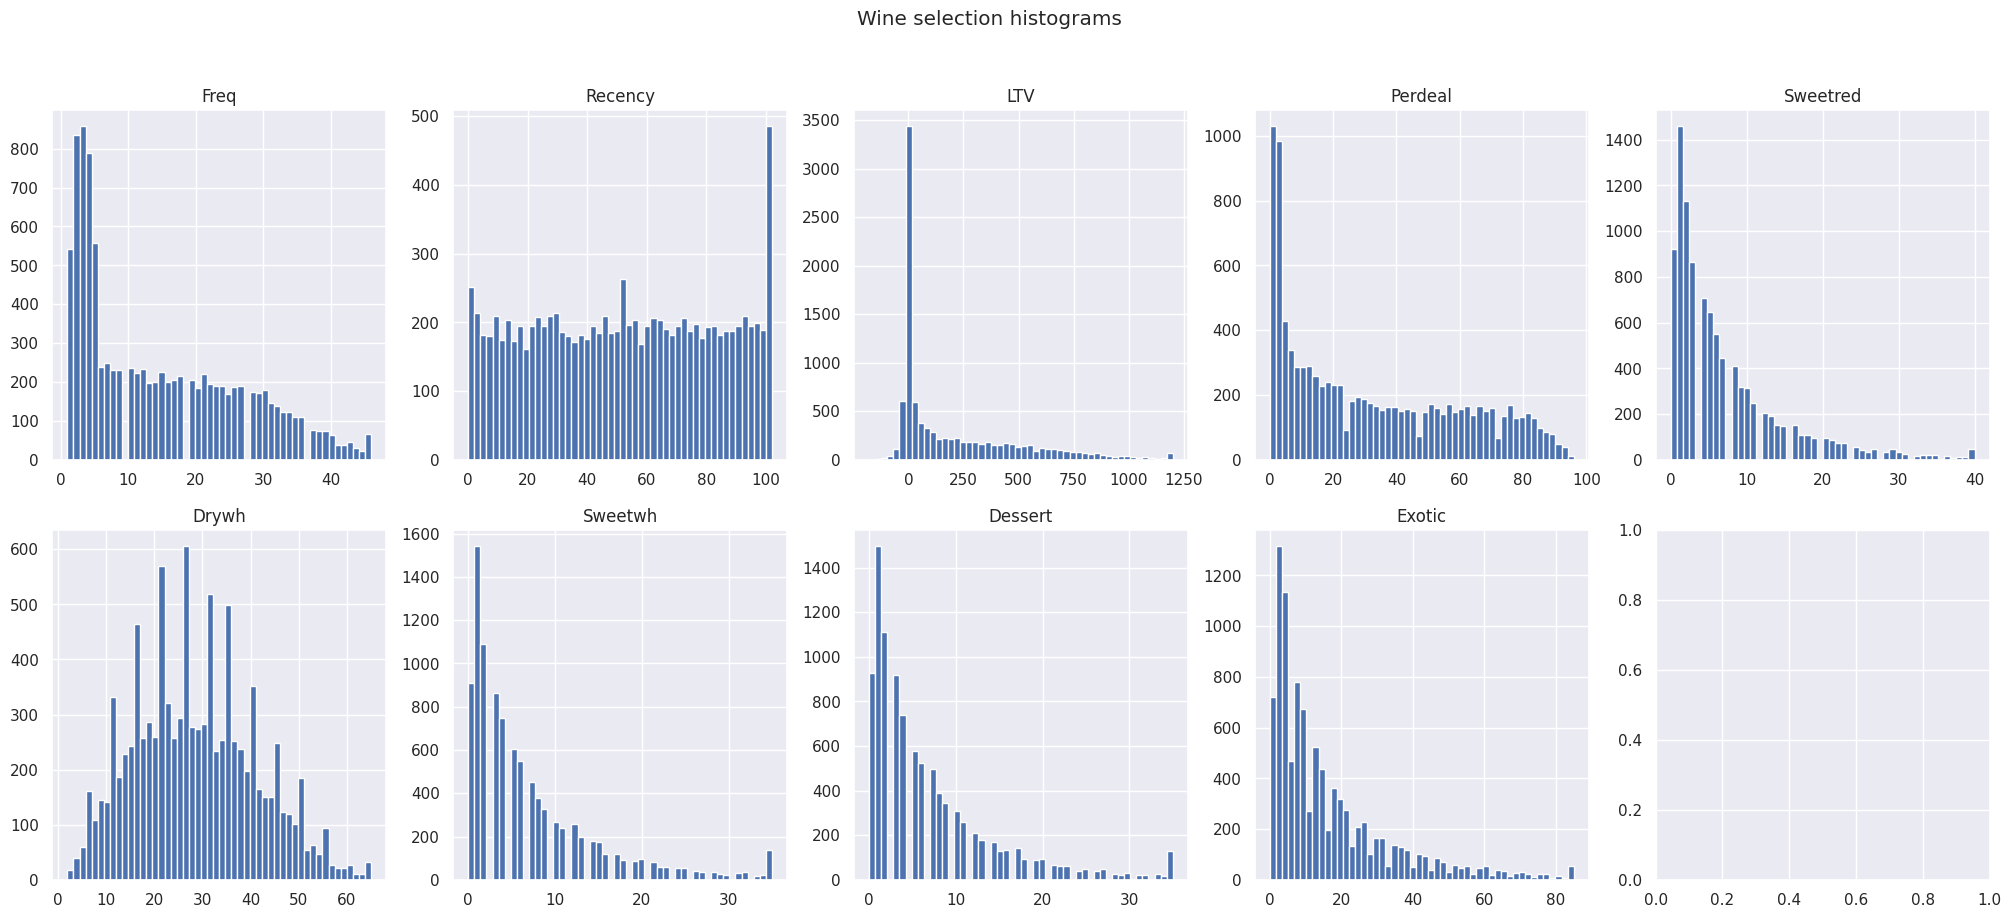

In [ ]:
#df_copy['Age'] = np.where(df_copy['Age'] < floor, floor, df_copy['Age'])

# Winsorize the data
df_temporary = df_copy.copy()

df_temporary.loc[df_temporary['Freq'] > 46, 'Freq'] = 46
df_temporary.loc[df_temporary['Recency'] > 102, 'Recency'] = 102
df_temporary.loc[df_temporary['LTV'] > 1200, 'LTV'] = 1200
df_temporary.loc[df_temporary['Perdeal'] > 96, 'Perdeal'] = 96

#Wines
df_temporary.loc[df_temporary['Sweetred'] > 40, 'Sweetred'] = 40
df_temporary.loc[df_temporary['Drywh'] > 65, 'Drywh'] = 65
df_temporary.loc[df_temporary['Drywh'] < 2, 'Drywh'] = 2
df_temporary.loc[df_temporary['Sweetwh'] > 35, 'Sweetwh'] = 35
df_temporary.loc[df_temporary['Dessert'] > 35, 'Dessert'] = 35
df_temporary.loc[df_temporary['Exotic'] > 85, 'Exotic'] = 85

Winsorize_columns = ['Freq','Recency','LTV', 'Perdeal','Sweetred', 'Drywh', 'Sweetwh', 'Dessert', 'Exotic']
plot_multiple_histograms(df_temporary, Winsorize_columns)
#plot_multiple_histograms(df_copy, Winsorize_columns)



### Data normalization
* Data normalization or scaling: Standardizing data ranges to enable *meaningful* comparisons.



In [ ]:
# Use MinMaxScaler to scale the data
num_var = ['Dayswus', 'Income', 'Recency', 'Freq', 'LTV', 'Perdeal', 'Dryred', 'Sweetred', 'Drywh', 'Sweetwh', 'Dessert', 'Exotic', 'WebVisit','Educ', 'Access']

#Define the normalized values
scaler = MinMaxScaler()
scaled_feat = scaler.fit_transform(df_temporary[num_var])

#Change Dataset with normalized values
df_temporary[num_var] = scaled_feat

# Checking max and min of minmaxed variables
df_temporary.describe().round(2)

,Dayswus,Educ,Income,Kidhome,Teenhome,Freq,Recency,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebVisit,Access,Minor_home
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00
mean,0.50,0.59,0.46,0.42,0.47,0.30,0.51,0.28,0.34,0.50,0.18,0.42,0.20,0.20,0.19,0.52,0.2,0.71
std,0.29,0.23,0.21,0.49,0.50,0.27,0.30,0.21,0.29,0.24,0.19,0.20,0.22,0.21,0.20,0.23,0.4,0.46
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
25%,0.25,0.38,0.29,0.00,0.00,0.07,0.25,0.13,0.06,0.32,0.05,0.27,0.06,0.06,0.05,0.30,0.0,0.00
50%,0.49,0.62,0.46,0.00,0.00,0.24,0.51,0.17,0.26,0.51,0.10,0.41,0.11,0.11,0.12,0.60,0.0,1.00
75%,0.75,0.75,0.63,1.00,1.00,0.51,0.77,0.39,0.58,0.69,0.25,0.56,0.29,0.26,0.27,0.70,0.0,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00


In [ ]:
# Count values of binary variables
# List of columns to include
binary_vars = ['Kidhome', 'Teenhome', 'Minor_home', 'Access']
value_counts_dict = {}

#Iterate columns and define
for i in binary_vars:
    value_counts_dict[i] = df_copy[i].value_counts()
value_counts_df = pd.DataFrame(value_counts_dict)

print(value_counts_df)


   Kidhome  Teenhome  Minor_home  Access
0     5812      5302        2946    8009
1     4188      4698        7054    1991


### Outlier Detection Using DBSCAN

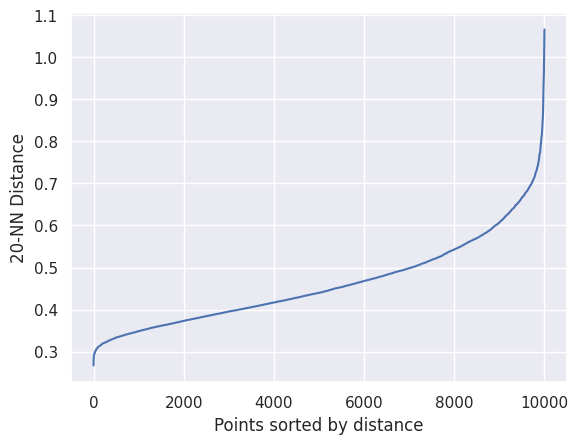

In [ ]:
# K-distance graph to find out the right eps value
def plot_kdist_graph(df, feats, n_neighbors=20):
  neigh = NearestNeighbors(n_neighbors=n_neighbors) #Calculate avg distance to neighbours
  neigh.fit(df[feats])
  distances, _ = neigh.kneighbors(df[feats]) #The distances
  distances = np.sort(distances[:, -1]) # We sort the average distances of the points
  plt.ylabel("%d-NN Distance" % n_neighbors)
  plt.xlabel("Points sorted by distance")
  plt.plot(distances)
  plt.show()

plot_kdist_graph(df_temporary, num_var)



*   Based on the analysis fo the previous chart, we define the threshold to be around 0.6

Based on our previous discover, we define the hyperparameters for DBSCAN to fid the outliers



In [ ]:
dbscan = DBSCAN(eps=0.6, min_samples=30, n_jobs=4).fit(df_temporary[num_var])
labels = dbscan.labels_

# Number of estimated clusters
print("Number of estimated clusters  : %d" % len(np.unique(labels)))

print("Points in cluster -1 are noise rows.")
print("Counter of cluster labels     :", Counter(labels))
print("Percentage of noise rows      :", round(100*Counter(labels)[-1]/df_copy.shape[0],2))

def split_noise_rows(df, feats, dbs_model):
  dbscan_labels = dbs_model.fit_predict(df[feats])

  df_concat = pd.concat([df,
                         pd.Series(dbscan_labels,
                                   name='dbscan_labels',
                                   index=df.index)],
                            axis=1)

  df_noise = df_concat[df_concat['dbscan_labels']==-1].copy()
  df_nonoise = df_concat[df_concat['dbscan_labels']>=0].copy()
  return df_noise, df_nonoise, df_concat

df_noise, df_nonoise, df_combined_noise = split_noise_rows(df_temporary, num_var, dbscan)

# Remove cluster labels from data
df_copy2 = df_nonoise.drop(columns=['dbscan_labels'])

# Final dataset
print("Cleaned dataframe shape:", df_copy2.shape)

Number of estimated clusters  : 3
Points in cluster -1 are noise rows.
Counter of cluster labels     : Counter({1: 7876, 0: 1879, -1: 245})
Percentage of noise rows      : 2.45
Cleaned dataframe shape: (9755, 18)


## Data Splitting

*   Data splitting according with each segment

In [ ]:
# Available Columns ['Dayswus', 'Income', 'Recency', 'Freq', 'LTV', 'Perdeal', 'Dryred', 'Sweetred', 'Drywh', 'Sweetwh', 'Dessert', 'Exotic', 'WebVisit','Educ', 'Access']

Segment_1_columns = ['Freq', 'Recency', 'Dayswus', 'WebVisit', 'Perdeal', 'Educ']
Segment_2_columns = ['Dryred', 'Sweetred', 'Drywh', 'Sweetwh', 'Dessert', 'Exotic']

Segment_1_Data = df_copy2[Segment_1_columns].copy()
Segment_2_Data = df_copy2[Segment_2_columns].copy()


In [ ]:
Segment_1_Data.head(4)

,Freq,Recency,Dayswus,WebVisit,Perdeal,Educ
0,0.622222,0.647059,0.341429,0.4,0.031250,0.500
1,0.666667,0.058824,0.104286,0.1,0.010417,1.000
3,0.444444,0.098039,0.490000,0.5,0.125000,0.875
4,0.533333,0.254902,0.731429,0.6,0.052083,0.750


# Data Modeling

## Segmentation 1: Engagement/Value Segments



### Initial Insights

In order to define the Engagement/Value Segments we chose to use the following variables (reasoning in parentheses):

1.   Frequency (is highly correlated with Monetary, LTV, Income and Age. We chose to keep Frequency instead of the other 4 because it has the highest average correlation in between those variables)
2.   Recency (is an interesting variable when looking into value/engagement segments and has no high correlation to other variables)
3. Days with us (is very interesting in order to understand the loyalty of the customer and also has no high correlation to other variables)
4. WebVisit (is relevant because we want to understand the patterns of how our customers engage with us. We chose to use WebVisit instead of WebPurchase, as those two are highly correlated, but WebVisit is less correlated to other variables than WebPurchase)
5. PerDeal (we want to include this variable in the segmentation in order to differentiate which customers tend to buy products on offer and which don't. There are several medium-high correlations of this variable to other, but as none of them exceeds our defined threshold of 0.8 we decided to keep this variable for the segmentation)
6. Education (we want to understand if education plays a significant role when defining the value/engagement segments of our customers)



In [ ]:
# Let's try a first clustering using k-means and look at the results
kmclust = KMeans(n_clusters=10,     # starting with a high number of clusters to get a feeling for the distances
                 init='k-means++',
                 n_init=15,
                 random_state=1)    # we will continue using random_state = 1 for reproducability of the results

kmclust.fit(Segment_1_Data)
kmclust.predict(Segment_1_Data)

# Let's look at the clusters in a dataframe to get a feeling for it
pd.DataFrame(kmclust.transform(Segment_1_Data))

,0,1,2,3,4,5,6,7,8,9
0,0.987209,0.281391,0.584903,0.642238,0.439762,0.955193,0.802203,0.625893,0.467762,1.016003
1,1.278198,0.831892,1.182353,0.798757,0.995903,1.178096,1.288582,0.865150,0.489212,1.527811
2,0.727693,0.770020,0.728707,0.439265,0.784756,0.831473,1.002947,0.419628,0.511104,1.069208
3,0.688997,0.779142,0.535929,0.605974,0.586270,0.949571,1.025882,0.205807,0.636359,0.979414
4,0.854675,1.248876,1.010706,0.980065,1.416531,0.740268,0.738477,1.324471,1.400144,0.693673
...,...,...,...,...,...,...,...,...,...,...
9750,0.319249,1.243553,0.895750,0.764608,1.265397,0.538181,0.954665,0.913910,1.135229,0.739059
9751,0.794008,0.487927,0.248732,0.638006,0.411964,0.922346,0.729058,0.544631,0.702342,0.784561
9752,1.163515,0.439519,0.784977,0.796884,0.687801,1.043185,0.859224,0.877497,0.638871,1.144521
9753,1.360088,0.420800,0.912428,0.926780,0.775953,1.219793,0.899628,1.077127,0.804829,1.257266


### Elbow Curve

In [ ]:
# As we need to find the most appropriate k for our clustering, we define a function showing us the Elbow Curve up to 10 clusters, so we can make an educated decision

def plot_inertia(df, max_k=10):
  range_clusters = range(1, max_k+1)

# Create a for loop that loops through a k-value from 1 to 10 and calculates the inertia of each k
  inertia = []
  for n_clus in range_clusters:
      kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
      kmclust.fit(df)
      inertia.append(kmclust.inertia_)


  # The inertia plot to visualize the Elbow Curve
  plt.figure(figsize=(9,5))
  plt.plot(range_clusters, inertia)
  plt.ylabel("Inertia: SSw")
  plt.xlabel("Number of clusters")
  plt.xticks(range_clusters)
  plt.title("Inertia plot over clusters", size=15)
  plt.show()

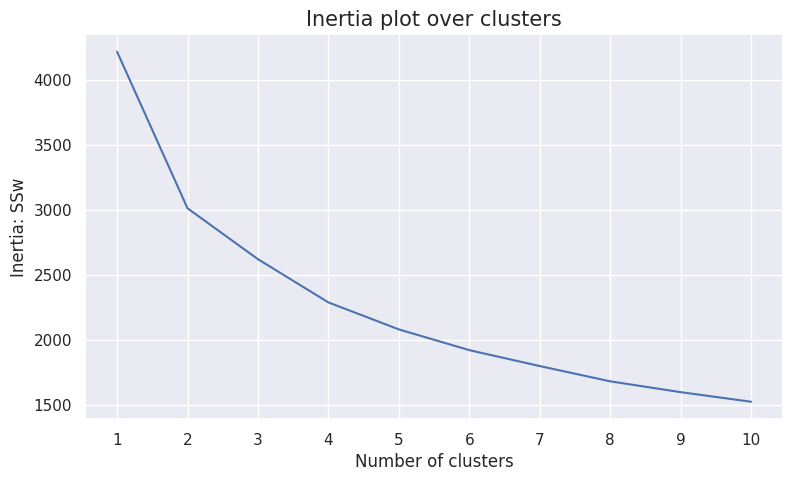

In [ ]:
plot_inertia(Segment_1_Data)
# Even though the result of the Elbow Curve has room for interpretation and discussion, as it has 2 noticeable "elbows", we decide to go with 4 clusters instead of 2 based on this insight, as after 4 clusters the reduction of the inertia flattens significantly and the difference in intertia between 2 and 4 clusters is still quite big.

### Silhouette Score

In [ ]:
# We also want to use the Silhouette Score method for defining the k in order to compare the results with the Elbow Curve

def plot_silhouette_score(df, max_k=10):
  range_clusters = range(2, max_k+1)

  # Storing average silhouette metric
  avg_silhouette = []
  for nclus in range_clusters:
      kmclust = KMeans(n_clusters=nclus, init='k-means++', n_init=15, random_state=1)
      cluster_labels = kmclust.fit_predict(df)

      # Printing the average silhouette score for each of the ks
      silhouette_avg = silhouette_score(df, cluster_labels)
      avg_silhouette.append(silhouette_avg)
      print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")

  # Plotting the average Silhouette Score for better comprehension
  plt.figure(figsize=(9,5))
  plt.plot(range_clusters, avg_silhouette)
  plt.ylabel("Average silhouette")
  plt.xlabel("Number of clusters")
  plt.xticks(range_clusters)
  plt.title("Average silhouette plot over clusters", size=15)
  plt.show()

For n_clusters = 2, the average silhouette_score is : 0.2544198586005505
For n_clusters = 3, the average silhouette_score is : 0.2081440068495431
For n_clusters = 4, the average silhouette_score is : 0.19580403980796676
For n_clusters = 5, the average silhouette_score is : 0.18837809520884954
For n_clusters = 6, the average silhouette_score is : 0.1873463741293487
For n_clusters = 7, the average silhouette_score is : 0.17730624077983653
For n_clusters = 8, the average silhouette_score is : 0.18207743261184664
For n_clusters = 9, the average silhouette_score is : 0.17467918864823667
For n_clusters = 10, the average silhouette_score is : 0.17495493899057604


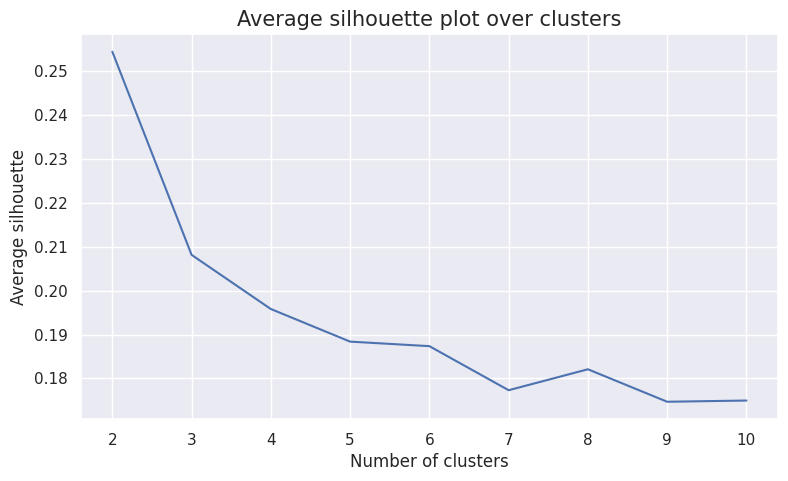

In [ ]:
plot_silhouette_score(Segment_1_Data)
# The Silhouette score shows us a different result than the Elbow Curve. It suggests that 2 clusters are the optimum without any room for discussion. We will try both and compare the results.

### K-means Clustering

In [ ]:
# Cluster solution based on Elbow Curve decision
number_clusters_elb = 4
kmclust_elb = KMeans(n_clusters=number_clusters_elb, init='k-means++', n_init=15, random_state=1)
km_labels_elb = kmclust_elb.fit_predict(Segment_1_Data)
km_labels_elb

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [ ]:
# Creating a new DF based on the k-means results
df_km_labeled_elb = pd.concat((Segment_1_Data, pd.Series(km_labels_elb, name='km_labels_elb', index=Segment_1_Data.index)),
                        axis=1)
df_km_labeled_elb

,Freq,Recency,Dayswus,WebVisit,Perdeal,Educ,km_labels_elb
0,0.622222,0.647059,0.341429,0.4,0.031250,0.500,0
1,0.666667,0.058824,0.104286,0.1,0.010417,1.000,0
3,0.444444,0.098039,0.490000,0.5,0.125000,0.875,0
4,0.533333,0.254902,0.731429,0.6,0.052083,0.750,3
5,0.088889,0.637255,0.345714,0.9,1.000000,1.000,1
...,...,...,...,...,...,...,...
9994,0.066667,0.058824,0.678571,0.8,0.687500,0.375,2
9995,0.488889,0.705882,0.595714,0.6,0.072917,0.625,3
9996,0.711111,0.735294,0.124286,0.5,0.031250,0.375,0
9997,0.644444,0.960784,0.051429,0.3,0.020833,0.875,0


In [ ]:
# Creating a function that will show the mean value of each variable grouped by cluster. This will be very useful for comparison & interpretation later.
def get_mean_bylabel(df, label_name):
  return df.groupby(label_name).mean()

In [ ]:
# Calling the function to get the mean values
get_mean_bylabel(df_km_labeled_elb, 'km_labels_elb')

,Freq,Recency,Dayswus,WebVisit,Perdeal,Educ
km_labels_elb,,,,,,
0,0.456002,0.481546,0.248012,0.289078,0.086264,0.628045
1,0.092979,0.804620,0.480530,0.652718,0.572216,0.575010
2,0.115665,0.256985,0.508796,0.665330,0.554462,0.571336
3,0.588574,0.507134,0.769895,0.461807,0.098865,0.627237


Interpretation of the results:

While Freq, Recency, Dayswus, WebVisit & Perdeal have very different values in different clusters, the variable Educ shows very little variability.
To further improve the segmentation by reducing dimensionality, we will remove this variable later and run the algorithm again.
Furthermore it is visible that cluster 1 & 2 are very similar to each other besides in the variable Recency.

But first let's see the outcomes with only 2 clusters, which was the solution with the highest silhouette score.

In [ ]:
# Cluster solution based on Silhouette Score decision
number_clusters_silh = 2
kmclust_silh = KMeans(n_clusters=number_clusters_silh, init='k-means++', n_init=15, random_state=1)
km_labels_silh = kmclust_silh.fit_predict(Segment_1_Data)
km_labels_silh

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [ ]:
# Creating a new DF based on the k-means results
df_km_labeled_silh = pd.concat((Segment_1_Data, pd.Series(km_labels_silh, name='km_labels_silh', index=Segment_1_Data.index)),
                        axis=1)
df_km_labeled_silh

,Freq,Recency,Dayswus,WebVisit,Perdeal,Educ,km_labels_silh
0,0.622222,0.647059,0.341429,0.4,0.031250,0.500,1
1,0.666667,0.058824,0.104286,0.1,0.010417,1.000,1
3,0.444444,0.098039,0.490000,0.5,0.125000,0.875,1
4,0.533333,0.254902,0.731429,0.6,0.052083,0.750,1
5,0.088889,0.637255,0.345714,0.9,1.000000,1.000,0
...,...,...,...,...,...,...,...
9994,0.066667,0.058824,0.678571,0.8,0.687500,0.375,0
9995,0.488889,0.705882,0.595714,0.6,0.072917,0.625,1
9996,0.711111,0.735294,0.124286,0.5,0.031250,0.375,1
9997,0.644444,0.960784,0.051429,0.3,0.020833,0.875,1


In [ ]:
# Calling the function to get the mean values
get_mean_bylabel(df_km_labeled_silh, 'km_labels_silh')

,Freq,Recency,Dayswus,WebVisit,Perdeal,Educ
km_labels_silh,,,,,,
0,0.104682,0.535254,0.496116,0.658292,0.560703,0.572620
1,0.527964,0.486209,0.498128,0.367382,0.085651,0.629345


Interpretations of the results:

Educ shows a similar pattern as it did in the previous version with 4 clusters, having only very little variance between the clusters. Interestingly in this version with only 2 clusters also the mean of Recency and Dayswus show almost no difference between the clusters, while this variable showed high variability when having 4 clusters.

As we have to make a decision here with which approach to proceed for the final clustering, we state that we will go with prefer 4 clusters over 2 clusters, as we believe that recency & loyalty (and therefore Dayswus) are very relevant variables from business perspective to categorize our customers and also we believe that with more than 350,000 customers a segmentation in only 2 groups would be too broad and we would lose relevant details, that can be very important for future marketing efforts.

Nevertheless, as we already discovered the outcomes with 2 & 4 clusters, let's have also a look at 3 clusters before making the final decision which k to use.

In [ ]:
# Cluster solution in between Elbow Curve (4 clusters) & Silhouette Score (2 clusters)
# As we have seen some similarities between cluster 1 & 2 in the first try and a loss of relevant differentiation in the second try, let's try the middle (3 clusters) instead
number_clusters_3 = 3
kmclust_3 = KMeans(n_clusters=number_clusters_3, init='k-means++', n_init=15, random_state=1)
km_labels_3 = kmclust_3.fit_predict(Segment_1_Data)
km_labels_3

df_km_labeled_3 = pd.concat((Segment_1_Data, pd.Series(km_labels_3, name='km_labels_3', index=Segment_1_Data.index)),
                        axis=1)

get_mean_bylabel(df_km_labeled_3, 'km_labels_3')

,Freq,Recency,Dayswus,WebVisit,Perdeal,Educ
km_labels_3,,,,,,
0,0.116973,0.795880,0.495704,0.644950,0.533423,0.579486
1,0.566655,0.495677,0.494482,0.333939,0.065388,0.631471
2,0.141630,0.252930,0.501960,0.647049,0.501094,0.576570


Interpretation of the results:

This approach gives us somewhat unexpected results, as it looks like the two clusters with high Frequency from the solution with 4 clusters got merged into one (broadly speaking; of course many data points were also categorized differently than in the other try for sure). Therefore we are losing interesting differentiations about the variables Dayswus and Webvisit, which previously distinguished these 2 clusters significantly.
After all we can conclude that using 4 clusters for the final clustering is the best solution for us. Even if in this case 2 of the clusters only vary significantly in 1 variable, as the variable is Recency, this variable is a very crucial from business perspective and therefore justifies the separate cluster.

In [ ]:
# Create a new DF without Educ variables
Segment_1_Data_refined = Segment_1_Data[['Freq', 'Recency', 'Dayswus', 'WebVisit', 'Perdeal']]
print(Segment_1_Data_refined.head())

       Freq   Recency   Dayswus  WebVisit   Perdeal
0  0.622222  0.647059  0.341429       0.4  0.031250
1  0.666667  0.058824  0.104286       0.1  0.010417
3  0.444444  0.098039  0.490000       0.5  0.125000
4  0.533333  0.254902  0.731429       0.6  0.052083
5  0.088889  0.637255  0.345714       0.9  1.000000


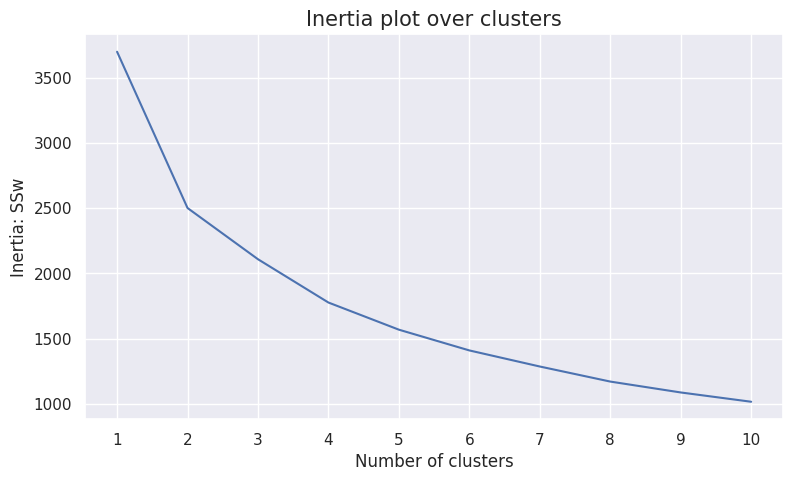

In [ ]:
# Check if the new DF shows similar values in the Elbow Curve
plot_inertia(Segment_1_Data_refined)

We can see that the shape of the Elbow Curve is very similar to before. Also it is visible that the total distance is significantly smaller than before for each of the clusters, which confirms our decision to remove the variable Educ.

As the curve's shape is similar to before, we will use 4 clusters again for the final segmentation.


In [ ]:
# Final cluster solution based on Elbow Graph decision
number_clusters_elb_final = 4
kmclust_elb_final = KMeans(n_clusters=number_clusters_elb_final, init='k-means++', n_init=15, random_state=1)
km_labels_elb_final = kmclust_elb_final.fit_predict(Segment_1_Data_refined)
km_labels_elb_final

array([3, 3, 3, ..., 3, 3, 3], dtype=int32)

In [ ]:
# Creating a new DF based on the k-means results
df_km_labeled_elb_final = pd.concat((Segment_1_Data_refined, pd.Series(km_labels_elb_final, name='km_labels_elb_final', index=Segment_1_Data_refined.index)),
                        axis=1)
df_km_labeled_elb_final

,Freq,Recency,Dayswus,WebVisit,Perdeal,km_labels_elb_final
0,0.622222,0.647059,0.341429,0.4,0.031250,3
1,0.666667,0.058824,0.104286,0.1,0.010417,3
3,0.444444,0.098039,0.490000,0.5,0.125000,3
4,0.533333,0.254902,0.731429,0.6,0.052083,1
5,0.088889,0.637255,0.345714,0.9,1.000000,0
...,...,...,...,...,...,...
9994,0.066667,0.058824,0.678571,0.8,0.687500,2
9995,0.488889,0.705882,0.595714,0.6,0.072917,1
9996,0.711111,0.735294,0.124286,0.5,0.031250,3
9997,0.644444,0.960784,0.051429,0.3,0.020833,3


In [ ]:
# Calling the function to get the mean values
get_mean_bylabel(df_km_labeled_elb_final, 'km_labels_elb_final')

,Freq,Recency,Dayswus,WebVisit,Perdeal
km_labels_elb_final,,,,,
0,0.095765,0.804922,0.485632,0.653230,0.567517
1,0.589512,0.501116,0.768927,0.459720,0.097202
2,0.115013,0.257538,0.504034,0.664215,0.555082
3,0.458578,0.484078,0.246545,0.286730,0.084951


Interpretation of the results:

We can see that the results are almost the same as they were when Educ was still part of the clustering. Therefore we can now definitely say that Educ doesn't influence the clusters in our dataset.

To confirm the reliability of this solution, we ran the same code several times with 3 different seeds than the one we used (random_state = 2, 111, 222). The results were basically the same in all 4 versions, which gives us confidence that our clustering is not volatile and dependent on the random_state = 1 that we chose.

In order to make sense of the clusters, we will now look at the mean values of each of these 5 variables in the entire dataset (after outlier removal), so we understand if the respective mean values of each cluster lie above or below the global mean.



In [ ]:
# Get the global mean of the dataset to facilitate the comparison & interpretation
Segment_1_Data_refined.mean()

,0
Freq,0.306885
Recency,0.511825
Dayswus,0.497077
WebVisit,0.519323
Perdeal,0.333769


In [ ]:
# Looking at the mean value of each variable in each cluster gives us a good overview of our clusters.
# To assess the quality of our clusters, we don't only want to look at the mean values, but also at the distribution of variable.
# Therefore we are creating a function that creates a boxplot for each variable in each cluster.

def cluster_boxplots(df, cluster_label, figsize=(15, 10)):

    # List of variables (excluding cluster label column)
    variables = [col for col in df.columns if col != cluster_label]

    # Unique clusters
    clusters = sorted(df[cluster_label].unique())

    # Create a grid of plots: One graph per cluster
    n_clusters = len(clusters)
    fig, axes = plt.subplots(nrows=1, ncols=n_clusters, figsize=figsize, sharey=True)

    # If only 1 cluster, axes is not a list, so wrap it
    if n_clusters == 1:
        axes = [axes]

    for ax, cluster in zip(axes, clusters):
        # Filter data for the current cluster
        cluster_data = df[df[cluster_label] == cluster]

        # Create a boxplot for all variables
        sns.boxplot(data=cluster_data[variables], ax=ax, palette="Set2")

        # Set titles and labels
        ax.set_title(f"Cluster {cluster}", fontsize=12, fontweight="bold")
        ax.set_xticklabels(variables, rotation=45)
        ax.set_ylabel("Min-max normalization" if cluster == clusters[0] else "")

    # Overall figure adjustments
    plt.suptitle("Boxplots of Variables for Each Cluster", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.show()

<ipython-input-345-177584308f1d>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45)
<ipython-input-345-177584308f1d>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45)
<ipython-input-345-177584308f1d>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45)
<ipython-input-345-177584308f1d>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45)


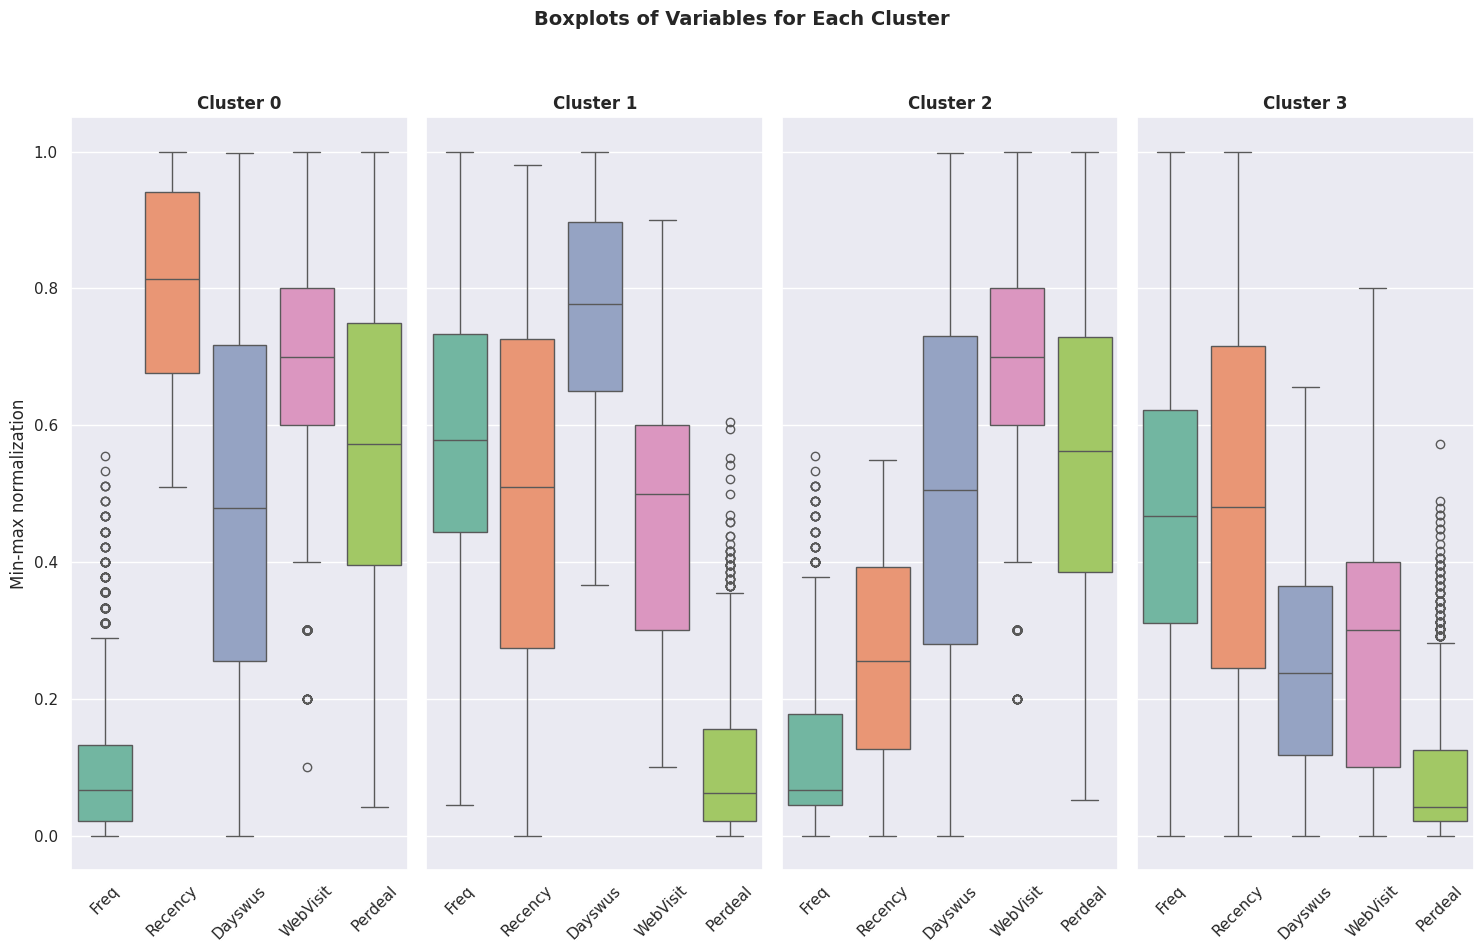

In [ ]:
# Calling the function
cluster_boxplots(df_km_labeled_elb_final, 'km_labels_elb_final')

Interpretation of the results:

We can see quite significant differences between the boxplots. The boxplots that have their mean value closer to one of the extremes tend to have a smaller IQR, which shows that those are the most characterizing variables in their clusters. Boxplots with a mean value close to the global mean tend to have a much higher variance and therefore are not the most defining variables for each cluster.

This result is not really surprising to us, but it confirms the differences between the clusters that were already shown when looking at the mean values of each variable.

In [ ]:
# Defining a function to plot 2 different graphs in order to facilitate the profiling of the clusters

def cluster_profiles(df,
                     label_columns,
                     figsize,
                     compar_titles=None,
                     colors='Set1'):
    if compar_titles is None:
        compar_titles = [""] * len(label_columns)

    fig, axes = plt.subplots(nrows=len(label_columns), ncols=2,
                             figsize=figsize, squeeze=False)
    for ax, label, titl in zip(axes, label_columns, compar_titles):

        # Filtering df
        drop_cols = [i for i in label_columns if i != label]
        dfax = df.drop(drop_cols, axis=1)

        # Getting the cluster centroids and counts
        centroids = dfax.groupby(by=label, as_index=False).mean()
        counts = dfax.groupby(by=label, as_index=False).count().iloc[:, [0, 1]]
        counts.columns = [label, "counts"]

        # Calculate global mean for all features
        global_mean = dfax.drop(columns=label).mean()

        # Setting Data
        pd.plotting.parallel_coordinates(centroids, label,
                                         color=sns.color_palette(palette=colors), ax=ax[0])

        # Add the global mean line as a dashed black line
        ax[0].plot(global_mean.index, global_mean.values,
                   color="black", linestyle="--", linewidth=2, label='Mean')

        # Add a bar plot to show cluster sizes
        sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
                    palette=sns.color_palette(palette=colors))

        # Setting Layout
        handles, _ = ax[0].get_legend_handles_labels()
        cluster_labels = ["Cluster {}".format(i) for i in range(len(handles) - 1)] + ["Global Mean"]
        ax[0].annotate(text=titl, xy=(0.95, 1.1), xycoords='axes fraction', fontsize=13, fontweight='heavy')
        ax[0].legend(handles, cluster_labels)  # Adaptable to number of clusters
        ax[0].set_title("Cluster Means - {} Clusters".format(len(handles) - 1), fontsize=13)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-20)
        ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

        ax[1].set_xticklabels(cluster_labels[:-1])  # Exclude global mean from bar plot labels
        ax[1].set_xlabel("")
        ax[1].set_ylabel("Absolute Frequency")
        ax[1].set_title("Cluster Sizes - {} Clusters".format(len(handles) - 1), fontsize=13)

    plt.subplots_adjust(hspace=0.4, top=0.90)
    plt.show()

<ipython-input-347-1c4ade5e71ad>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:36: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(cluster_labels[:-1])  # Exclude global mean from bar plot labels


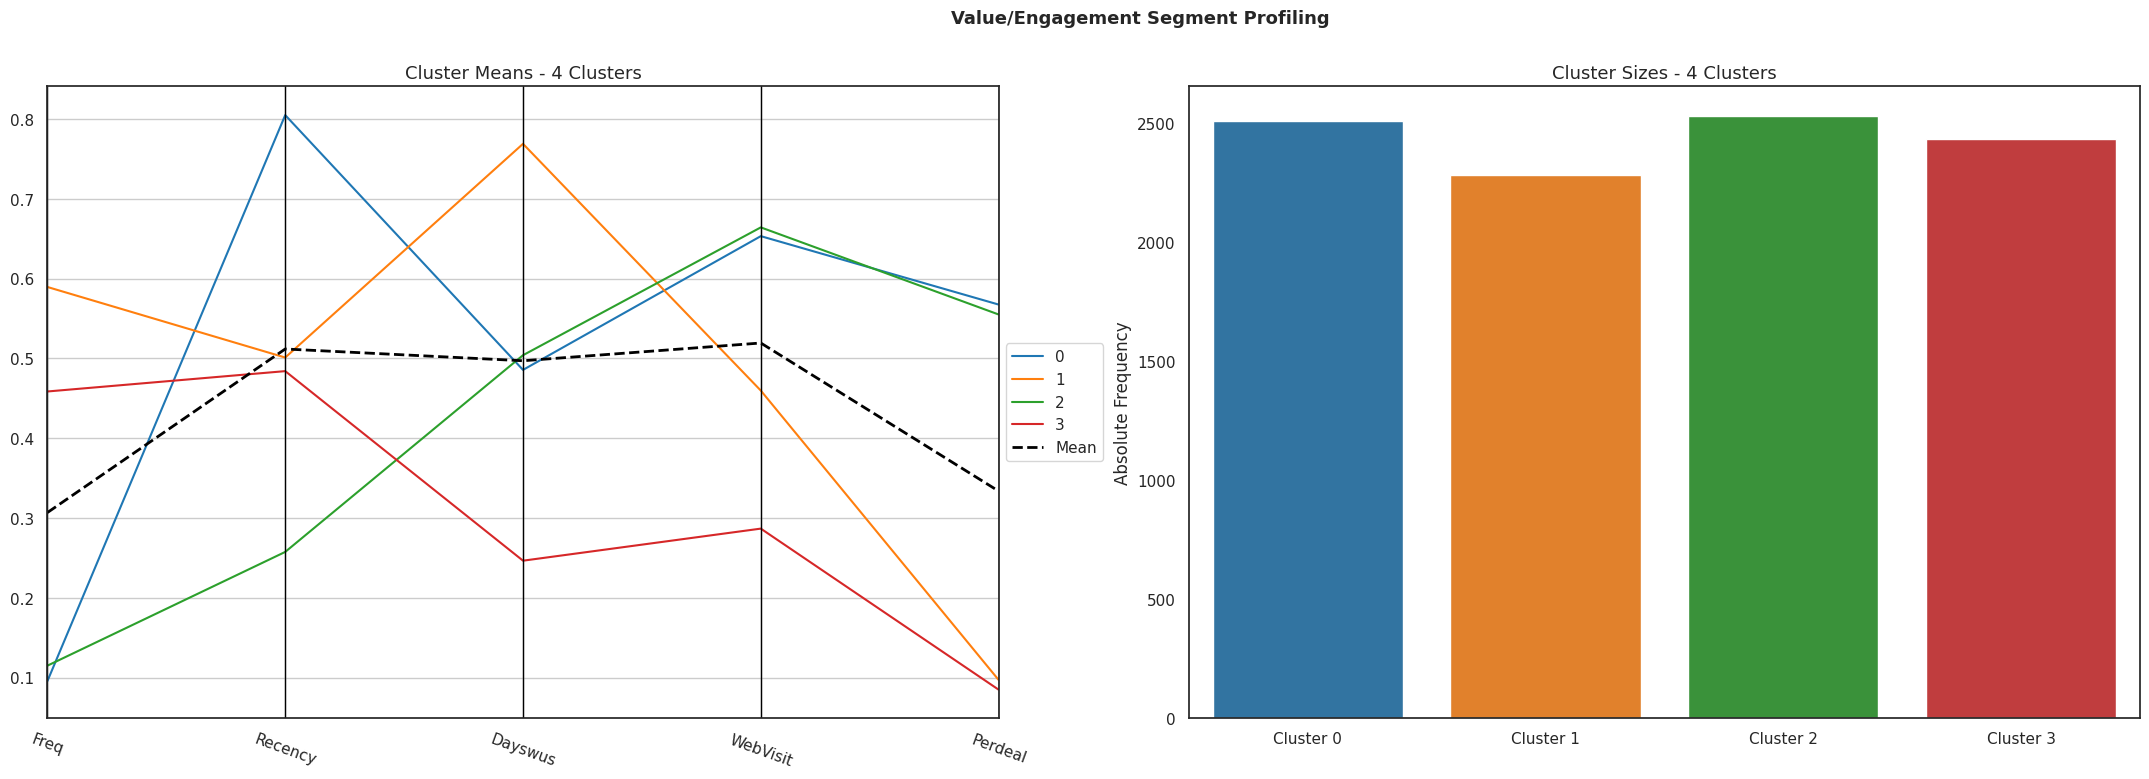

In [ ]:
# Profiling each cluster of our final solution for the value/engagement segmentation & benchmarking it against the global mean of our dataset:
sns.set(style="white")
cluster_profiles(
    df = df_km_labeled_elb_final,
    label_columns = ['km_labels_elb_final'],
    figsize = (27, 8),
    compar_titles = ["Value/Engagement Segment Profiling"],
    colors='tab10'
)

Interpretation of the results:

Now it is possible to draw some first business insights from our clusters:


*   Cluster 0: Includes customers that buy the least frequently, which also means they are on average the youngest, have the lowest income, the lowest Life Time Value and spend the least money on our products (we can derive that due to the high correlation of these variables to Frequency). Those customers haven't made a purchase in a long time and the time they have been our customers is about average. They are a segment that visits our website a lot and therefore also does more web purchases than average. Also, those customers buy very often products that are on offer so we could conclude they are very price sensitive.

*   Cluster 1: Includes customers that buy the most frequently, which also means they are on average the oldest, have the highest income, the highest Life Time Value and spend the most money on our products. While the time that passed since their last purchase (Recency) is about average, those customers have been with WWW for quite some time and their visits our website are a bit less than average and therefore also their amount of web purchases is a bit less than average. Those customers buy very rarely products that are on offer, so we could conclude they are not very price sensitive.

*   Cluster 2: Includes customers that buy less frequently than the average customer, which also means they are on average younger, have a lower income, a lower Life Time Value and spend less money on our products. Those customers made their last purchase more recently than any other cluster and the time they have been with WWW is about average. They are the segment that visits our website the most and therefore also make the most web purchases. Also, those customers buy very often products that are on offer, so we could conclude they are very price sensitive.

*   Cluster 3: Includes customers that buy more frequently than the average customer, which also means they are on average older, have a higher income, a higher Life Time Value and spend more money on our products . While the time that passed since their last purchase (Recency) is about average, those customers are rather new clients at WWW and they are the segment that visits our website the least and therefore also does the least web purchases. Also, those customers buy very rarely products that are on offer, so we could conclude they are not very price sensitive.

Besides understanding the characteristics of each of the clusters, we can also see that the number of customers in each cluster is quite similar, which tells us that all of the 4 clusters represent a relevant amount of customers in our portfolio and are therefore worth to take into consideration.


In [ ]:
# In order to verify/falsify our interpretation based on these 4 variables, we will now assign the clusters to the data points in the original dataset.
# In addition, this will even give us more insights than our first interpretation, as we can also use non-numeric variables and discrete variables with small ranges to make sense of our results.

# Prepare DF used for k-means clustering for a left join. We only want to join the label of the cluster to the original DF
km_cluster_results = df_km_labeled_elb_final[['km_labels_elb_final']]
df_original_clustered = pd.merge(left=df_original, right=km_cluster_results, how='left', left_index=True, right_index=True)

pd.set_option('display.max_columns', None) # We want no column to be hidden in order to analyze every variable
get_mean_bylabel(df_original_clustered, 'km_labels_elb_final')



,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
km_labels_elb_final,,,,,,,,,,,,,,,,,,,,,
0.0,6055.332935,889.942584,35.198565,16.638756,49369.622807,0.727273,0.535486,5.309410,119.856061,144.565391,7.273923,54.481659,49.083333,7.172648,28.744019,7.500000,7.482057,21.702552,54.915470,6.532297,0.110048
1.0,6012.201839,1088.249124,61.554729,16.977671,92110.404116,0.094133,0.446147,27.586690,51.113835,1320.165061,490.276270,9.331436,54.686077,5.849387,28.109457,5.637916,5.697023,9.749124,30.146673,4.597198,0.403678
2.0,5923.401740,902.823646,35.829972,16.616845,50576.181099,0.724792,0.542507,6.175563,26.268881,170.043891,8.892052,53.288256,50.312772,7.216686,27.902333,7.449189,7.087386,21.052590,55.003163,6.642151,0.103994
3.0,6011.736647,722.581348,62.835251,16.980690,93232.445357,0.073952,0.383320,21.636401,49.387839,970.487264,375.792523,8.155300,51.292933,6.491372,29.671323,6.452342,6.066968,9.016434,26.796631,2.867297,0.364010


In [ ]:
df_original_clustered.head()

,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access,km_labels_elb_final
0,1001,789,68,16,90782,0,0,29,66,1402,699,3,37,5,44,10,3,2,19,4,1,3.0
1,1002,623,78,20,113023,0,0,31,6,1537,565,1,55,1,38,4,2,2,9,1,0,3.0
2,1003,583,24,18,28344,1,0,4,69,44,-3,66,32,19,24,1,24,63,59,7,1,NaN
3,1004,893,59,19,93571,0,1,21,10,888,207,12,60,10,19,6,5,15,35,5,0,3.0
4,1005,1062,59,18,91852,0,1,25,26,1138,355,5,59,5,28,4,4,19,34,6,0,1.0


In [ ]:
# Also here we want to see the global mean of each variable for better comparison & interpretation
df_original.mean()


,0
Custid,6000.5000
Dayswus,898.1020
Age,47.9273
Educ,16.7391
Income,69904.3580
Kidhome,0.4188
Teenhome,0.4698
Freq,14.6281
Recency,62.4068
Monetary,622.5552


In [ ]:
# Finally, let's add some colors to the table in order to better recognize the differences in the values

df_original_clustered_colored = get_mean_bylabel(df_original_clustered, 'km_labels_elb_final')

df_original_clustered_colored.style.format(precision=2).background_gradient(axis=0)

,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
km_labels_elb_final,,,,,,,,,,,,,,,,,,,,,
0.000000,6055.33,889.94,35.20,16.64,49369.62,0.73,0.54,5.31,119.86,144.57,7.27,54.48,49.08,7.17,28.74,7.50,7.48,21.70,54.92,6.53,0.11
1.000000,6012.20,1088.25,61.55,16.98,92110.40,0.09,0.45,27.59,51.11,1320.17,490.28,9.33,54.69,5.85,28.11,5.64,5.70,9.75,30.15,4.60,0.40
2.000000,5923.40,902.82,35.83,16.62,50576.18,0.72,0.54,6.18,26.27,170.04,8.89,53.29,50.31,7.22,27.90,7.45,7.09,21.05,55.00,6.64,0.10
3.000000,6011.74,722.58,62.84,16.98,93232.45,0.07,0.38,21.64,49.39,970.49,375.79,8.16,51.29,6.49,29.67,6.45,6.07,9.02,26.80,2.87,0.36


###Conclusion Engagement/Value segments
As we reintroduced the original DF again to our clusters, most of the interpretations made previously by only analyzing the 4 variables used for the final clustering hold true. This confirms the strong correlations between some of the variables in our dataset.
Some slight changes are visible when looking at the age or income variable for example. Linking the clusters back to the original dataset, where no treatment of one-dimensional outliers took place yet, we can see that not Cluster 1 has the highest average age and income, but Cluster 3. Even though those variables have a correlation of 0.83 and 0.87 to Frequency, this correlation was not enough to identify the cluster with the oldest customers and the highest income correctly based on Frequency. Knowing that the difference of those two clusters in the Frequency variable is not extremely high and being aware that there are other variables distinguishing those clusters much more(Dayswus & WebVisit), this insight is not a reason for us to doubt the quality of our clustering.

Besides overall confirming the first interpretation of the clustering results, this table now gives us some more information about variables that were not at all considered for our value/engagement segmentation.



1.   Looking at the categorical variables KidHome and TeenHome, we can recognize that customers in Cluster 0 & 2 are much more likely to have a kid at home than Cluster 1 & 3. Considering the average spending at WWW of these clusters (variable Monetary) this makes total sense, as parents of young kids probably have other more important expenses than a good bottle of wine. Considering also their average income, those clusters really have to evaluate what to spend their money on, as they tend to have lower incomes. For the variable TeenHome the distinguishing factor is much smaller than for KidHome.
2.   When analyzing the wine preferences of our clusters (variables Dryred to Exotic), we can see something very interesting: Besides some noteworthy differences in the variable Exotic, there are no patterns visible in relation to the 4 defined clusters. It seems that no matter how valuable our average customer of each cluster is and how he engages with us (online/offline), the wine preferences are the same on average. To analyze the different buying behavior better will be the focus of our second segmentation.
3. Lastly, when looking at the Access variable, we can see that our 2 clusters that tend to spend more money and buy more frequent also buy more accessories, which is no surprise to us.

It needs to be mentioned that this final analysis of our 4 clusters does not contain the multidimensional outliers, which we removed from our dataset before clustering. Those will only be reintroduced when connecting both of our segmentations in the end (value/engagement segmentation & buying behavior segmentation)



## Segmentation 2: Wine selection

###Initial insights


For Customer Behavior, we chose the 'Wine' Features. We understand that for Behavior Segmentation, it is important to analyze how these features relate to one another. Although the 'non-wine' features can explain consumption in certain ways, we prefer to focus solely on the wine features to observe how different customers purchase various types of wine or combinations of 'baskets’. This also prevents us from having a too high dimensionality in our clustering.

In [ ]:
 #Let's do the same tests for the Second Segmentaton to understand firstly with how many clusters we will work

kmclust.fit(Segment_2_Data)
kmclust.predict(Segment_2_Data)

pd.DataFrame(kmclust.transform(Segment_2_Data))

,0,1,2,3,4,5,6,7,8,9
0,0.641322,0.402720,0.718826,0.562282,1.046230,0.615712,0.360445,0.651725,0.616153,0.168099
1,0.504721,0.185620,0.485834,0.656358,1.191858,0.826968,0.371274,0.792743,0.723077,0.310750
2,0.338230,0.262450,0.367703,0.593954,0.985585,0.727387,0.230339,0.597973,0.643714,0.517081
3,0.251214,0.145307,0.374002,0.519314,1.039191,0.771171,0.263056,0.675725,0.651540,0.404179
4,0.460306,0.425774,0.694799,0.451046,1.135661,0.861434,0.524779,0.786532,0.751487,0.332940
...,...,...,...,...,...,...,...,...,...,...
9750,0.398785,0.173454,0.439627,0.543216,0.980703,0.667748,0.126755,0.609131,0.560456,0.343998
9751,0.439389,0.553819,0.765631,0.288644,0.831657,0.798021,0.476739,0.552873,0.515730,0.487346
9752,0.450929,0.143779,0.335756,0.697722,1.116159,0.807430,0.275717,0.766171,0.667001,0.452396
9753,0.595786,0.422821,0.632495,0.619509,0.890733,0.639261,0.281622,0.718753,0.440533,0.434232


###Elbow curve

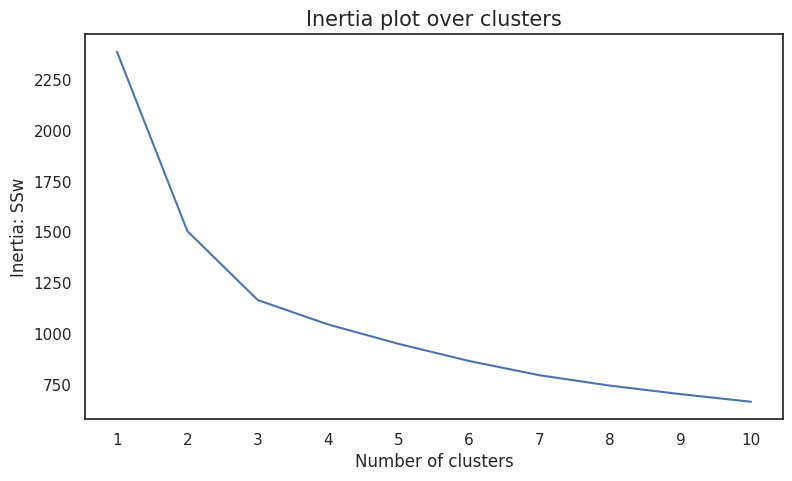

In [ ]:
plot_inertia(Segment_2_Data)

###Silhouette Score

For n_clusters = 2, the average silhouette_score is : 0.34449163976845615
For n_clusters = 3, the average silhouette_score is : 0.3085542941258308
For n_clusters = 4, the average silhouette_score is : 0.2335480827273691
For n_clusters = 5, the average silhouette_score is : 0.23522448620752748
For n_clusters = 6, the average silhouette_score is : 0.2467116343038432
For n_clusters = 7, the average silhouette_score is : 0.24631445136206542
For n_clusters = 8, the average silhouette_score is : 0.2500035462916484
For n_clusters = 9, the average silhouette_score is : 0.24292163202616673
For n_clusters = 10, the average silhouette_score is : 0.2462491761405764


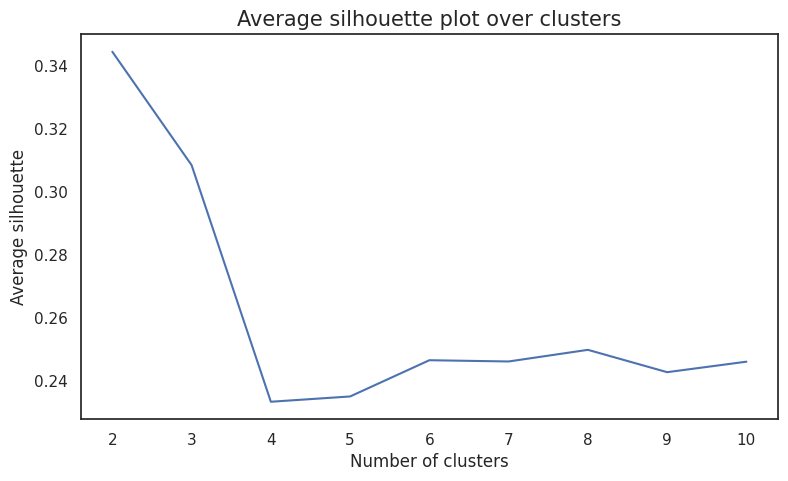

In [ ]:
plot_silhouette_score(Segment_2_Data)

###K-means Clustering

In [ ]:
# Cluster solution based on Elbow Curve decision
number_clusters_elb2 = 4
kmclust_elb2 = KMeans(n_clusters=number_clusters_elb2, init='k-means++', n_init=15, random_state=1)
km_labels_elb2 = kmclust_elb.fit_predict(Segment_2_Data)
km_labels_elb2

array([0, 3, 3, ..., 3, 3, 3], dtype=int32)

In [ ]:
# Creating a new DF based on the k-means results
df_km_labeled_elb2 = pd.concat((Segment_2_Data, pd.Series(km_labels_elb, name='km_labels_elb2', index=Segment_2_Data.index)),
                        axis=1)
df_km_labeled_elb2

,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,km_labels_elb2
0,0.367347,0.125,0.666667,0.285714,0.085714,0.023529,0
1,0.551020,0.025,0.571429,0.114286,0.057143,0.023529,0
3,0.602041,0.250,0.269841,0.171429,0.142857,0.176471,0
4,0.591837,0.125,0.412698,0.114286,0.114286,0.223529,3
5,0.469388,0.050,0.730159,0.057143,0.028571,0.341176,1
...,...,...,...,...,...,...,...
9994,0.530612,0.150,0.412698,0.200000,0.171429,0.105882,2
9995,0.408163,0.275,0.539683,0.028571,0.314286,0.494118,3
9996,0.612245,0.050,0.365079,0.142857,0.171429,0.011765,0
9997,0.459184,0.000,0.428571,0.314286,0.400000,0.047059,0


In [ ]:
get_mean_bylabel(df_km_labeled_elb2, 'km_labels_elb2')

,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic
km_labels_elb2,,,,,,
0,0.516713,0.160678,0.436840,0.181880,0.171092,0.105787
1,0.486163,0.181101,0.426986,0.213509,0.211979,0.257094
2,0.501208,0.179974,0.411936,0.211041,0.201362,0.248717
3,0.550673,0.144762,0.412809,0.158895,0.160890,0.114052


A segmentation of 4 clusters has shown to be too weak to proceed with. We could say that all clusters are too similar between themselves in a way that we even could consider them as a cluster itself.

In [ ]:
# Cluster solution based on Silhouette Score decision
number_clusters_silh2 = 2
kmclust_silh2 = KMeans(n_clusters=number_clusters_silh2, init='k-means++', n_init=15, random_state=1)
km_labels_silh2 = kmclust_silh.fit_predict(Segment_2_Data)
km_labels_silh2

array([0, 1, 1, ..., 1, 0, 1], dtype=int32)

In [ ]:
# Creating a new DF based on the k-means results
df_km_labeled_silh2 = pd.concat((Segment_2_Data, pd.Series(km_labels_silh2, name='km_labels_silh2', index=Segment_2_Data.index)),
                        axis=1)
df_km_labeled_silh2

,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,km_labels_silh2
0,0.367347,0.125,0.666667,0.285714,0.085714,0.023529,0
1,0.551020,0.025,0.571429,0.114286,0.057143,0.023529,1
3,0.602041,0.250,0.269841,0.171429,0.142857,0.176471,1
4,0.591837,0.125,0.412698,0.114286,0.114286,0.223529,1
5,0.469388,0.050,0.730159,0.057143,0.028571,0.341176,1
...,...,...,...,...,...,...,...
9994,0.530612,0.150,0.412698,0.200000,0.171429,0.105882,1
9995,0.408163,0.275,0.539683,0.028571,0.314286,0.494118,0
9996,0.612245,0.050,0.365079,0.142857,0.171429,0.011765,1
9997,0.459184,0.000,0.428571,0.314286,0.400000,0.047059,0


In [ ]:
# Calling the function to get the mean values
get_mean_bylabel(df_km_labeled_silh2, 'km_labels_silh2')

,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic
km_labels_silh2,,,,,,
0,0.297128,0.278926,0.538949,0.326166,0.314221,0.243444
1,0.689770,0.075480,0.326618,0.082144,0.082575,0.133704


Interpretation of results: This cluster solution has shown much more interesting.

Custer 1 seems to have a bigger preference to Dryred, while occasionally favoring Dry White wines. And clearly having less interest for sweeter wines or for the exotic ones.

Cluster 0, on the other hand, demonstrates a more balanced taste. Although they tend to prefer Dry White wines, they purchase sweeter wines (including Dessert) more frequently than customers in Cluster 1 and are more likely to experiment with Exotic wines

In [ ]:
# So far, clustering with k=2 has proven to be much more interesting as said before. Either way, we may want to try to segment it in 3, as we coincidentally for Customer Behaviour

number_clusters_3wh = 3
kmclust_3wh = KMeans(n_clusters=number_clusters_3wh, init='k-means++', n_init=15, random_state=1)
km_labels_3wh = kmclust_3wh.fit_predict(Segment_2_Data)
km_labels_3wh

df_km_labeled_3wh = pd.concat((Segment_2_Data, pd.Series(km_labels_3wh, name='km_labels_3wh', index=Segment_2_Data.index)),
                        axis=1)

get_mean_bylabel(df_km_labeled_3wh, 'km_labels_3wh')

,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic
km_labels_3wh,,,,,,
0,0.745417,0.061864,0.263549,0.069943,0.067695,0.136150
1,0.414073,0.171004,0.577591,0.186354,0.190089,0.156731
2,0.200709,0.407862,0.421594,0.496214,0.462588,0.359058


Interpretation of Results:

By having 3 clusters we had again more interesting results.

We now have a clear new distinct Cluster 2. This cluster has a distinct taste for sweeter wines than 0 and 1. It's composed of customers that are more likely to try different type of wines (higher Exotic mean). On the other hand, this cluster is less likely to buy Dry Red Wines than other Clusters, but they are located between 0 and 1 when it comes to Dry White Wine Consumption.

Cluster 0 can be interpreted as less bold in terms of purchase - they prefer Dry Red Wine more than 1 and 2, and besides, Dryred they would go for Dry White Wine. They are sometimes open for sweet wines, but it is a minority of the cluster or a rare behaviour among them.

In the end, Cluster 1 - although closer to Cluster 0 - seems to be the most balanced group. They normally buy 3x more sweet wines than Cluster 0, but always less than half when compared with Cluster 2. They are more likely to buy Dryred than cluster 2 (2x) but much less than Cluster 0. When it comes to Dry White Wine consumption, they are the 'winners', being the top purchasers of this type. Finally, they are close to Cluster 0 when comparing Exotic wines.


In conclusion, by clustering into 3 different segments, we aimed our goal of identifying a suitable number of clusters that are far distinct between themselves, exhibiting different behaviours in terms of wine purchases.

In [ ]:
# Get the global mean of the dataset to facilitate the comparison & interpretation
Segment_2_Data.mean()

,0
Dryred,0.512910
Sweetred,0.167119
Drywh,0.422260
Sweetwh,0.192060
Dessert,0.186917
Exotic,0.183135


Before looking into the bloxpots it seems that Cluster 1 can be considered our

"Average" Customer,  having the closest values to the dataframe average (more clear in sweet wines, dessert and exotic). However let's seem if visually this analysis is confirmed.

<ipython-input-345-177584308f1d>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45)
<ipython-input-345-177584308f1d>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45)
<ipython-input-345-177584308f1d>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45)


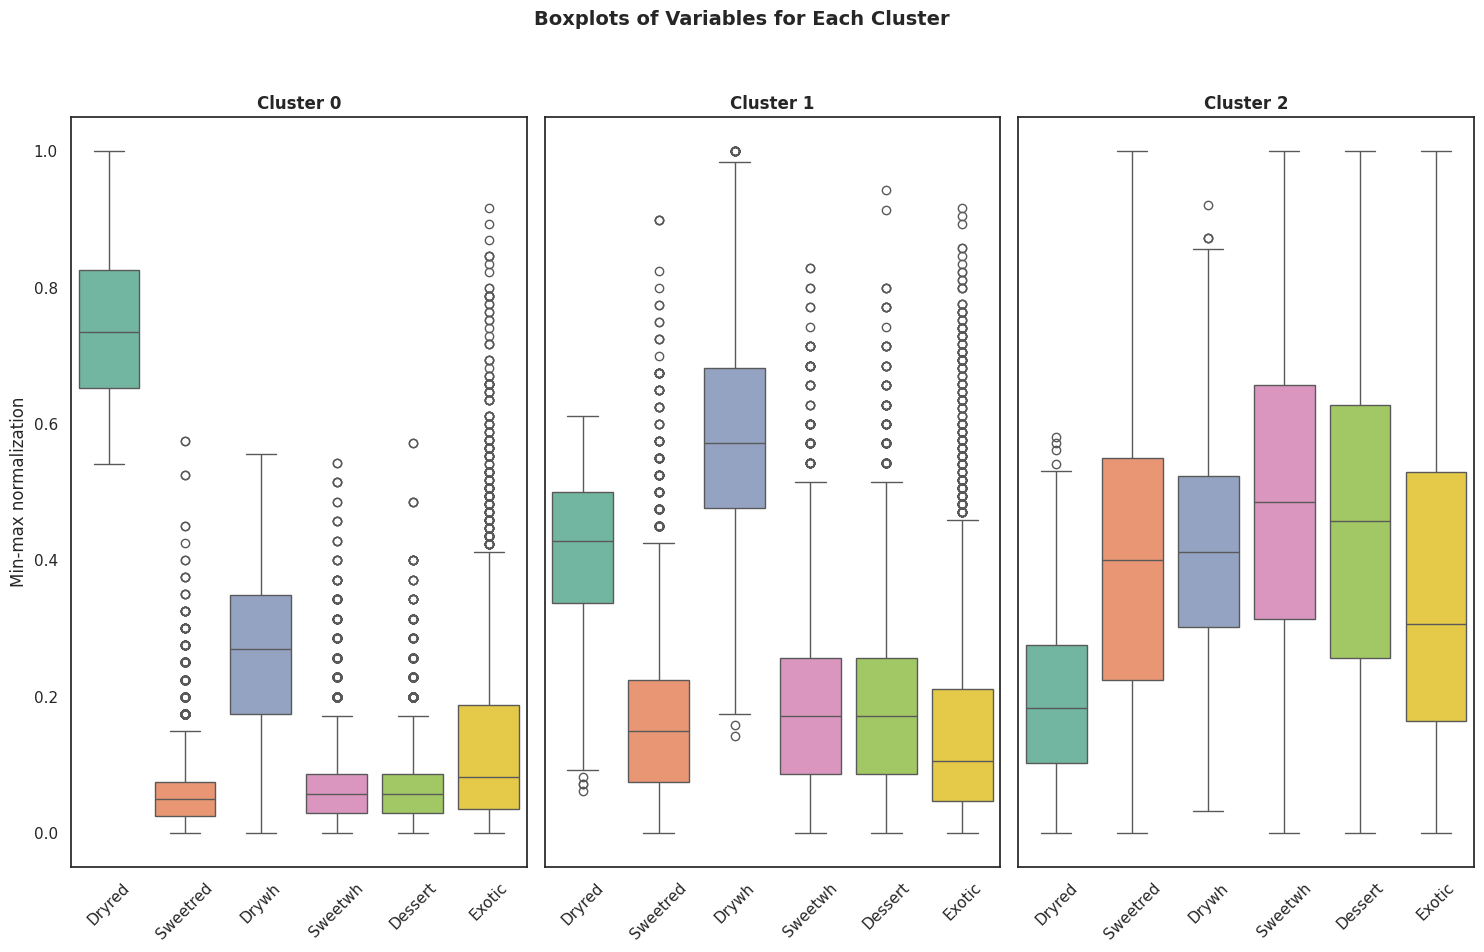

In [ ]:
# Calling the function
cluster_boxplots(df_km_labeled_3wh, 'km_labels_3wh')

Interpretation of results:

The boxplots confirm our initial analysis. The clusters not only have distinct averages for each type of wine, but their IQR is, in some cases, intangibles, showing even clearly the distinction between each cluster.

Regarding the boxplot themselves, Cluster 0 and 1 show many values above the Upper Whisker in Sweet, Dessert and Exotic wines. It can be understood as those clusters to have a higher preference for dry wines, and this preference as having more weight on the clustering than their preference for the sweeter ones.


<ipython-input-347-1c4ade5e71ad>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:36: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(cluster_labels[:-1])  # Exclude global mean from bar plot labels


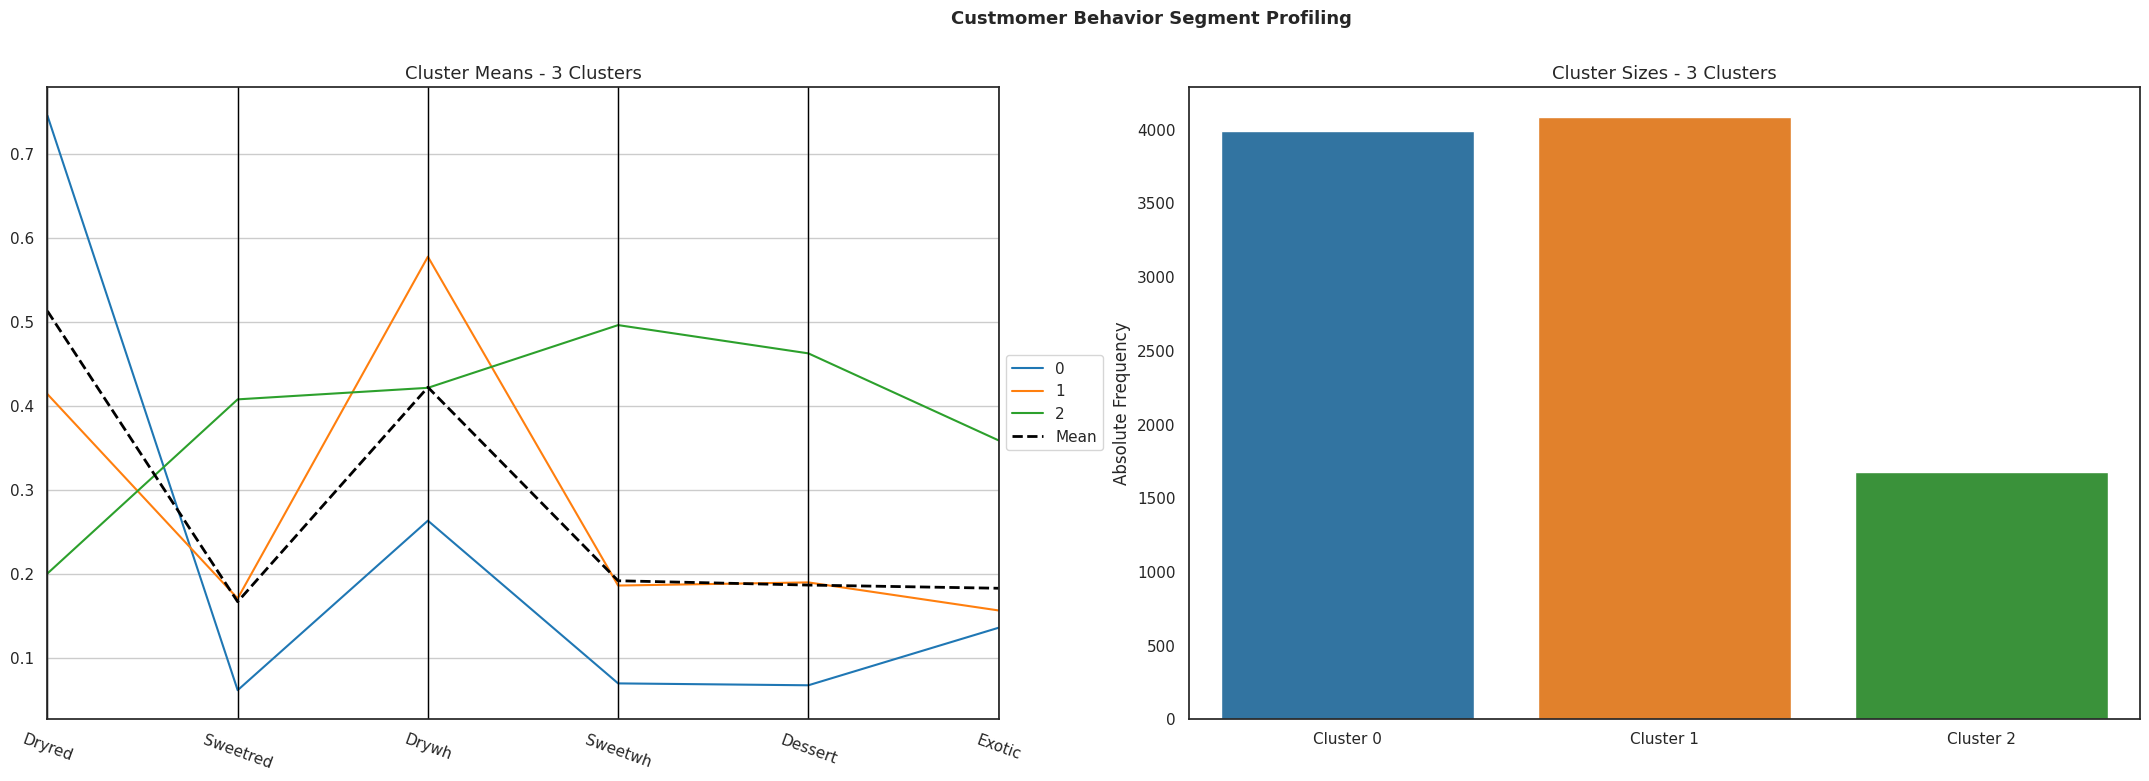

In [ ]:
# Profiling each cluster of our final solution for the value/engagement segmentation & benchmarking it against the global mean of our dataset:
sns.set(style="white")
cluster_profiles(
    df = df_km_labeled_3wh,
    label_columns = ['km_labels_3wh'],
    figsize = (27, 8),
    compar_titles = ["Custmomer Behavior Segment Profiling"],
    colors='tab10'
)

Interpretation of results:

Some of our previous conclusions are now clear. Cluster 1 is the one who is closer to mean. It only fails when looking at Dry White Wine. As we can conclude that they are the most balanced among the 3 clusters.

Cluster 0, as we have seen before, shows a stronger preference for Dry Red Wine, than Dry White Wine and abovebelow average when looking for other types and exotics.

Cluster 2 is above the average when looking for preference for Sweet, Dessert and Exotic wines. And it is close to the average for Dry White Wines.

Cluster 1 and 0 have a similar number of individuals, and Cluster 2 is less than half the size. This result is also expected since Sweet and Dessert Wines are the least preferred among all the individuals. And Exotic wines also have a low average percentage in the initial data frame. So, if we have a cluster that normally prefers those types of wines more than the dry ones - or at least more than the average - this cluster should be significantly smaller than the others.

In [ ]:
# In order to verify/falsify our interpretation based on these 3 variables, we will now assign the clusters to the data points in the original dataset.
# In addition, this will even give us more insights than our first interpretation, as we can also use non-numeric variables and discrete variables with small ranges to make sense of our results.

# Prepare DF used for k-means clustering for a left join. We only want to join the label of the cluster to the original DF
km_cluster_results_wh = df_km_labeled_3wh[['km_labels_3wh']]
df_original_clustered_2 = pd.merge(left=df_original, right=km_cluster_results_wh, how='left', left_index=True, right_index=True)

pd.set_option('display.max_columns', None) # We want no column to be hidden in order to analyze every variable
get_mean_bylabel(df_original_clustered_2, 'km_labels_3wh')

,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
km_labels_3wh,,,,,,,,,,,,,,,,,,,,,
0.0,5996.438236,900.833375,50.459785,17.539714,73575.074417,0.369080,0.734653,14.767978,57.638436,609.424706,180.706590,31.868955,74.050864,2.474568,18.603358,2.448008,2.369331,11.572789,44.910549,5.668254,0.338261
1.0,6003.886414,897.010037,51.845777,16.791187,75725.160832,0.405875,0.335618,17.303794,61.656059,777.326561,287.096940,27.956181,41.579192,6.840147,38.403427,6.522399,6.653121,13.322154,37.136108,4.572093,0.223501
2.0,5999.900536,893.406194,35.288267,15.050030,51255.930316,0.548541,0.216796,8.921977,72.714116,334.985706,107.927338,42.393687,20.669446,16.427635,28.560453,17.758785,16.577725,30.540203,47.629541,5.575342,0.050030


In [ ]:
# Let's look again to the global mean of each variable for better comparison & interpretation
df_original.mean()

,0
Custid,6000.5000
Dayswus,898.1020
Age,47.9273
Educ,16.7391
Income,69904.3580
Kidhome,0.4188
Teenhome,0.4698
Freq,14.6281
Recency,62.4068
Monetary,622.5552


In [ ]:
# Finally, let's add some colors to the table in order to better recognize the differences in the values

df_original_clustered_2_colored = get_mean_bylabel(df_original_clustered_2, 'km_labels_3wh')

df_original_clustered_2_colored.style.format(precision=2).background_gradient(axis=0)

,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
km_labels_3wh,,,,,,,,,,,,,,,,,,,,,
0.000000,5996.44,900.83,50.46,17.54,73575.07,0.37,0.73,14.77,57.64,609.42,180.71,31.87,74.05,2.47,18.60,2.45,2.37,11.57,44.91,5.67,0.34
1.000000,6003.89,897.01,51.85,16.79,75725.16,0.41,0.34,17.30,61.66,777.33,287.10,27.96,41.58,6.84,38.40,6.52,6.65,13.32,37.14,4.57,0.22
2.000000,5999.90,893.41,35.29,15.05,51255.93,0.55,0.22,8.92,72.71,334.99,107.93,42.39,20.67,16.43,28.56,17.76,16.58,30.54,47.63,5.58,0.05


###Conclusion Wine selection segments

As a result of reintroducing the original data frame, our previous conclusions remain valid and consistent, and our clusters also are well segmented across the non-chosen features. Let us compare cluster by cluster, in detail:

•	Firstly, please note that the average percentage for each wine feature by cluster represents the average percentage of individuals within the cluster among other wine types and not among other clusters. And it does not represent the average of the cluster spending (monetary). Different individuals within the cluster have different spending behaviours, but we are averaging individuals equally, independent of other features.

•	Cluster 0: As previously noticed in different analysis, those are the ones with higher preference for **Dry Red Wine** (74(.05% on average vs. 50.38% for the entire data frame), combining with **White Dry Wine**, these categories make up 93%. This cluster has a clear preference, and it seems to reject or rarely include **sweet** or **dessert** wines in their purchases (approx. 7%). They occasionally buy **Exotic** wines (11.57%), but less frequently than the overall average (16.54%).

•	Cluster 1: Again, this cluster is the most balanced when comparing with the entire data frame. **Sweet/Dessert** wines represent each a bit more than 6.5% of their consumption, totalling an average of 20% of their wines purchases. On the other hand, they tend to prefer more **White Dry Wine** than the average (38.4% vs 28.52%), but less **Red Dry wine** than the (41.58% vs. 50.38%). Interestingly having the same 'balance' as the entire data frame, when comparing the consumption of **dry** vs. **sweeter wines** (80%/20%). It shows similar behaviour to Cluster 0 for **Exotic** wines.

•	Cluster 2: With the non-normalized data, we see that this cluster has an equal balance between **Dry** and non-dry wines (49.23% vs. 50.77%). Even being the ones who purchase the most non-dry wines, it still represents only half of the wines purchased. They prefer **Dry White** over** Dry Red** but seems to have equal preference when comparing **Sweet White**, **Sweet** **Red** and **Dessert** Wines (around 17%). As also stated before, they are the most enthusiastic of **exotic** whines among all clusters (30.54%).


**Conclusions among ‘Non-wine features’**

Now looking at non-wine features, what are our conclusions? At first glance, Clusters 0 and 1 are more similar and share several characteristics, and Cluster 2 being the outlier of this comparison. However, it also has some exceptions. Let us break it down:

•	**Daywus** seem to have little to no impact on the type of wine purchased by cluster. Educ, as well, does not show any major difference between clusters to be considered.

•	When examining **Age**, they are remarkably similar between 1 and 0, and Cluster 2 being at least 15 years younger on average than both.

•	When looking for finance features. Cluster 1 and 0 both have similar **Income**, earning almost 50% more than Cluster 20. It is also reflected in their **Monetary** average spending, being the Cluster 1 the most spender ($777), followed by Cluster 0, which spends 14% less, and Cluster 2 spending less than half of Cluster 10's amount. When looking at **LTV** and **Frequency**, it follows as expected (since they are highly correlated) the same order.

•	The relationship between these features among all clusters explains or may be explained by the **Perdeal**. Cluster 02 is the least wealthy, which results in lower spending and consequently generating less value to the company. Although 0 and 1 have similar incomes, Cluster 0 also actively seeks for more promotions than 1, that is why their **Monetary** and **LTV** are significantly lower. Not coincidentally, 0 or 2 visits and make more purchases via the **Website**, which could also correlate with **Perdeal** - it is easier to monitor promotions when purchasing online.

•	There are still some features to be analysed, although we do not believe that they have a major influence on their wine consumption. Cluster 0 is more likely to have a child teen at home (0.73), while cluster 2 figures the highest value for **Kidhome** (0.53). In terms of accessories, any cluster presents a strong inclination to purchase much more than the average, but Cluster 0 again, as in **Teenhome**, stands out at the top (0.34).


#Connecting Segment 1 & 2

## Contingency table analysis


The next step consists of connecting our two segmentations and define our final clustering. We create a x*y matrix, where x is the number of clusters in the first segmentation and y the number of clusters of the second segmentation.

In [ ]:
perspective_1 = 'km_cluster_results'
perspective_2 = 'km_cluster_results_wh'
df_copy2[perspective_1] = km_cluster_results
df_copy2[perspective_2] = km_cluster_results_wh

def make_contingency_table(df, label1, label2):
    # Group by the two labels and count occurrences
    df_ = (
        df.groupby([label1, label2])
        .size()
        .to_frame(name='count')  # Convert size result to a DataFrame
        .reset_index()
        .pivot(index=label2, columns=label1, values='count')  # Pivot to create contingency table
    )

    return df_




In [ ]:
df_2 = make_contingency_table(df_copy2, perspective_1, perspective_2)
df_2

km_cluster_results,0,1,2,3
km_cluster_results_wh,,,,
0,996,1036,1052,907
1,894,1044,888,1259
2,618,204,589,268


Merging the two segmentations we obtain 4*3=12 clusters, all with statistically significant representation (ranging from 204 observations to 1259).


##Hierarchical clustering

We decide to reduce the number of clusters by applying hierarchical clustering. The next function calculates the centroids of our merged clusters, to be able to classify and them by distance.

In [ ]:
# Centroids of the concatenated cluster labels
metric_features = ['Dayswus','Educ','Income','Freq','Recency','LTV','Perdeal','WebVisit','Access','Dryred','Sweetred','Drywh','Sweetwh','Dessert','Exotic']
df_hc_centroids = df_copy2.groupby([perspective_1, perspective_2])[metric_features].mean()
df_hc_centroids

Dayswus      Educ    Income  \
km_cluster_results km_cluster_results_wh                                 
0                  0                      0.473881  0.686998  0.384877   
                   1                      0.498100  0.604446  0.282448   
                   2                      0.486535  0.371561  0.194229   
1                  0                      0.764633  0.681467  0.592483   
                   1                      0.770463  0.605364  0.666834   
                   2                      0.782878  0.407475  0.616151   
2                  0                      0.501688  0.687975  0.383450   
                   1                      0.507931  0.581503  0.297407   
                   2                      0.502348  0.372453  0.200477   
3                  0                      0.229691  0.716235  0.597390   
                   1                      0.257621  0.601867  0.669243   
                   2                      0.251551  0.402985  0.621140   

                                              Freq   Recency       LTV  \
km_cluster_results km_cluster_results_wh                                 
0                  0                      0.137818  0.799384  0.140239   
                   1                      0.077231  0.807069  0.131223   
                   2                      0.054800  0.810743  0.129794   
1                  0                      0.540841  0.502848  0.423466   
                   1                      0.646360  0.502996  0.547203   
                   2                      0.545752  0.482699  0.452574   
2                  0                      0.153654  0.251482  0.141861   
                   1                      0.100000  0.264871  0.131766   
                   2                      0.068629  0.257299  0.130307   
3                  0                      0.397770  0.479409  0.341123   
                   1                      0.512664  0.483741  0.452103   
                   2                      0.410282  0.501463  0.369132   

                                           Perdeal  WebVisit    Access  \
km_cluster_results km_cluster_results_wh                                 
0                  0                      0.540234  0.634639  0.169679   
                   1                      0.585850  0.668345  0.085011   
                   2                      0.584968  0.661327  0.037217   
1                  0                      0.128831  0.573456  0.377413   
                   1                      0.067419  0.363697  0.269157   
                   2                      0.089001  0.373529  0.107843   
2                  0                      0.522477  0.656844  0.156844   
                   1                      0.578582  0.674212  0.082207   
                   2                      0.577886  0.662309  0.020374   
3                  0                      0.114331  0.380375  0.363837   
                   1                      0.064875  0.231771  0.250199   
                   2                      0.079835  0.227985  0.082090   

                                            Dryred  Sweetred     Drywh  \
km_cluster_results km_cluster_results_wh                                 
0                  0                      0.749939  0.056777  0.267148   
                   1                      0.415856  0.161801  0.592681   
                   2                      0.180949  0.400324  0.434196   
1                  0                      0.739441  0.070125  0.258657   
                   1                      0.413402  0.174617  0.570334   
                   2                      0.262555  0.387500  0.407407   
2                  0                      0.758943  0.050238  0.260456   
                   1                      0.417460  0.165907  0.583405   
                   2                      0.175652  0.429160  0.419975   
3                  0                      0.731589  0.071499  0.268774   
                   1                      0.

In [ ]:
# Using Hierarchical clustering to merge the concatenated cluster centroids
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_hc_centroids)

In [ ]:
# Defining the function for the dendogram created by hierarchical clustering

def plot_dendrogram(df, feats,
                    linkage='ward', distance='euclidean',
                    y_threshold = 75):

  # setting distance_threshold=0 and n_clusters=None ensures we compute the full tree
  hclust = AgglomerativeClustering(linkage=linkage,
                                  metric=distance,
                                  distance_threshold=0,
                                  n_clusters=None)

  hclust.fit_predict(df[feats])

  # create the counts of samples under each node (number of points being merged)
  counts = np.zeros(hclust.children_.shape[0])
  n_samples = len(hclust.labels_)

  # hclust.children_ contains the observation ids that are being merged together
  # At the i-th iteration, children[i][0] and children[i][1] are merged to form node n_samples + i
  for i, merge in enumerate(hclust.children_):
      # track the number of observations in the current cluster being formed
      current_count = 0
      for child_idx in merge:
          if child_idx < n_samples:
              # If this is True, then we are merging an observation
              current_count += 1  # leaf node
          else:
              # Otherwise, we are merging a previously formed cluster
              current_count += counts[child_idx - n_samples]
      counts[i] = current_count

  ## Create linkage matrix

  # the hclust.children_ is used to indicate the two points/clusters being merged (dendrogram's u-joins)
  # the hclust.distances_ indicates the distance between the two points/clusters (height of the u-joins)
  # the counts indicate the number of points being merged (dendrogram's x-axis)
  linkage_matrix = np.column_stack(
      [hclust.children_, hclust.distances_, counts]
  ).astype(float)


  # Plot the corresponding dendrogram

  sns.set()
  fig = plt.figure(figsize=(11,5))

  # The Dendrogram parameters need to be tuned
  # "dendrogram" function will plot our dendrogram
  dendrogram(linkage_matrix,
            truncate_mode='level',
            p=5,
            color_threshold=y_threshold,
            above_threshold_color='k')



  plt.hlines(y_threshold, 0, 1000, colors="r", linestyles="dashed")
  plt.title(f'Hierarchical Clustering - {linkage.title()}\'s Dendrogram', fontsize=21)
  plt.xlabel('Number of points in node (or index of point if no parenthesis)')
  plt.ylabel(f'{distance.title()} Distance', fontsize=13)
  plt.show()


The hierarchical cluster below would suggest that the ideal number of cluster could be 2, 4 or 6. For our business case, 2 clusters would provide too little information, whereas 6 might over-complicate our segmentation. We set the cut at 4 clusters, with the option to go back and set to 6 if the segmentation does not look satisfactory.

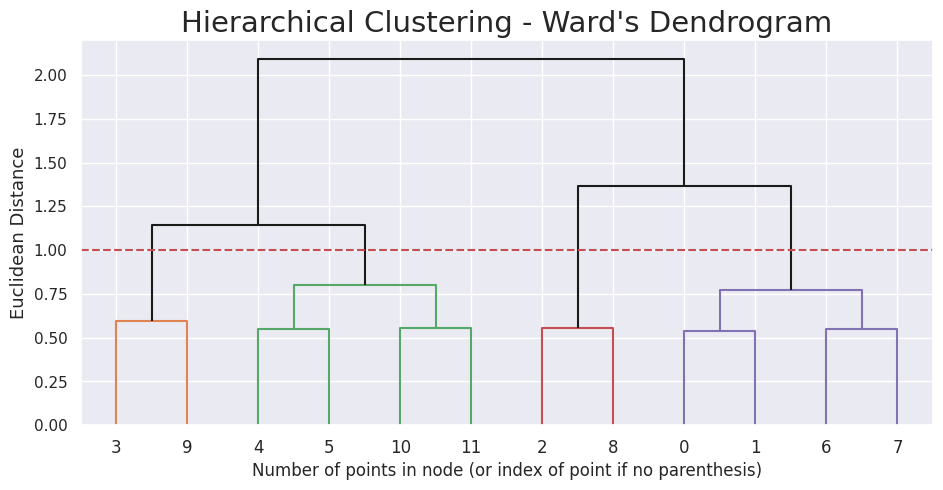

In [ ]:
# set y_threshold to a lower value to visualize where we want the dendrogram to cut
plot_dendrogram(df_hc_centroids, metric_features, y_threshold=1)

In [ ]:
df_hc_centroids[[]].reset_index()

,km_cluster_results,km_cluster_results_wh
0,0,0
1,0,1
2,0,2
3,1,0
4,1,1
5,1,2
6,2,0
7,2,1
8,2,2
9,3,0


In [ ]:
## Map combinations of the two labels to their merged cluster label

def hc_merge_mapper(df, label1, label2, feats, merged_label, n_clusters=1):
  """
  merged_label  : what to call the column that should contain the merged label
  n_clusters    : how many clusters to keep
  """
  df_ = df.copy()

  # Centroids of the concatenated cluster labels
  df_hc_centroids = df_.groupby([label1, label2])[feats].mean()

  # Re-running the Hierarchical clustering based on the correct number of clusters
  hclust = AgglomerativeClustering(
      linkage='ward',
      metric='euclidean',
      n_clusters=n_clusters
  )
  hclust_labels = hclust.fit_predict(df_hc_centroids)
  df_hc_centroids[merged_label] = hclust_labels

  cluster_mapper = df_hc_centroids[merged_label].to_dict()

  # Mapping the clusters on the centroids to the observations
  df_[merged_label] = df_.apply(
      lambda row: cluster_mapper[
          (row[label1], row[label2])
      ], axis=1
  )

  return df_, df_hc_centroids

The next line of code is crucial, because this is where we define that we cut the hierarchical clustering to 4.

In [ ]:
df_hc_merged, df_hc_centroids = hc_merge_mapper(df_copy2, perspective_1, perspective_2, metric_features, 'hc_merged_labels', 4)

In [ ]:
df_hc_merged.head(5)

,Dayswus,Educ,Income,Kidhome,Teenhome,Freq,Recency,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebVisit,Access,Minor_home,km_cluster_results,km_cluster_results_wh,hc_merged_labels
0,0.341429,0.500,0.618413,0,0,0.622222,0.647059,0.636430,0.031250,0.367347,0.125,0.666667,0.285714,0.085714,0.023529,0.4,1.0,0,3,1,0
1,0.104286,1.000,0.788675,0,0,0.666667,0.058824,0.539187,0.010417,0.551020,0.025,0.571429,0.114286,0.057143,0.023529,0.1,0.0,0,3,1,0
3,0.490000,0.875,0.639763,0,1,0.444444,0.098039,0.279390,0.125000,0.602041,0.250,0.269841,0.171429,0.142857,0.176471,0.5,0.0,1,3,0,3
4,0.731429,0.750,0.626604,0,1,0.533333,0.254902,0.386792,0.052083,0.591837,0.125,0.412698,0.114286,0.114286,0.223529,0.6,0.0,1,1,0,3
5,0.345714,1.000,0.094819,1,1,0.088889,0.637255,0.116110,1.000000,0.469388,0.050,0.730159,0.057143,0.028571,0.341176,0.9,1.0,1,0,1,1


We now re-classify the original 12 clusters into 4 clusters only. The last column follows the merging visualized in the hierarchical clustering dendrogram.

In [ ]:
## Reclassifying

df_hc_centroids[['hc_merged_labels']].reset_index()

,km_cluster_results,km_cluster_results_wh,hc_merged_labels
0,0,0,1
1,0,1,1
2,0,2,2
3,1,0,3
4,1,1,0
5,1,2,0
6,2,0,1
7,2,1,1
8,2,2,2
9,3,0,3


In [ ]:
df_hc_merged['hc_merged_labels'].value_counts()

,count
hc_merged_labels,
1,3830
0,2775
3,1943
2,1207


In [ ]:
df_hc_merged.head(3)

,Dayswus,Educ,Income,Kidhome,Teenhome,Freq,Recency,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebVisit,Access,Minor_home,km_cluster_results,km_cluster_results_wh,hc_merged_labels
0,0.341429,0.500,0.618413,0,0,0.622222,0.647059,0.636430,0.031250,0.367347,0.125,0.666667,0.285714,0.085714,0.023529,0.4,1.0,0,3,1,0
1,0.104286,1.000,0.788675,0,0,0.666667,0.058824,0.539187,0.010417,0.551020,0.025,0.571429,0.114286,0.057143,0.023529,0.1,0.0,0,3,1,0
3,0.490000,0.875,0.639763,0,1,0.444444,0.098039,0.279390,0.125000,0.602041,0.250,0.269841,0.171429,0.142857,0.176471,0.5,0.0,1,3,0,3


The clusters are pretty different in size, with the biggest recording more than 3 times as many observations as the smallest one. This is not bad per se, but we will have to take the different sizes into consideration when describing the importance of each clusters for our business.

In [ ]:
## Get final DF
df = df_hc_merged.copy()

##Cluster analysis

Let's now visualize with colors and diagrams our final clustering solution.

In [ ]:
merged_label_name = 'hc_merged_labels'

In [ ]:
labels_list = [perspective_2, perspective_1, merged_label_name]

<ipython-input-347-1c4ade5e71ad>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:36: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(cluster_labels[:-1])  # Exclude global mean from bar plot labels


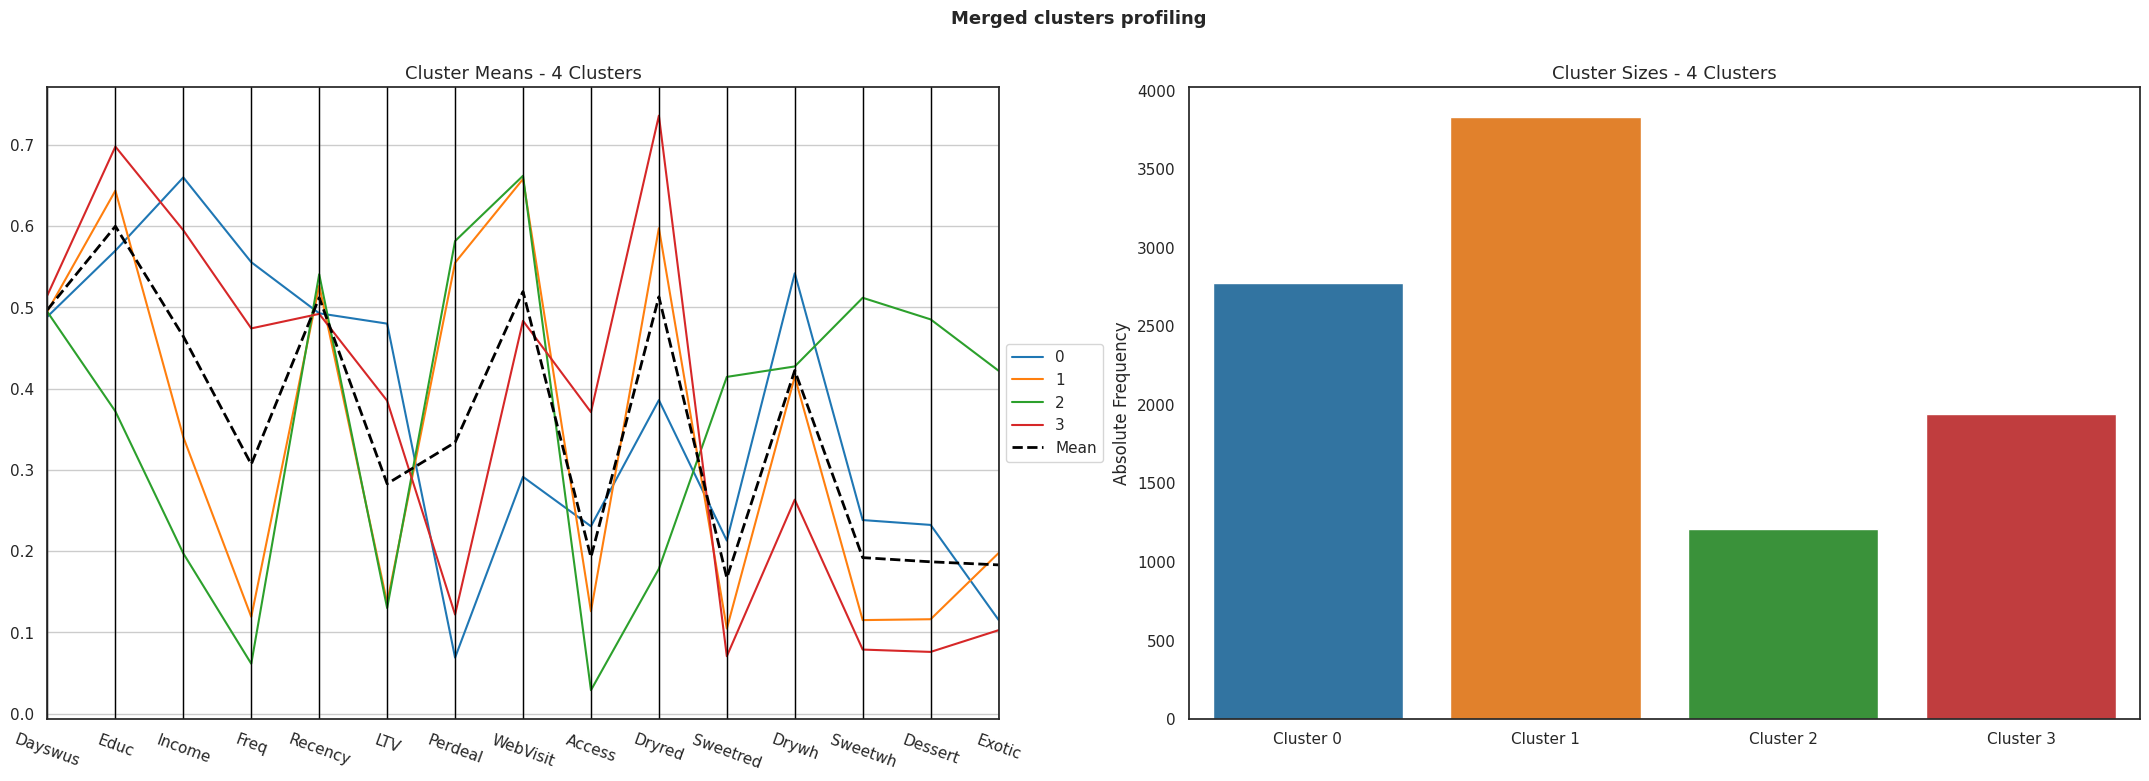

In [ ]:
# Profiling each cluster (only merged)
merged_label_list = [merged_label_name]
sns.set(style="white")
cluster_profiles(
    df = df[metric_features + merged_label_list],
    label_columns = merged_label_list,
    figsize = (27, 8),
    compar_titles = ["Merged clusters profiling"],
    colors='tab10'
)

The line chart shows some overlapping between clusters in certain variables, but no cluster is too similar to the others. There are always variables that clearly differentiate between clusters, in either Wines-related and Engagement-related variables.
We also notice that Recency and Dayswus are not relevant to any segmentation, but will leave it visible and mention it later in the conclusions.

<ipython-input-347-1c4ade5e71ad>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:36: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-347-1c4ade5e71ad>:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(cluster_labels[:-1])  # Exclude global mean from bar plot labels
<ipython-input-347-1c4ade5e71ad>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<

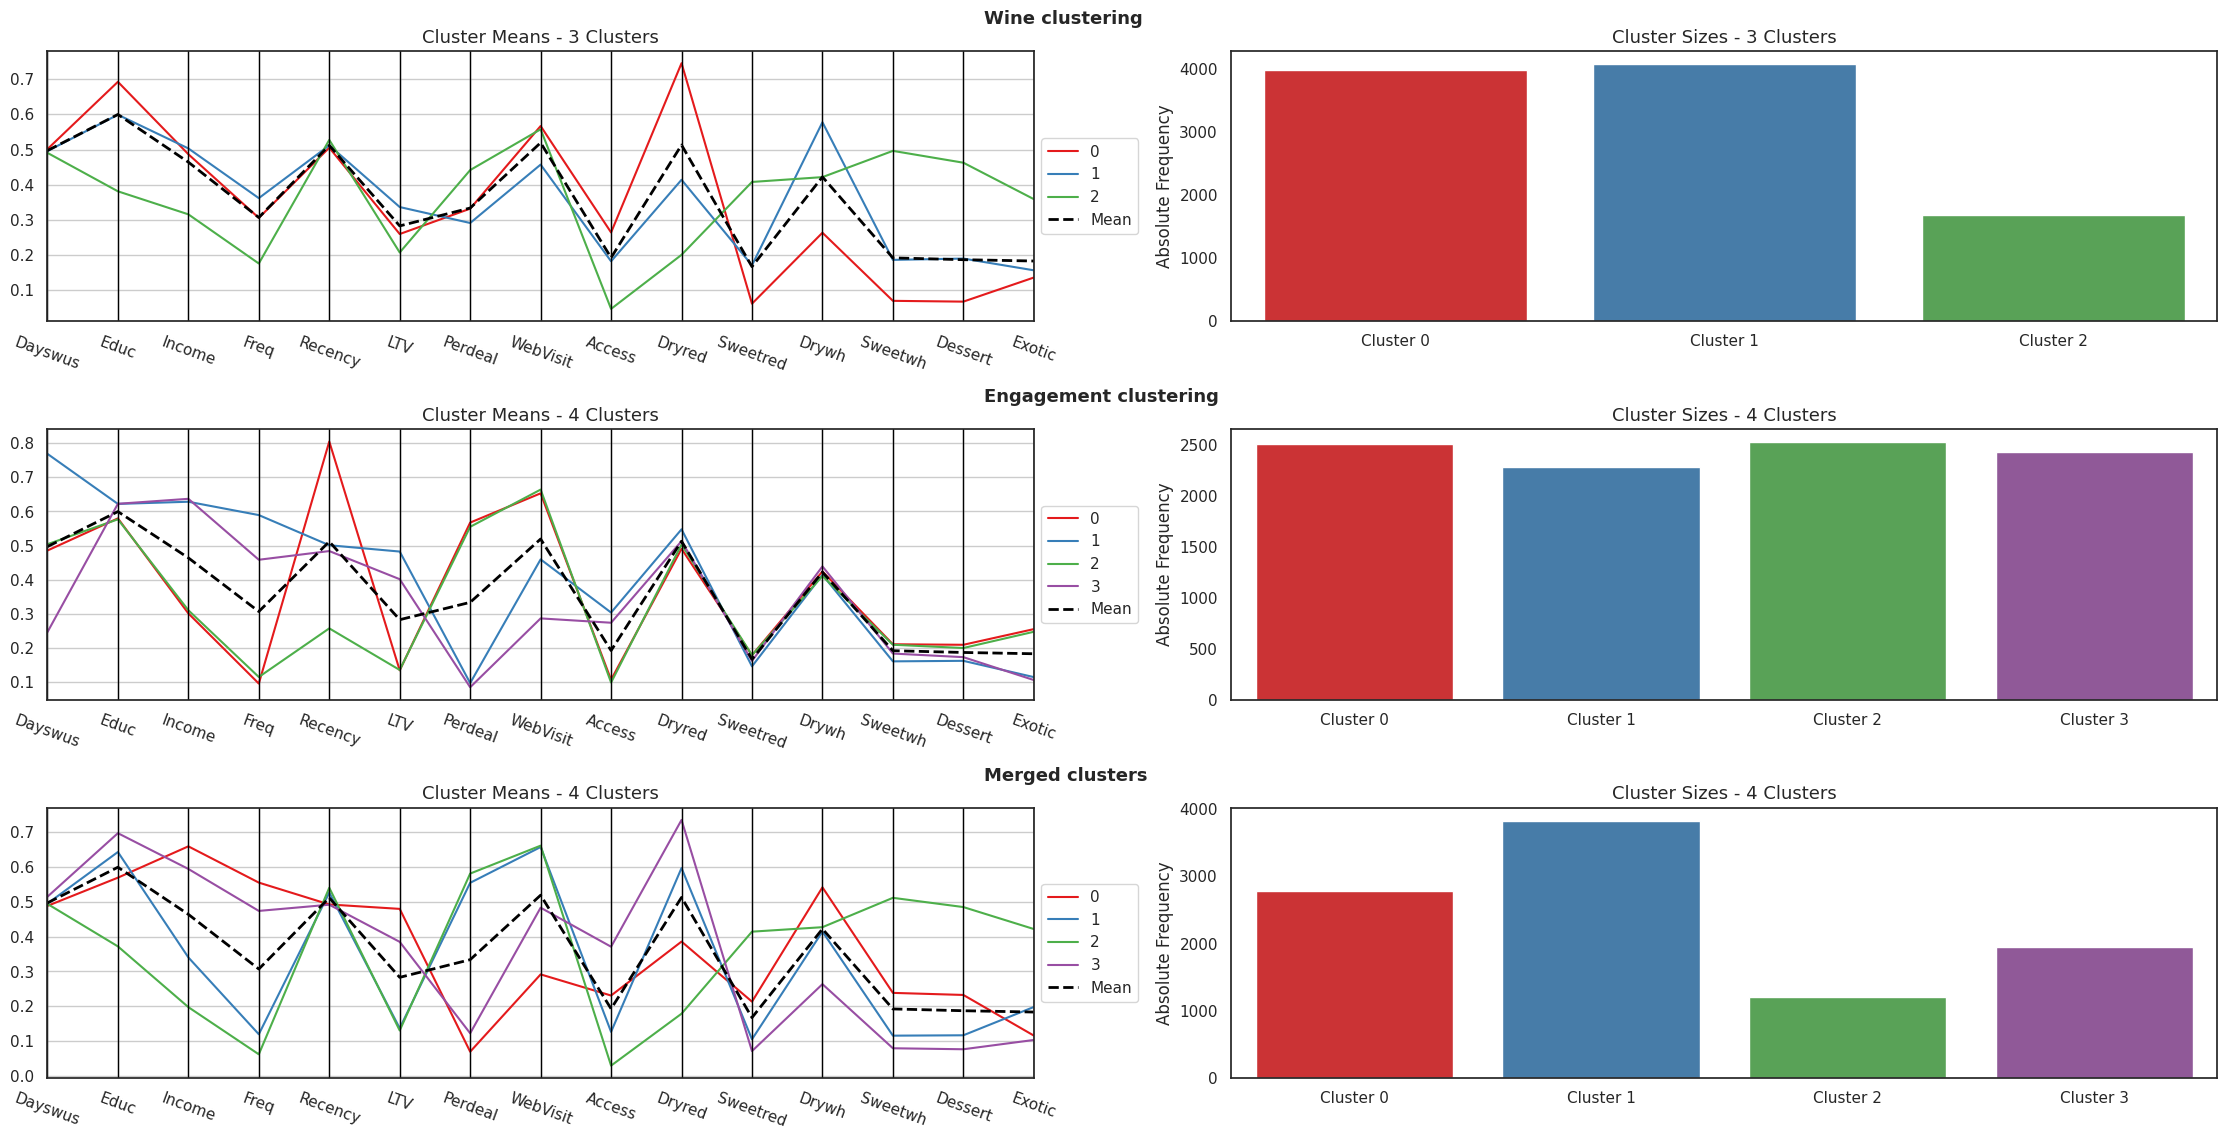

In [ ]:
# Profilling each cluster (product, behavior, merged)
sns.set(style="white")
cluster_profiles(
    df = df[metric_features + labels_list],
    label_columns = labels_list,
    figsize = (28, 13),
    compar_titles = ["Wine clustering", "Engagement clustering", "Merged clusters"],
    colors='Set1'
)

These line charts are interesting, since we can notice - as expected - that clustering was effective on the features that were considered for the specific clustering purpose. In the Engagement clustering, for instance, we notice that the Wine variables (Dryred, Sweetred, Drywh, etc.) are completely irrelevant to the clustering, which makes sense, since they were not considered. On the other hand, the merged clustering gives some interesting insight in both engagement and wine topics.

##Heatmap visualization

In [ ]:
def cluster_heatmaps(df,
                     label_columns,
                     figsize=(20,20),
                     compar_titles=None,
                     heat_colors='RdYlBu',
                     bar_colors='Set2'):
    """
    Pass df with labels columns of one or multiple clustering labels.
    Then specify this label columns to perform the cluster profile according to them.
    """
    if compar_titles == None:
        compar_titles = [""]*len(label_columns)

    fig, axes = plt.subplots(nrows=len(label_columns), ncols=2,
                             figsize=figsize, squeeze=False)
    for ax, label, titl in zip(axes, label_columns, compar_titles):

        # Filtering df
        drop_cols = [i for i in label_columns if i!=label]
        dfax = df.drop(drop_cols, axis=1)

        # Getting the cluster centroids and counts
        centroids = dfax.groupby(by=label, as_index=False).mean()
        counts = dfax.groupby(by=label, as_index=False).count().iloc[:,[0,1]]
        counts.columns = [label, "counts"]


        # Setting Data
        handles, _ = ax[0].get_legend_handles_labels()
        cluster_labels = ["Cluster {}".format(i) for i in range(counts.shape[0])]

        sns.heatmap(centroids.drop(columns=label),
              square=False, cmap=heat_colors,
              ax=ax[0],
              )

        ax[0].set_title("Cluster Means Heatmap - {} Clusters".format(counts.shape[0]), fontsize=18)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-20)
        ax[0].set_yticklabels(cluster_labels, rotation=0)
        ax[1].annotate(text=titl, xy=(-0.3,1.15),
                       xycoords='axes fraction',
                       fontsize=18, fontweight = 'heavy')


        sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
        ax[1].set_yticklabels(cluster_labels)
        ax[1].set_title("Cluster Sizes - {} Clusters".format(counts.shape[0]), fontsize=18)
        ax[1].set_ylabel("")

    plt.subplots_adjust(hspace=0.4, top=0.90)
    plt.suptitle("Merged cluster Profiling", fontsize=23)
    plt.show()

<ipython-input-387-12a30c0a2a0b>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
<ipython-input-387-12a30c0a2a0b>:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(cluster_labels)


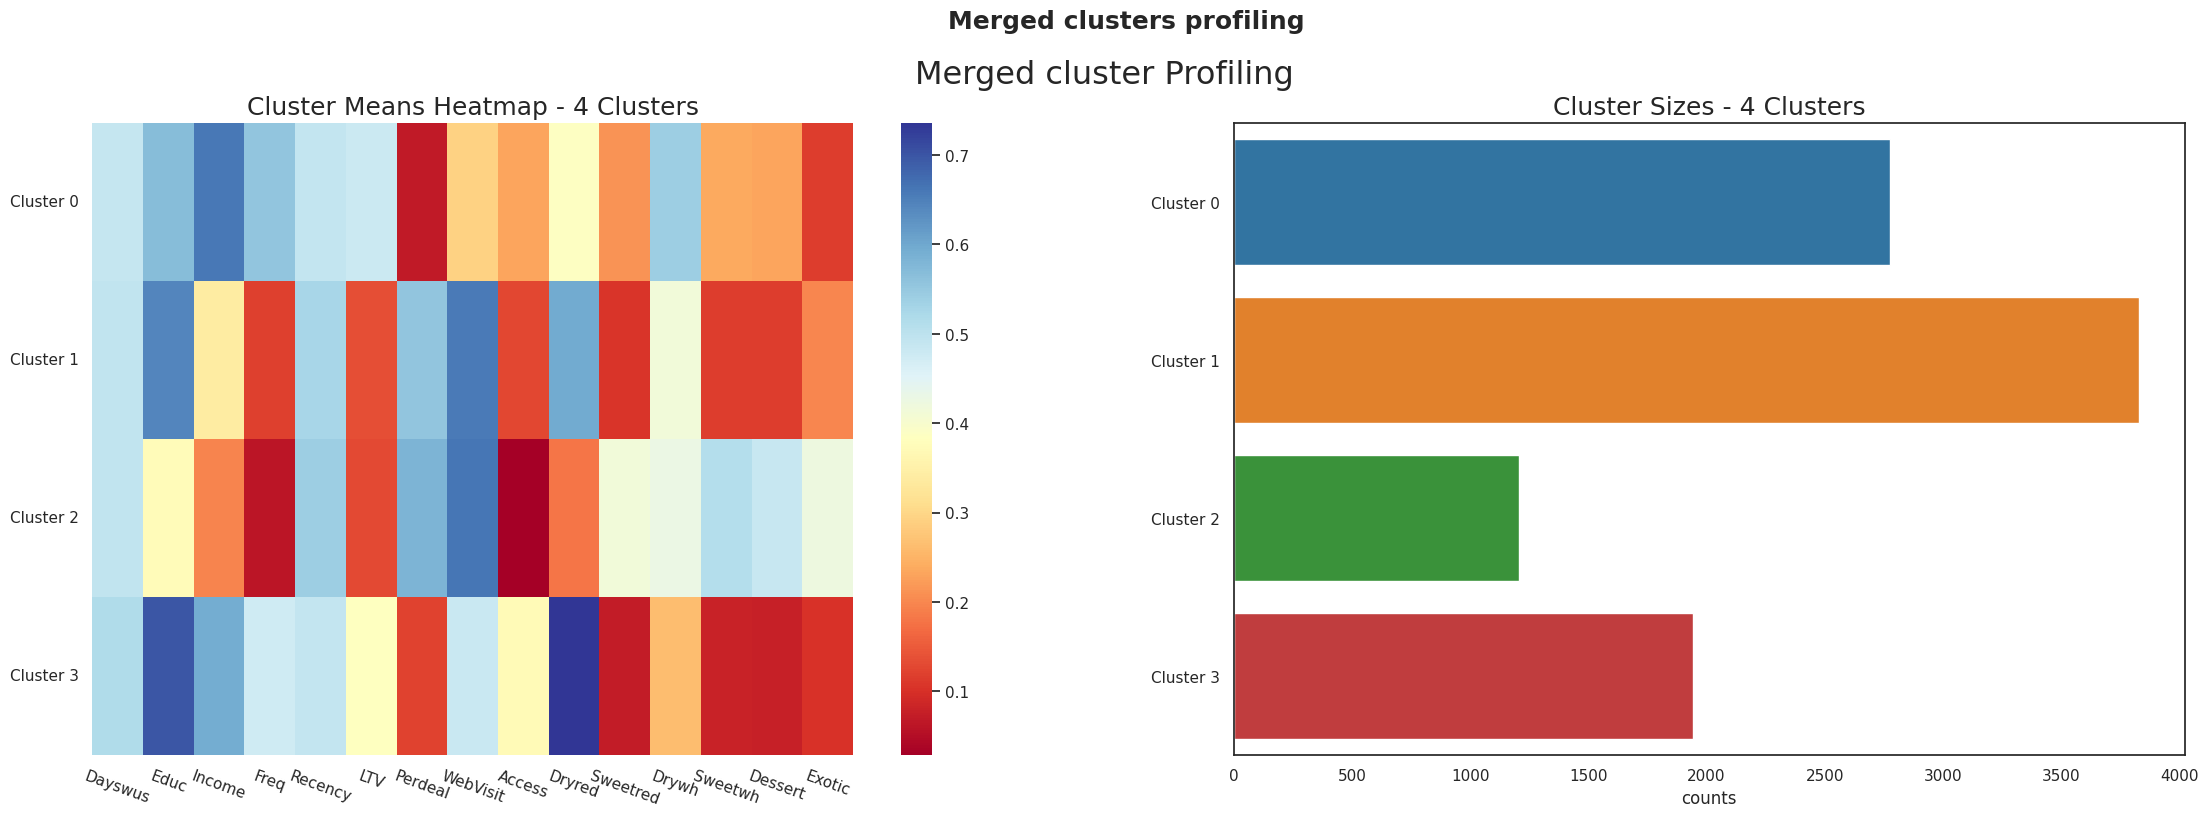

In [ ]:
# Profiling each cluster (only merged)
merged_label_list = [merged_label_name]
sns.set(style="white")
cluster_heatmaps(
    df = df[metric_features + merged_label_list],
    label_columns = merged_label_list,
    figsize = (27, 8),
    compar_titles = ["Merged clusters profiling"],
    bar_colors='tab10'
)

sns.set()

The heatmap confirms another interesting insight, that was somehow visible from the previous line chart as well. It seems as, of the 4 clusters in the Engagement section, two of them (0 and 3) follow a certain pattern and the other two (1 and 2) follow another pattern. At first glance, this could suggest that only two clusters are enough, but looking at the Wine features we actually notice that those couples of clusters behave very differently in that section.

The same could be said with cluster 1 and 3 based on the very similar results on the Wine features, we notice that they are actually different in the Engagement features, e.g. Income and Freq.

This reinforces the idea that 4 clusters are a good decision.

<ipython-input-387-12a30c0a2a0b>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
<ipython-input-387-12a30c0a2a0b>:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(cluster_labels)
<ipython-input-387-12a30c0a2a0b>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
<ipython-input-387-12a30c0a2a0b>:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].se

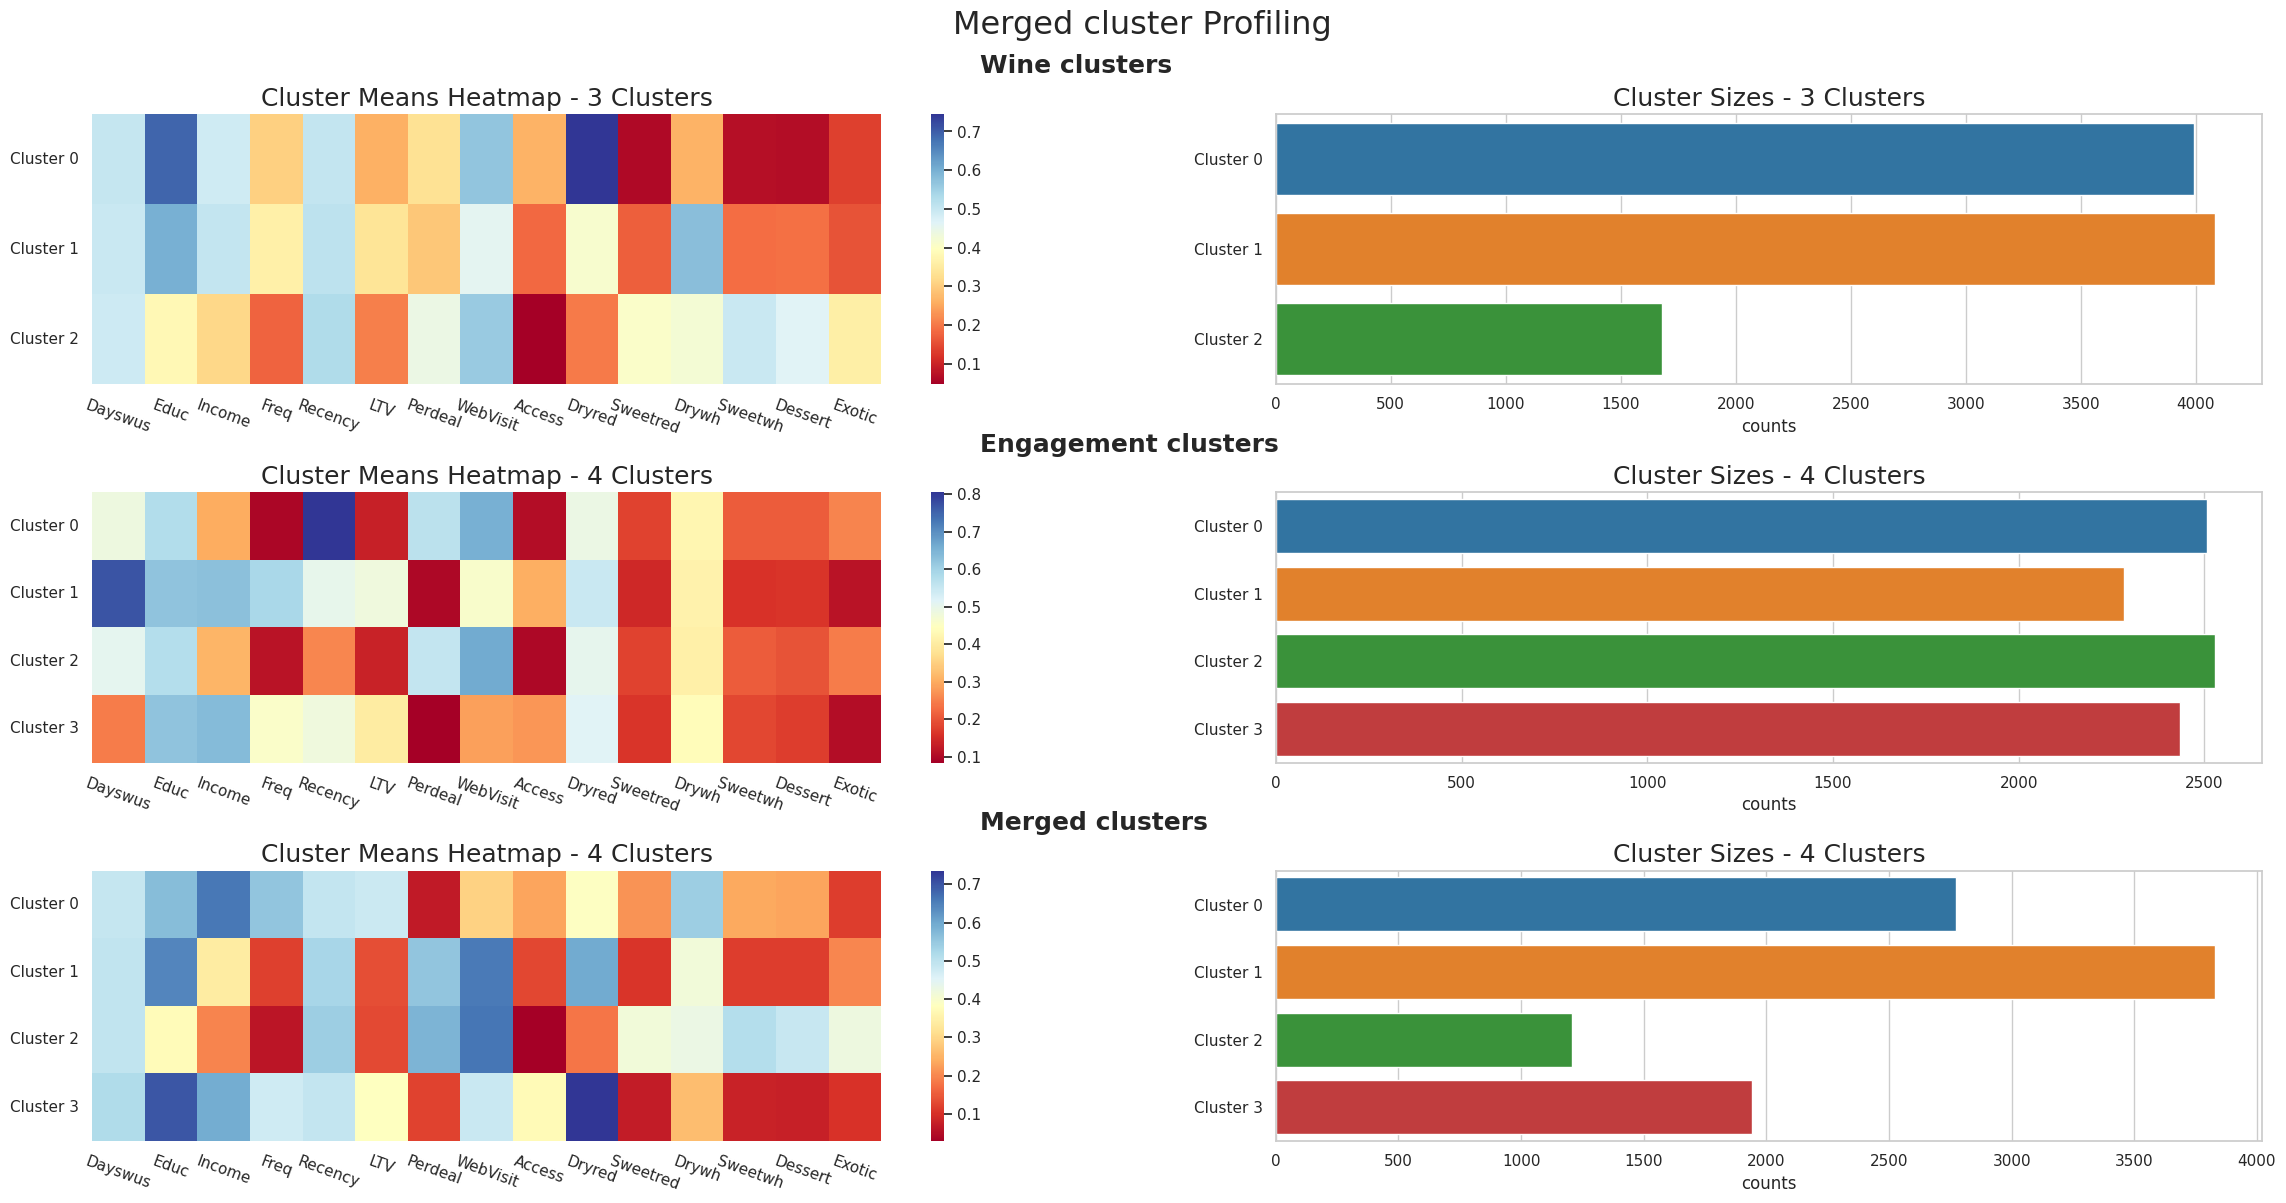

In [ ]:
# Profiling each cluster (product, behavior, merged)
sns.set(style="whitegrid")
cluster_heatmaps(
    df = df[metric_features + labels_list],
    label_columns = labels_list,
    figsize = (28, 13),
    compar_titles = ["Wine clusters", "Engagement clusters", "Merged clusters"],
    bar_colors='tab10'
)

##Recover original scaling

In [ ]:
## Put this into a DF

df_unscaled_1 = df_original_clustered.copy()
df_unscaled_1 = df_unscaled_1.dropna(subset=['km_labels_elb_final'])

#df_unscaled_1[scaled_feature_names] = pd.DataFrame(scaler.inverse_transform(df_unscaled_1[scaled_feature_names]),
                           #index=df_original_clustered.index)


df_unscaled_2 = df_original_clustered_2.copy()
df_unscaled_2 = df_unscaled_2.dropna(subset=['km_labels_3wh'])

#df_unscaled_2[scaled_feature_names] = pd.DataFrame(scaler.inverse_transform(df_unscaled_2[scaled_feature_names]),
                           #index=df_original_clustered_2.index)



## Get the dataframe with all values
km_cluster_results_wh = df[['hc_merged_labels']]
df_original_clustered_total = pd.merge(left=df_original, right=km_cluster_results_wh, how='left', left_index=True, right_index=True)
df_original_clustered_total = df_original_clustered_total.dropna(subset=['hc_merged_labels'])
df_original_clustered_total = df_original_clustered_total.drop(['Custid'], axis=1) # 'Monetary','Kidhome', 'Teenhome', 'WebPurchase'], axis=1)



In [ ]:
def get_mean_bylabel(df, label_name):
  return df.groupby(label_name).mean()

table_1 = round(get_mean_bylabel(df_original_clustered_total, 'hc_merged_labels'),1)

table_1.style.format(precision=2).background_gradient(axis=0)

,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
hc_merged_labels,,,,,,,,,,,,,,,,,,,,
0.000000,892.00,64.90,16.60,96186.80,0.10,0.30,26.00,50.30,1233.50,485.40,6.60,38.80,8.50,36.10,8.40,8.10,9.80,22.80,2.90,0.30
1.000000,896.50,38.70,17.10,54452.20,0.70,0.60,6.40,70.20,183.40,10.30,53.30,59.50,4.20,28.10,4.00,4.10,16.80,54.50,6.60,0.10
2.000000,896.00,25.30,15.00,35770.00,0.70,0.20,3.80,81.40,74.80,1.20,55.80,18.50,16.70,28.90,18.40,17.50,35.90,56.40,6.60,0.00
3.000000,910.40,58.30,17.60,87694.10,0.10,0.60,22.40,50.20,1005.80,353.90,11.70,73.10,2.80,18.60,2.80,2.70,8.70,36.40,4.80,0.50


Now the values in the cells above are real means of the table's absolute values. The "Income" values are now real values in the used currency, as well as the Wine section values are real means in % of the consumption basket for that cluster.

The view below is only based on the Segmentation 1 by Engagement values. Not our final clustering, which was already shown above.

In [ ]:
cluster_means_1 = get_mean_bylabel(df_unscaled_1,'km_labels_elb_final')
cluster_means_1.round(2)

,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
km_labels_elb_final,,,,,,,,,,,,,,,,,,,,,
0.0,6055.33,889.94,35.20,16.64,49369.62,0.73,0.54,5.31,119.86,144.57,7.27,54.48,49.08,7.17,28.74,7.50,7.48,21.70,54.92,6.53,0.11
1.0,6012.20,1088.25,61.55,16.98,92110.40,0.09,0.45,27.59,51.11,1320.17,490.28,9.33,54.69,5.85,28.11,5.64,5.70,9.75,30.15,4.60,0.40
2.0,5923.40,902.82,35.83,16.62,50576.18,0.72,0.54,6.18,26.27,170.04,8.89,53.29,50.31,7.22,27.90,7.45,7.09,21.05,55.00,6.64,0.10
3.0,6011.74,722.58,62.84,16.98,93232.45,0.07,0.38,21.64,49.39,970.49,375.79,8.16,51.29,6.49,29.67,6.45,6.07,9.02,26.80,2.87,0.36


The view below is only based on the Segmentation 2 by Wine values.

In [ ]:
cluster_means_2 = get_mean_bylabel(df_unscaled_2,'km_labels_3wh')
cluster_means_2.round(2)

,Custid,Dayswus,Age,Educ,Income,Kidhome,Teenhome,Freq,Recency,Monetary,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebPurchase,WebVisit,Access
km_labels_3wh,,,,,,,,,,,,,,,,,,,,,
0.0,5996.44,900.83,50.46,17.54,73575.07,0.37,0.73,14.77,57.64,609.42,180.71,31.87,74.05,2.47,18.60,2.45,2.37,11.57,44.91,5.67,0.34
1.0,6003.89,897.01,51.85,16.79,75725.16,0.41,0.34,17.30,61.66,777.33,287.10,27.96,41.58,6.84,38.40,6.52,6.65,13.32,37.14,4.57,0.22
2.0,5999.90,893.41,35.29,15.05,51255.93,0.55,0.22,8.92,72.71,334.99,107.93,42.39,20.67,16.43,28.56,17.76,16.58,30.54,47.63,5.58,0.05


In addition, we can look at the mode of our binary variables to see how they differ across our 4 merged clusters.

The mode is the only measure of central tendency that is available for binary/dichotomous variables, which are qualitative and not ordinal.

In [ ]:
df.groupby([merged_label_name])[binary_vars].agg(pd.Series.mode)

,Kidhome,Teenhome,Minor_home,Access
hc_merged_labels,,,,
0,0,0,0,0.0
1,1,1,1,0.0
2,1,0,1,0.0
3,0,1,1,0.0


In [ ]:
def categorical_profiling(df,
                          feats,
                          label,
                          figsize=(12, 10),
                          title=None,
                          bar_colors='Set2'):

    labels_list = np.sort(df[label].unique()).tolist()

    # Determine the maximum count for all features across all clusters
    max_count = 0
    for li in labels_list:
        row_df = df[df[label] == li]
        for cat in feats:
            max_count = max(max_count, row_df[cat].value_counts().max())

    # Create subplots
    fig, axes = plt.subplots(len(feats), len(labels_list),
                             figsize=figsize,
                             sharex='row',
                             sharey='row',
                             tight_layout=True)

    for li in labels_list:
        row_df = df[df[label] == li]

        for ci, cat in enumerate(feats):
            ax = axes[ci][li]

            sns.countplot(ax=ax, y=row_df[cat], hue=row_df[cat], palette=bar_colors, legend=False)

            # Set consistent scale
            ax.set_xlim(0, max_count)

            ax.set_xlabel("")

            if ci == 0:
                ax.set_title("Cluster {}".format(li))
            else:
                ax.set_title("")

            if li == 0:
                ax.set_ylabel(cat)
            else:
                ax.set_ylabel("")

    fig.suptitle(title, y=1.01)
    plt.show()

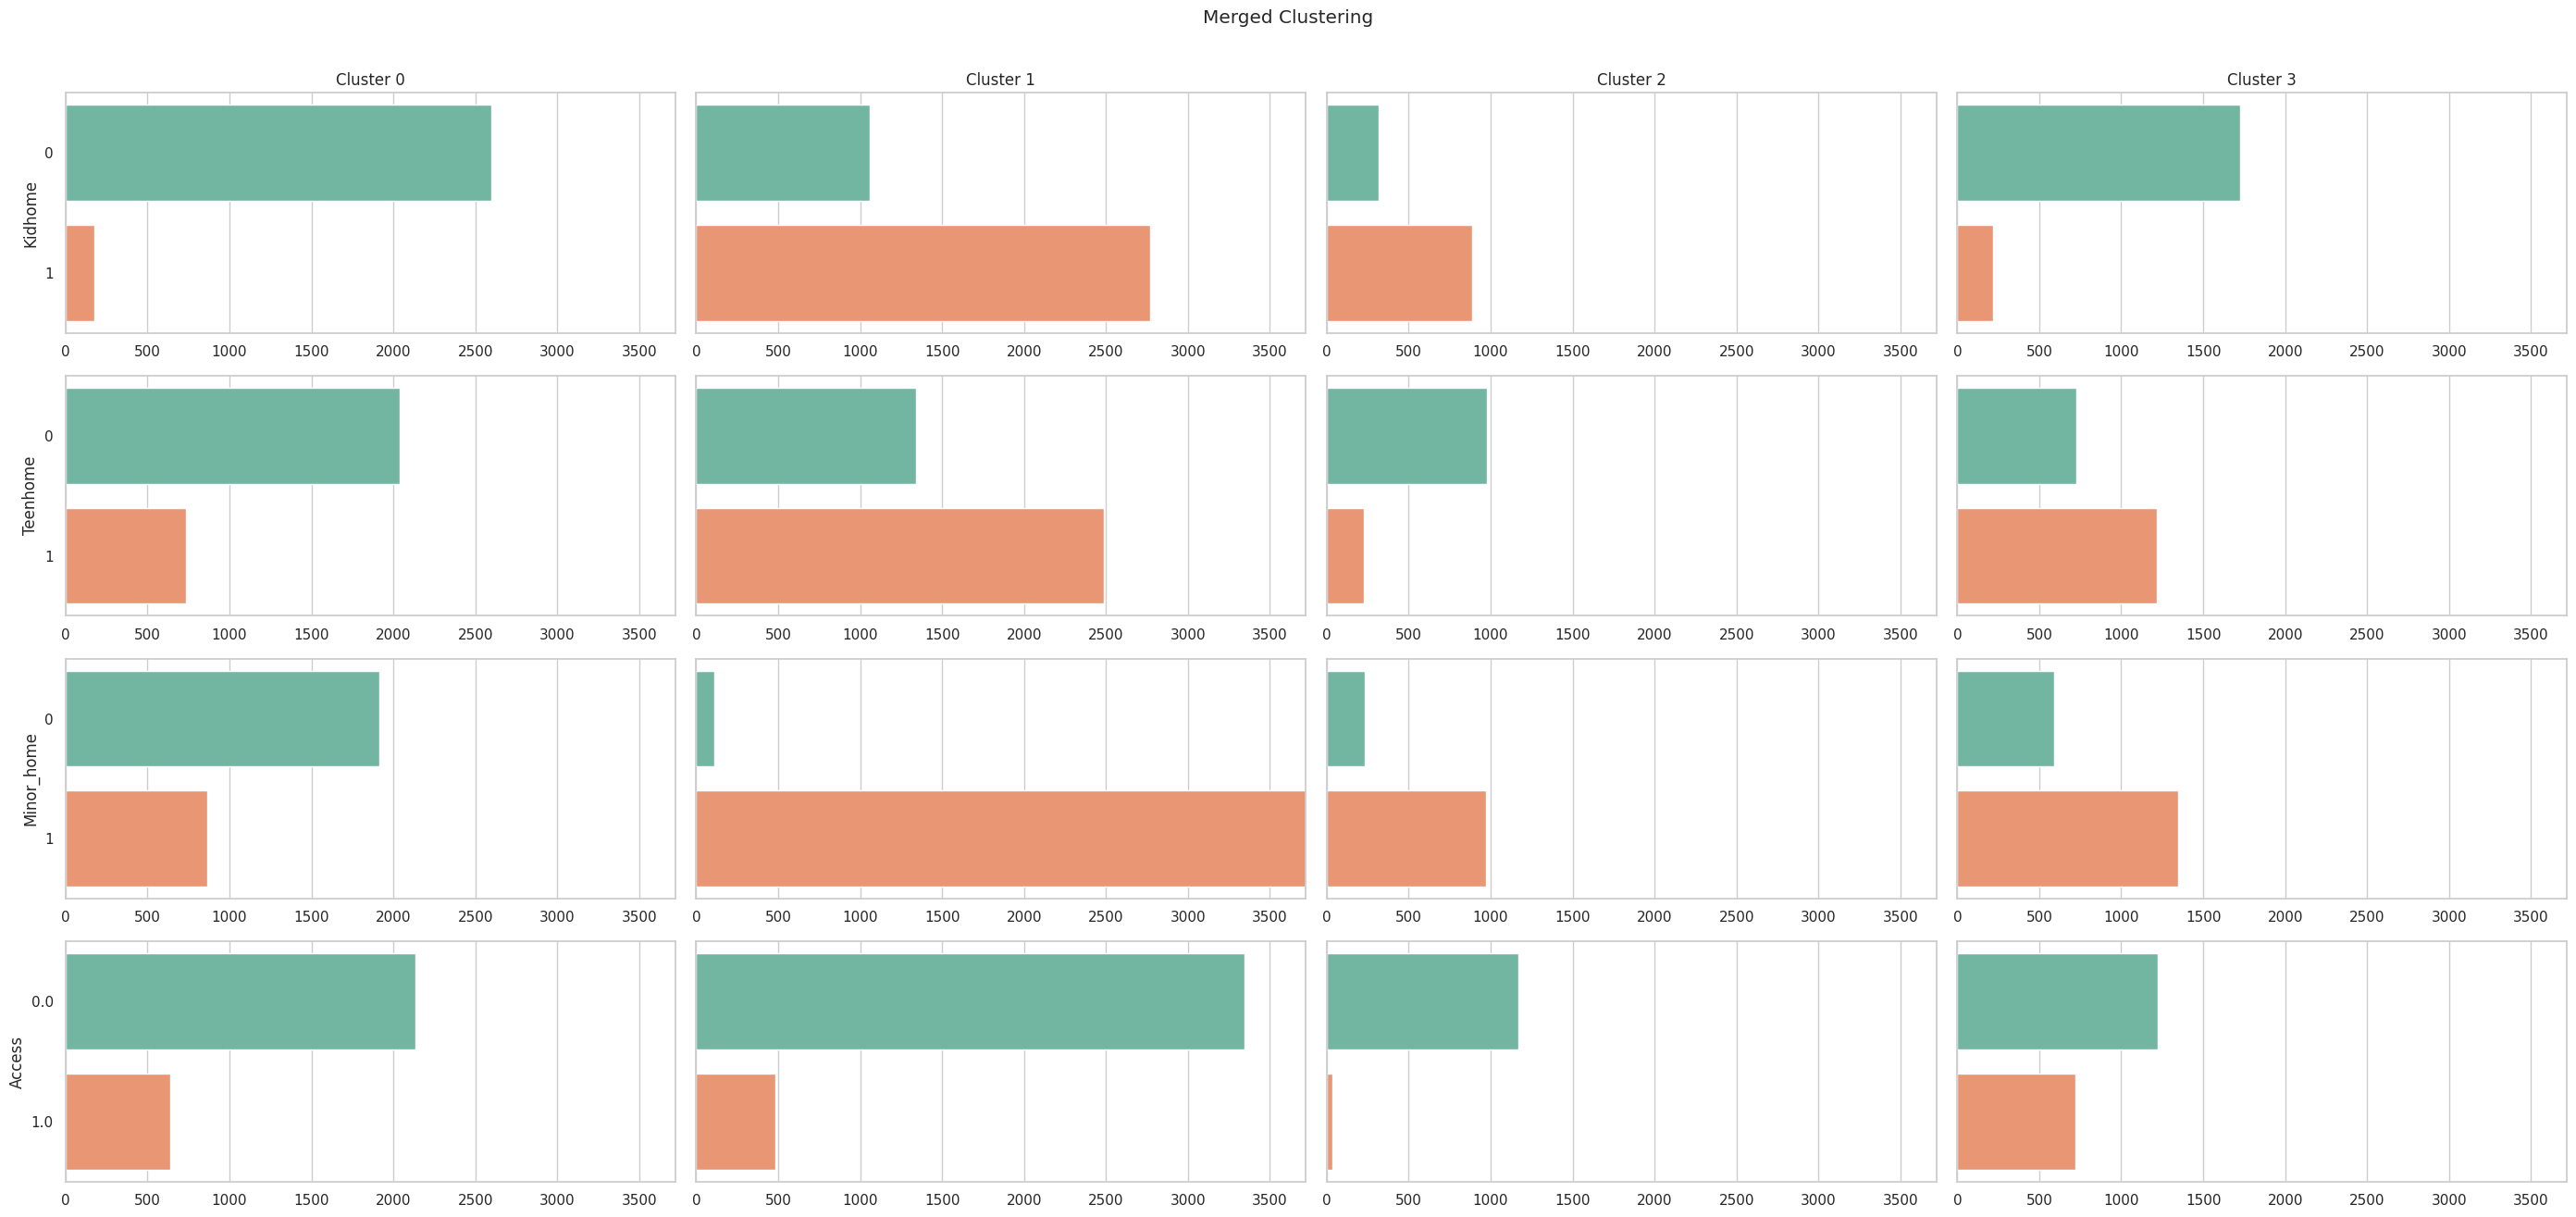

In [ ]:
# Profiling each cluster (merged)
sns.set(style="whitegrid")
categorical_profiling(
    df = df[binary_vars + labels_list],
    feats = binary_vars,
    label = merged_label_name,
    figsize = (28, 13),
    title = "Merged Clustering"
)

In the diagram above, we can visualize how the 4 clusters differ for our binary variables in absolute values. We will comment on this in the conclusions.

##Reclassifying noise

The following code creates a decision tree classifier, starting from the most important features, that will be able to classify new records based on the actual clustering. Not all of the new records will be classified correctly, but we will assess how good the classification will be with this model.

To test the model, we can also simply use the same records used to build our model and see if they would be predicted correctly. We basically apply regression on the same records that were used for our descriptive analysis.

In [ ]:
# Preparing the data
X = df[metric_features]
y = df[merged_label_name]

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fitting the decision tree
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
print("It is estimated that on average, we are able to predict {0:.2f}% of the customers correctly".format(dt.score(X_test, y_test)*100))

It is estimated that on average, we are able to predict 90.16% of the customers correctly


The result is satisfactory with ca. 90% of the customers classified correctly, based on this decision tree.

Below we can see what the most relevant features in the classification tree were. We can assume that Dryred was the first feature at the top of the decision tree, followed by LTV, Drywh, etc.

In [ ]:
# Assessing feature importance
pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)

,0
Dryred,0.504712
LTV,0.383369
Drywh,0.042818
Perdeal,0.031631
Sweetwh,0.027073
Dessert,0.006079
Recency,0.004318
Dayswus,0.000000
Educ,0.000000
Income,0.000000


In [ ]:
## Remember our noise rows that we removed with DBSCAN?
## Predicting the cluster labels of the outliers

df_noise[merged_label_name] = dt.predict(df_noise[metric_features])
df_noise[metric_features + [merged_label_name]].head()

,Dayswus,Educ,Income,Freq,Recency,LTV,Perdeal,WebVisit,Access,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,hc_merged_labels
2,0.047143,0.750,0.140429,0.066667,0.676471,0.126996,0.687500,0.7,1.0,0.316327,0.475,0.349206,0.028571,0.685714,0.741176,1
20,0.325714,0.250,0.610551,0.244444,0.431373,0.235123,0.041667,0.1,0.0,0.112245,0.100,0.190476,0.971429,1.000000,0.023529,0
21,0.797143,0.125,0.255627,0.088889,0.039216,0.143687,0.166667,0.7,0.0,0.040816,0.725,0.222222,0.342857,1.000000,0.941176,2
42,0.151429,0.000,0.021496,0.044444,0.911765,0.126270,0.833333,0.6,0.0,0.051020,0.650,0.206349,0.542857,0.942857,0.176471,2
44,0.940000,0.125,0.177420,0.022222,0.509804,0.126996,0.677083,0.6,1.0,0.030612,0.300,0.396825,1.000000,0.000000,1.000000,2


In [ ]:
# Decision tree
num_of_clusters = len(df[merged_label_name].unique())
cluster_names = ["Cluster {}".format(i) for i in range(num_of_clusters)]
dot_data = export_graphviz(dt, out_file=None,
                           feature_names=X.columns.to_list(),
                           filled=True,
                           rounded=True,
                           class_names=cluster_names,
                           special_characters=True)


In [ ]:
### optionally save dt png
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png('cluster_decision_tree.png')

## Open sidebar to download the image
df.head(3)

,Dayswus,Educ,Income,Kidhome,Teenhome,Freq,Recency,LTV,Perdeal,Dryred,Sweetred,Drywh,Sweetwh,Dessert,Exotic,WebVisit,Access,Minor_home,km_cluster_results,km_cluster_results_wh,hc_merged_labels
0,0.341429,0.500,0.618413,0,0,0.622222,0.647059,0.636430,0.031250,0.367347,0.125,0.666667,0.285714,0.085714,0.023529,0.4,1.0,0,3,1,0
1,0.104286,1.000,0.788675,0,0,0.666667,0.058824,0.539187,0.010417,0.551020,0.025,0.571429,0.114286,0.057143,0.023529,0.1,0.0,0,3,1,0
3,0.490000,0.875,0.639763,0,1,0.444444,0.098039,0.279390,0.125000,0.602041,0.250,0.269841,0.171429,0.142857,0.176471,0.5,0.0,1,3,0,3


In [ ]:
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")

Execution time: 123.57644414901733 seconds


Looking at the generated decision tree, LTV is used as a step in the decision tree before Dryred, which is a bit surprising given the table generated above. However, we see that the three main predictors are the same.

##Cluster profiling and understanding

**Cluster 0 - "White hair, white grapes"**

**(Affluent seniors, white wine oriented)**


*Status*:
The group has the highest income (€ 96K), age and LTV. Low sensitivity (6,63) to discounts supports the wealthy status, the age explains the low digital competences, given the lowest web visits. Age is also coherent with the very low amount of observations with minors at home - these are probably retired people and/or grandparents.
They tend to buy often (Freq = 26) and are not particularly interested in accessories (0,23).


*Wines*:
While having a good balance between dry red (38,81%) and dry white wines (36,14%), they show a clear higher consumption of white wine relatively to the other segments...


*Size*:
The cluster is the second biggest after Cluster 1 (2775 observations).



**Cluster 1 - "Family Dry"**

**(Family-oriented emerging, dry wine lovers)**


*Status*:
A group with mid-low income (€ 54 K) but high education (17,15 years), which would suggest younger people with bright perspectives. The cluster is family-oriented, with a clear majority of teens and/or kids at home. Variables show affinity to digital competences with high web visits (6,58) and sensitivity to discounts (53,27). They do not buy frequently (6,37) and are not interested in accessories (0,13).


*Wines*:
The group has a more balanced basket between red (59,54%) and white (28,12%), compared to the other groups, with a preference for dry wines (close to 90% of the total).


*Size*:
They are the most represented cluster in our sample (3830 observations).





**Cluster 2 - "Poor sweethearts!"**

**(Low income and education, sweet wine affinity)**


*Status*:
The cluster has the lowest education level (14,98 years) and lowest income (ca. € 36 K), with a tendency to buy on the web (6,62) and on discounted products (55,83). The group is very young, as shown by the high presence of kids at home, but not teenagers. They do not buy frequently (3,77) and are the least interested in accessories (0,03).

*Wines*:
The group shows a higher interest for sweet and dessert wines (51% of the total), but the combination of this with low LTV might suggest that sweet wines are more represented in the average basket because they buy little wine in general, so the few purchases of sweet wines have a higher impact on the basket.

*Size*:
They are the least represented cluster in our sample (1207 observations).




**Cluster 3 - "Grades of red"**

**(Wealthy educated families, dry red wine lovers)**

*Status*:
The group has the highest education (17,58 years), and still a high age and LTV. They still use the web to make purchases (4,83) but are not particularly sensitive to discounts (11,72). They have teens at home rather than kids, which suggests the parents are at least in their 30s, probably already in their 40s, starting to have increasing purchasing power due to their education and income, and children about to leave the household.
They tend to buy often (Freq = 22,33) and are the segment that shows the most interest in accessories (0,37).

*Wines*:
They have a clear preference for dry red wines (73,11%).

*Size*:
The cluster is the second lowest after Cluster 2 (1943 observations).


##Business insights and conclusions

In this section we propose a concise list of insights and business advices.

In the first part we will describe how the marketing should be done on the different clusters, and how their evolution should be followed.

The second section will tackle how the different products and channels should be developed and where the efforts should be placed.

###Recommendations for cluster marketing

* Cluster 0 - White hair, white grapes (Affluent seniors, white wine oriented)

This cluster is profitable with a high LTV, however given the average age this is the cluster that includes customers with the shortest remaining life expectancy. It would be interesting to analyse into detail whether the wine basket preferences are related to age or rather to specific generations. In the first case, dry wines might still be the most interesting ones in the future for older customers. On the other hand, should the wine preferences depend more on generational trends, this cluster might gradually shift more towards dry red wine.

* Cluster 1 - Family Dry (Family-oriented emerging, dry wine lovers)

The most represented cluster must be followed with particular attention. The individuals in this cluster, which includes well-educated people with good future income perspective, have the potential to shift closer to Cluster 3, therefore with very profitable future perspectives. The relatively balanced basket between red and white dry wines suggests that a balanced approach should be kept in the future product strategies for wines. Should a specific group be targeted with promotions and aggressive campaigns, it should be this one, since it has a high volume of individuals, it is sensitive to pricing and has a longer purchasing perspective.

* Cluster 2 - Poor sweethearts! (Low income and education, sweet wine affinity)

Our least represented and least profitable cluster still can provide some interesting insights and challenges. Without doubt this is the least important cluster, however one important question should be raised. Is the low income and LTV level in this cluster only temporary or not? If further analysis would indicate that this is the case (e.g this cluster is still in education phase) we would have a potential for improvement in the future and could see many of the individuals currently represented in this cluster shift towards the Cluster 1 and potentially later even to Cluster 3. On the other hand, if the income and LTV levels are not expected to increase significantly, there will be no improvements in profitability to be expected and this cluster will remain a low-value segment for the business. At the moment, the interest shown by this segment to sweet wines is not enough to justify any important investment in these product segments. Any change in strategy should be targeted at keeping the price low for sweet wines.

* Cluster 3 - Grades of red (Wealthy educated families, dry red wine lovers)

This is a relatively low volume but highly profitable segment, which could guarantee business continuity by the presence of teenagers in the household as potential future customers. The high levels of income, LTV and education suggest that this cluster would value new high-quality dry red wines, which could be a product segment to invest in.  



###Recommendations for product management

*Wines*:  

Emphasis should be given to dry wines, supported by Cluster 0 and Cluster 3. One important trend to follow, will be the evolution of preferences between dry red and dry white wines. Whether these are generational trends or more related to demographical factors such as income and age, this will affet the relative proportions in the future and influence our business strategy.

Dry white wines might drop in the future due to the high age of Cluster 0, but we cannot exclude that age will be a factor that contributes to shift the preferences from other clusters - Cluster 3 above all.

Sweet wines - red and white - as well as dessert wines are only preferred by our least favourite cluster, Cluster 2. This suggests that little investment should be done on them.

Exotic wines are not particularly favoured by the customers, however the interest shown by Cluster 1 is not negligible. We should follow the evolution of Cluster 1 and see how this relates to the purchase of exotic wines.

*Accessories*:

Cluster 0 and Cluster 3 should be targeted with accessories. Cluster 3 seems to already have a certain degree of awareness on the accessories, whereas Cluster 0 might need some different targeting and marketing campaigns due to the different purchasing channels used and the low degree of web purchases.

*Discounts*:

Discounts should only be targeted at Cluster 1 and 2, those that are sensitive. The discounts are more important to clusters that do web purchases with consistency.

*Website*:

The website accesses will be important in the future, since they are key features for the youngest clusters, and we can assume that those habits will not change with time. We additionally suggest targeting discount mainly on the online store, rather than in the physical stores.

In [ ]:
# @title
# In the end, let's import the NOVA IMS logo to show who taught us everything in order to conduct this in-depth analysis.
from IPython.core.display import display, HTML

display(HTML('''
<div style="text-align: center;">
  <img src="https://urbandatalab.pt/images/partners/nova_ims.png" alt="Art Image" width="200" />
</div>
'''))
